<a href="https://colab.research.google.com/github/WiseSeaSnake/CZN_AD/blob/main/Case_40_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2. Классификация


2.1 Теоретическая часть


Product: (20, 9)
Region : (6, 2)
Sales  : (10000, 9)
State  : (51, 4)

fact_sales: (10000, 29)

Датасеты сохранены в analytics_datasets.xlsx

Распределение IsHelicopter:
IsHelicopter
0    9115
1     885
Name: count, dtype: int64

Итоговый размер выборки: (10000, 11)

=== LogisticRegression ===
              precision    recall  f1-score   support

           0     0.9978    0.8479    0.9168      2735
           1     0.3846    0.9811    0.5526       265

    accuracy                         0.8597      3000
   macro avg     0.6912    0.9145    0.7347      3000
weighted avg     0.9437    0.8597    0.8846      3000


=== RandomForest ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      2735
           1     1.0000    1.0000    1.0000       265

    accuracy                         1.0000      3000
   macro avg     1.0000    1.0000    1.0000      3000
weighted avg     1.0000    1.0000    1.0000      3000


=== Сравнение моделей ===
  

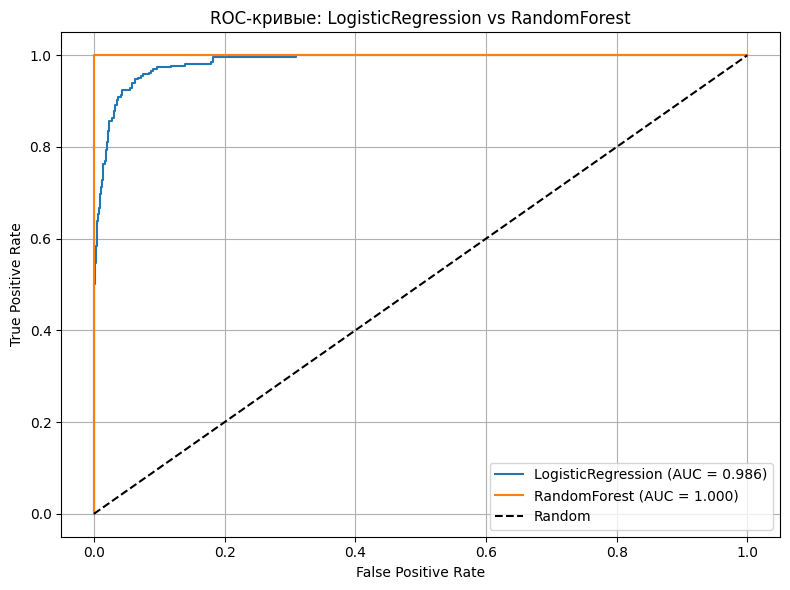


=== Зависимость метрик от n_estimators ===
   n_estimators  Accuracy   F1  ROC_AUC
0            10       1.0  1.0      1.0
1            50       1.0  1.0      1.0
2           100       1.0  1.0      1.0
3           200       1.0  1.0      1.0
4           300       1.0  1.0      1.0
5           500       1.0  1.0      1.0


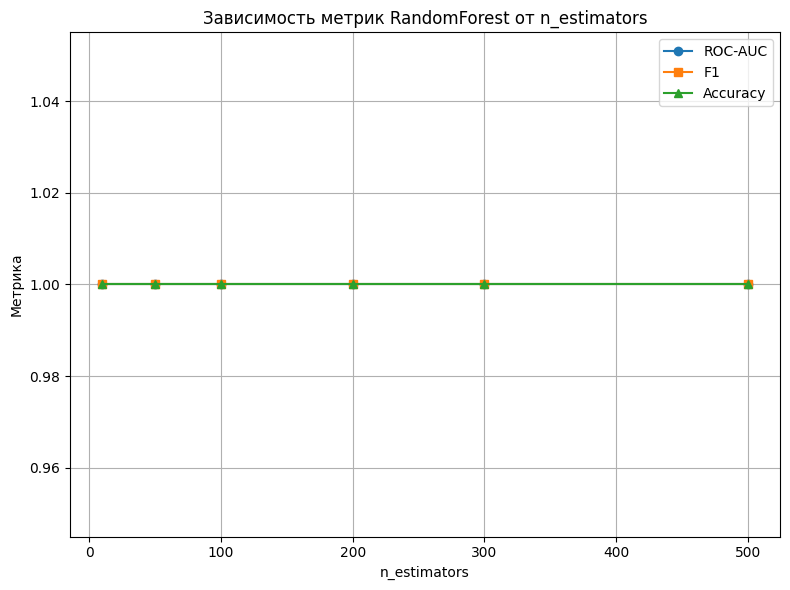


=== Кросс-валидация (ROC-AUC, 5 фолдов) ===
LogisticRegression: 0.9904 ± 0.0023
RandomForest      : 1.0000 ± 0.0000

Форма SHAP-значений: (3000, 34)

=== Сравнение feature_importance и SHAP ===
                             Feature  BuiltinImportance  MeanAbsSHAP  BuiltinNorm  SHAPNorm  RankBuiltin  RankSHAP  RankDiff
0                        RetailPrice             0.3672       0.2060       0.3672    0.3568          1.0       1.0       0.0
1                          UnitPrice             0.3381       0.1894       0.3381    0.3281          2.0       2.0       0.0
2               Demographic_Advanced             0.0557       0.0442       0.0557    0.0766          3.0       3.0       0.0
3                        KitType_RTF             0.0354       0.0209       0.0354    0.0362          5.0       4.0       1.0
4                           Channels             0.0400       0.0187       0.0400    0.0324          4.0       5.0      -1.0
5                 Demographic_Novice             0.0334

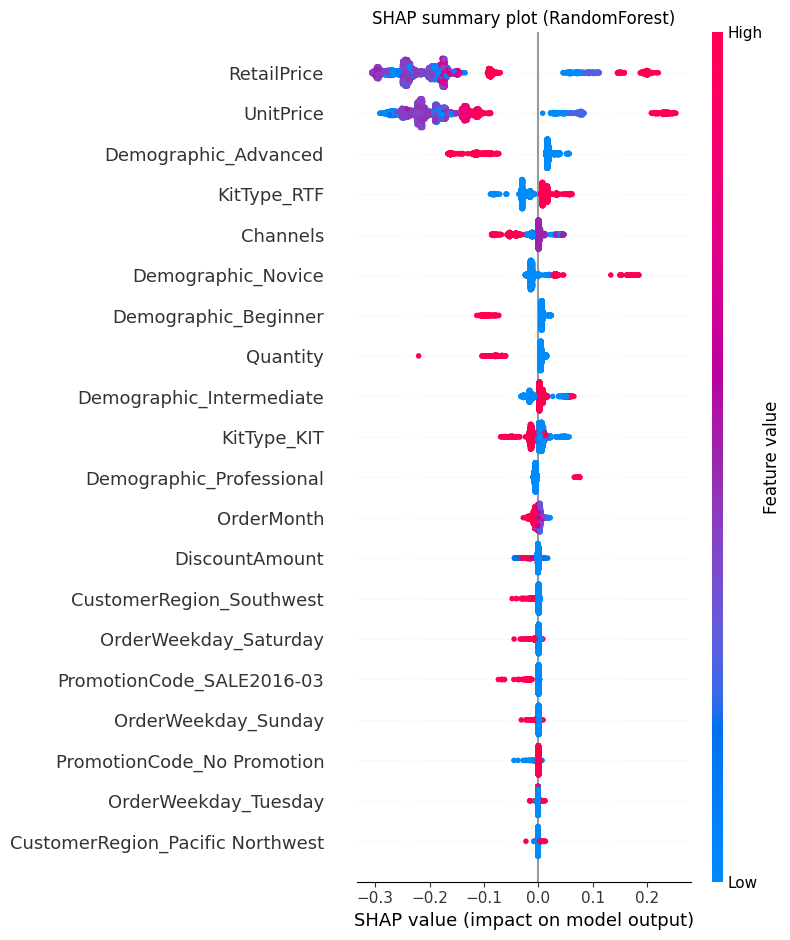

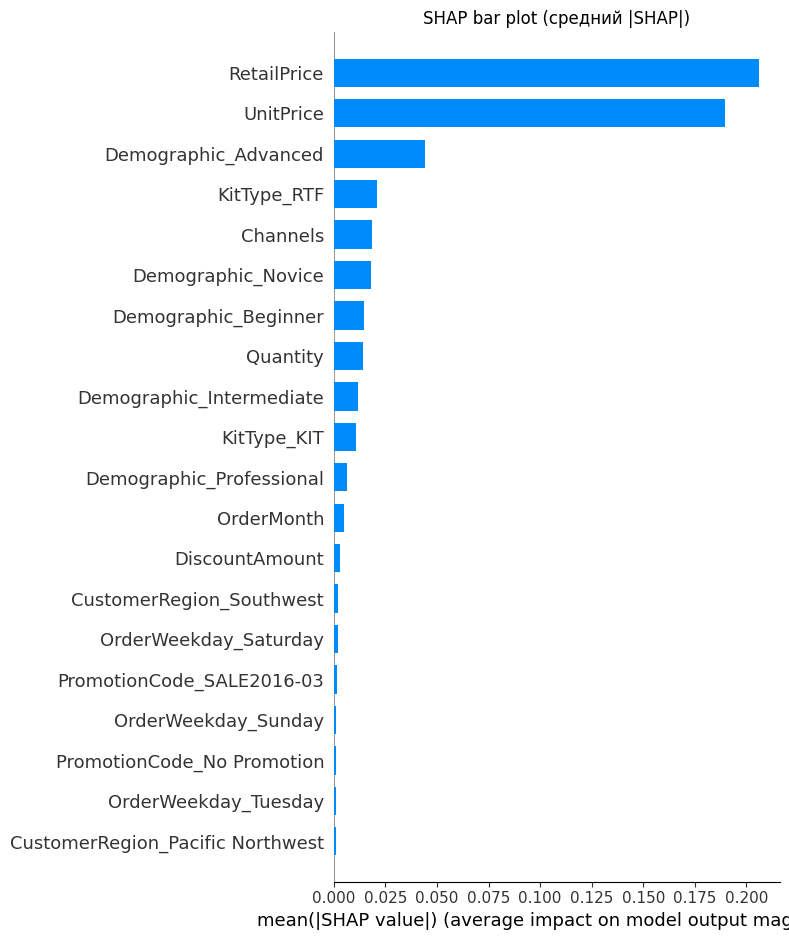

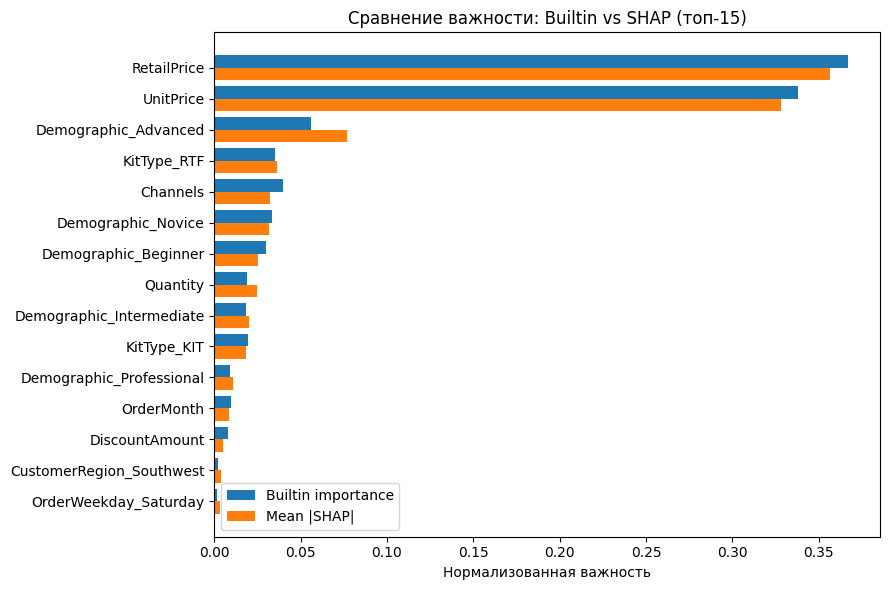


=== Топ-10 признаков по SHAP ===
 1. RetailPrice                         SHAP=0.3568  Builtin=0.3672
 2. UnitPrice                           SHAP=0.3281  Builtin=0.3381
 3. Demographic_Advanced                SHAP=0.0766  Builtin=0.0557
 4. KitType_RTF                         SHAP=0.0362  Builtin=0.0354
 5. Channels                            SHAP=0.0324  Builtin=0.0400
 6. Demographic_Novice                  SHAP=0.0316  Builtin=0.0334
 7. Demographic_Beginner                SHAP=0.0252  Builtin=0.0300
 8. Quantity                            SHAP=0.0246  Builtin=0.0186
 9. Demographic_Intermediate            SHAP=0.0202  Builtin=0.0181
10. KitType_KIT                         SHAP=0.0184  Builtin=0.0193

=== Признаки с наибольшим расхождением рангов ===
                             Feature  RankBuiltin  RankSHAP  RankDiff
16               OrderWeekday_Sunday         21.0      17.0       4.0
9                        KitType_KIT          8.0      10.0      -2.0
19  CustomerRegion_Pacifi

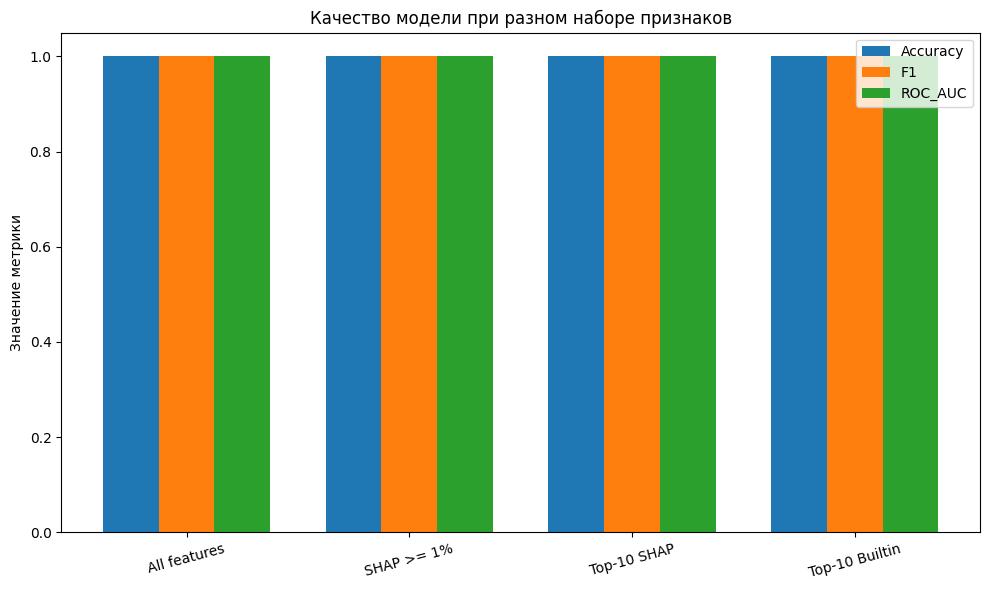


=== Кросс-валидация (ROC-AUC, 5 фолдов) ===
            Model  N_features  CV_AUC_mean  CV_AUC_std
0    All features          11          1.0         0.0
1      SHAP >= 1%           6          1.0         0.0
2     Top-10 SHAP           6          1.0         0.0
3  Top-10 Builtin           6          1.0         0.0

=== Топ-15 признаков (RandomForest, builtin) ===
                      Feature  Importance
4                 RetailPrice      0.3672
1                   UnitPrice      0.3381
8        Demographic_Advanced      0.0557
3                    Channels      0.0400
7                 KitType_RTF      0.0354
11         Demographic_Novice      0.0334
9        Demographic_Beginner      0.0300
6                 KitType_KIT      0.0193
0                    Quantity      0.0186
10   Demographic_Intermediate      0.0181
5                  OrderMonth      0.0099
12   Demographic_Professional      0.0088
2              DiscountAmount      0.0076
18   CustomerRegion_Southwest      0.0021


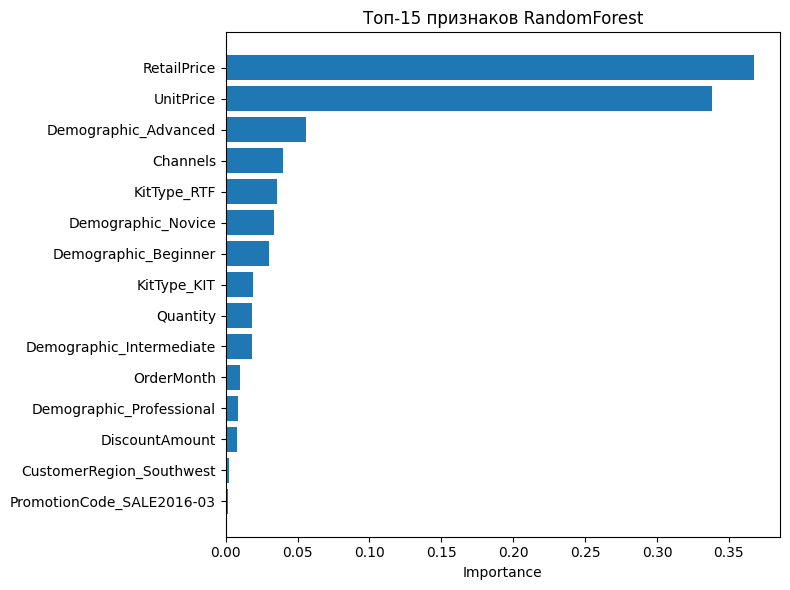

In [10]:
# ============================================================
# 0. Импорт библиотек
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


# ============================================================
# 1. Чтение исходного Excel
# ============================================================
file_path = '40_10.xlsx'

df_product = pd.read_excel(file_path, sheet_name='Product')
df_region  = pd.read_excel(file_path, sheet_name='Region')
df_sales   = pd.read_excel(file_path, sheet_name='Sales')
df_state   = pd.read_excel(file_path, sheet_name='State')

print("Product:", df_product.shape)
print("Region :", df_region.shape)
print("Sales  :", df_sales.shape)
print("State  :", df_state.shape)


# ============================================================
# 2. Очистка и типы
# ============================================================
df_sales['OrderDate'] = pd.to_datetime(df_sales['OrderDate'])
df_sales['ShipDate']  = pd.to_datetime(df_sales['ShipDate'])
df_sales['PromotionCode']  = df_sales['PromotionCode'].fillna('No Promotion')
df_sales['Quantity']       = pd.to_numeric(df_sales['Quantity'], errors='coerce')
df_sales['UnitPrice']      = pd.to_numeric(df_sales['UnitPrice'], errors='coerce')
df_sales['DiscountAmount'] = pd.to_numeric(df_sales['DiscountAmount'], errors='coerce')

df_product['RetailPrice'] = pd.to_numeric(df_product['RetailPrice'], errors='coerce')
df_product['Channels']    = pd.to_numeric(df_product['Channels'], errors='coerce')

df_state['RegionID'] = pd.to_numeric(df_state['RegionID'], errors='coerce')


# ============================================================
# 3. Производные поля в Sales
# ============================================================
df_sales['GrossRevenue'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales['NetRevenue']   = df_sales['GrossRevenue'] - df_sales['DiscountAmount']
df_sales['OrderYear']    = df_sales['OrderDate'].dt.year
df_sales['OrderMonth']   = df_sales['OrderDate'].dt.month
df_sales['OrderQuarter'] = df_sales['OrderDate'].dt.quarter
df_sales['OrderWeekday'] = df_sales['OrderDate'].dt.day_name()
df_sales['ShipDays']     = (df_sales['ShipDate'] - df_sales['OrderDate']).dt.days


# ============================================================
# 4. Объединённый fact_sales
# ============================================================
df_geo = df_state.merge(df_region, on='RegionID', how='left')

df_fact = (
    df_sales
    .merge(df_product, on='ProductID', how='left')
    .merge(df_geo, left_on='CustomerStateID', right_on='StateID', how='left')
)

df_fact = df_fact.rename(columns={
    'StateName':  'CustomerState',
    'RegionName': 'CustomerRegion'
})

print("\nfact_sales:", df_fact.shape)


# ============================================================
# 5. Календарь dim_date
# ============================================================
min_date = df_sales['OrderDate'].min()
max_date = df_sales['OrderDate'].max()

df_date = pd.DataFrame({'Date': pd.date_range(min_date, max_date, freq='D')})
df_date['Year']      = df_date['Date'].dt.year
df_date['Quarter']   = df_date['Date'].dt.quarter
df_date['Month']     = df_date['Date'].dt.month
df_date['MonthName'] = df_date['Date'].dt.month_name()
df_date['Week']      = df_date['Date'].dt.isocalendar().week
df_date['Weekday']   = df_date['Date'].dt.day_name()
df_date['IsWeekend'] = df_date['Date'].dt.weekday >= 5


# ============================================================
# 6. Аналитические витрины
# ============================================================
sales_by_product = (
    df_fact
    .groupby(['ProductID', 'ProductName', 'ProductCategory',
              'ItemGroup', 'KitType', 'Demographic'])
    .agg(
        Orders       = ('OrderNumber', 'nunique'),
        Units        = ('Quantity', 'sum'),
        GrossRevenue = ('GrossRevenue', 'sum'),
        NetRevenue   = ('NetRevenue', 'sum'),
        Discount     = ('DiscountAmount', 'sum')
    )
    .reset_index()
)

sales_by_region = (
    df_fact
    .groupby(['CustomerRegion'])
    .agg(
        Orders       = ('OrderNumber', 'nunique'),
        Units        = ('Quantity', 'sum'),
        GrossRevenue = ('GrossRevenue', 'sum'),
        NetRevenue   = ('NetRevenue', 'sum'),
        Discount     = ('DiscountAmount', 'sum')
    )
    .reset_index()
)

sales_by_state = (
    df_fact
    .groupby(['StateCode', 'CustomerState', 'CustomerRegion'])
    .agg(
        Orders     = ('OrderNumber', 'nunique'),
        Units      = ('Quantity', 'sum'),
        NetRevenue = ('NetRevenue', 'sum')
    )
    .reset_index()
)

sales_by_month = (
    df_fact
    .groupby(df_fact['OrderDate'].dt.to_period('M'))
    .agg(
        Orders       = ('OrderNumber', 'nunique'),
        Units        = ('Quantity', 'sum'),
        GrossRevenue = ('GrossRevenue', 'sum'),
        NetRevenue   = ('NetRevenue', 'sum'),
        Discount     = ('DiscountAmount', 'sum')
    )
    .reset_index()
    .rename(columns={'OrderDate': 'Month'})
)

sales_by_promo = (
    df_fact
    .groupby(['PromotionCode'])
    .agg(
        Orders     = ('OrderNumber', 'nunique'),
        Units      = ('Quantity', 'sum'),
        NetRevenue = ('NetRevenue', 'sum'),
        Discount   = ('DiscountAmount', 'sum')
    )
    .reset_index()
)

price_analysis = (
    df_fact
    .groupby(['ProductID', 'ProductName'])
    .agg(
        AvgUnitPrice = ('UnitPrice', 'mean'),
        RetailPrice  = ('RetailPrice', 'first'),
        AvgDiscount  = ('DiscountAmount', 'mean'),
        Units        = ('Quantity', 'sum')
    )
    .reset_index()
)
price_analysis['PriceDiff']    = price_analysis['AvgUnitPrice'] - price_analysis['RetailPrice']
price_analysis['PriceDiffPct'] = price_analysis['PriceDiff'] / price_analysis['RetailPrice'] * 100


# ============================================================
# 7. Сохранение датасетов
# ============================================================
with pd.ExcelWriter('analytics_datasets.xlsx') as writer:
    df_product.to_excel(writer, sheet_name='dim_product', index=False)
    df_region.to_excel(writer, sheet_name='dim_region', index=False)
    df_state.to_excel(writer, sheet_name='dim_state', index=False)
    df_date.to_excel(writer, sheet_name='dim_date', index=False)
    df_fact.to_excel(writer, sheet_name='fact_sales', index=False)
    sales_by_product.to_excel(writer, sheet_name='sales_by_product', index=False)
    sales_by_region.to_excel(writer, sheet_name='sales_by_region', index=False)
    sales_by_state.to_excel(writer, sheet_name='sales_by_state', index=False)
    sales_by_month.to_excel(writer, sheet_name='sales_by_month', index=False)
    sales_by_promo.to_excel(writer, sheet_name='sales_by_promo', index=False)
    price_analysis.to_excel(writer, sheet_name='price_analysis', index=False)

print("\nДатасеты сохранены в analytics_datasets.xlsx")


# ============================================================
# 8. Бинарный таргет
# ============================================================
df_fact['IsHelicopter'] = (df_fact['ItemGroup'] == 'Helicopter').astype(int)

print("\nРаспределение IsHelicopter:")
print(df_fact['IsHelicopter'].value_counts())


# ============================================================
# 9. Признаки
# ============================================================
num_cols = [
    'Quantity', 'UnitPrice', 'DiscountAmount', 'Channels',
    'RetailPrice', 'OrderMonth'
]
cat_cols = [
    'KitType', 'Demographic', 'CustomerRegion',
    'OrderWeekday', 'PromotionCode'
]

features = num_cols + cat_cols

X = df_fact[features].copy()
y = df_fact['IsHelicopter']

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print("\nИтоговый размер выборки:", X.shape)


# ============================================================
# 10. Train / Test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


# ============================================================
# 11. LogisticRegression
# ============================================================
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000,
                               class_weight='balanced',
                               random_state=RANDOM_STATE))
])
lr_pipe.fit(X_train, y_train)

y_pred_lr  = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

print("\n=== LogisticRegression ===")
print(classification_report(y_test, y_pred_lr, digits=4))


# ============================================================
# 12. RandomForest
# ============================================================
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100,
                                   class_weight='balanced',
                                   random_state=RANDOM_STATE,
                                   n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)

y_pred_rf  = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("\n=== RandomForest ===")
print(classification_report(y_test, y_pred_rf, digits=4))


# ============================================================
# 13. Сводная таблица метрик
# ============================================================
def get_metrics(y_true, y_pred, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC'  : auc(fpr, tpr)
    }

df_metrics = pd.DataFrame({
    'LogisticRegression': get_metrics(y_test, y_pred_lr, y_proba_lr),
    'RandomForest':       get_metrics(y_test, y_pred_rf, y_proba_rf)
}).T.round(4)
print("\n=== Сравнение моделей ===")
print(df_metrics)


# ============================================================
# 14. ROC-кривые
# ============================================================
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: LogisticRegression vs RandomForest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


# ============================================================
# 15. Зависимость метрик от n_estimators
# ============================================================
n_estimators_list = [10, 50, 100, 200, 300, 500]
results = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n,
                                class_weight='balanced',
                                random_state=RANDOM_STATE,
                                n_jobs=-1)
    pipe = Pipeline([('prep', preprocessor), ('clf', rf)])
    pipe.fit(X_train, y_train)

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results.append({
        'n_estimators': n,
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'F1'          : f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC'     : auc(fpr, tpr)
    })

df_results = pd.DataFrame(results).round(4)
print("\n=== Зависимость метрик от n_estimators ===")
print(df_results)

plt.figure(figsize=(8, 6))
plt.plot(df_results['n_estimators'], df_results['ROC_AUC'], marker='o', label='ROC-AUC')
plt.plot(df_results['n_estimators'], df_results['F1'],      marker='s', label='F1')
plt.plot(df_results['n_estimators'], df_results['Accuracy'],marker='^', label='Accuracy')
plt.xlabel('n_estimators')
plt.ylabel('Метрика')
plt.title('Зависимость метрик RandomForest от n_estimators')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('n_estimators_metrics.png', dpi=150)
plt.show()


# ============================================================
# 16. Кросс-валидация базовых моделей
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_lr = cross_val_score(lr_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_rf = cross_val_score(rf_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("\n=== Кросс-валидация (ROC-AUC, 5 фолдов) ===")
print(f"LogisticRegression: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"RandomForest      : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")


# ============================================================
# 17. SHAP-анализ RandomForest (исправлено: dense + float64)
# ============================================================
X_test_transformed = rf_pipe.named_steps['prep'].transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed = np.asarray(X_test_transformed, dtype=np.float64)

ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

rf_model = rf_pipe.named_steps['clf']
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_transformed, check_additivity=False)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print("\nФорма SHAP-значений:", shap_values_pos.shape)

builtin_importance = rf_model.feature_importances_
mean_abs_shap      = np.abs(shap_values_pos).mean(axis=0)

df_importance = pd.DataFrame({
    'Feature'          : all_feature_names,
    'BuiltinImportance': builtin_importance,
    'MeanAbsSHAP'      : mean_abs_shap
})
df_importance['BuiltinNorm'] = df_importance['BuiltinImportance'] / df_importance['BuiltinImportance'].sum()
df_importance['SHAPNorm']    = df_importance['MeanAbsSHAP'] / df_importance['MeanAbsSHAP'].sum()
df_importance['RankBuiltin'] = df_importance['BuiltinNorm'].rank(ascending=False)
df_importance['RankSHAP']    = df_importance['SHAPNorm'].rank(ascending=False)
df_importance['RankDiff']    = df_importance['RankBuiltin'] - df_importance['RankSHAP']

df_importance = df_importance.sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

print("\n=== Сравнение feature_importance и SHAP ===")
print(df_importance.round(4))

corr = df_importance['BuiltinNorm'].corr(df_importance['SHAPNorm'], method='spearman')
print(f"\nКорреляция Спирмена между Builtin и SHAP: {corr:.3f}")

plt.figure()
shap.summary_plot(shap_values_pos, X_test_transformed,
                  feature_names=all_feature_names, show=False)
plt.title('SHAP summary plot (RandomForest)')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

plt.figure()
shap.summary_plot(shap_values_pos, X_test_transformed,
                  feature_names=all_feature_names,
                  plot_type='bar', show=False)
plt.title('SHAP bar plot (средний |SHAP|)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150)
plt.show()

top15 = df_importance.head(15).copy()
fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(top15))
ax.barh(y_pos - 0.2, top15['BuiltinNorm'], height=0.4, label='Builtin importance')
ax.barh(y_pos + 0.2, top15['SHAPNorm'],    height=0.4, label='Mean |SHAP|')
ax.set_yticks(y_pos)
ax.set_yticklabels(top15['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Нормализованная важность')
ax.set_title('Сравнение важности: Builtin vs SHAP (топ-15)')
ax.legend()
plt.tight_layout()
plt.savefig('importance_comparison.png', dpi=150)
plt.show()

print("\n=== Топ-10 признаков по SHAP ===")
for i, row in df_importance.head(10).iterrows():
    print(f"{i+1:2d}. {row['Feature']:<35s} SHAP={row['SHAPNorm']:.4f}  Builtin={row['BuiltinNorm']:.4f}")

print("\n=== Признаки с наибольшим расхождением рангов ===")
print(df_importance.reindex(
    df_importance['RankDiff'].abs().sort_values(ascending=False).index
)[['Feature', 'RankBuiltin', 'RankSHAP', 'RankDiff']].head(10).round(2))


# ============================================================
# 18. Отбор признаков (исправлено: маппинг закодированных имён)
# ============================================================

def map_to_original(encoded_feature):
    """encoded_feature -> исходная колонка или None."""
    if encoded_feature in num_cols:
        return encoded_feature
    for c in cat_cols:
        if encoded_feature.startswith(c + '_'):
            return c
    return None


def to_original_columns(encoded_list):
    """Список закодированных имён -> уникальные исходные колонки с сохранением порядка."""
    seen = set()
    result = []
    for f in encoded_list:
        orig = map_to_original(f)
        if orig and orig not in seen:
            seen.add(orig)
            result.append(orig)
    return result


threshold_share = 0.01
top_n = 10

important_features_A_enc = df_importance.loc[
    df_importance['SHAPNorm'] >= threshold_share, 'Feature'
].tolist()
important_features_B_enc = df_importance.head(top_n)['Feature'].tolist()
important_features_C_enc = (df_importance
                            .sort_values('BuiltinNorm', ascending=False)
                            .head(top_n)['Feature'].tolist())

important_features_A = to_original_columns(important_features_A_enc)
important_features_B = to_original_columns(important_features_B_enc)
important_features_C = to_original_columns(important_features_C_enc)

print(f"\nВариант A (SHAP >= {threshold_share:.0%}) — закодированные:",
      len(important_features_A_enc))
print(f"Вариант A — исходные колонки:", important_features_A)

print(f"\nВариант B (Top-{top_n} SHAP) — закодированные:",
      len(important_features_B_enc))
print(f"Вариант B — исходные колонки:", important_features_B)

print(f"\nВариант C (Top-{top_n} Builtin) — закодированные:",
      len(important_features_C_enc))
print(f"Вариант C — исходные колонки:", important_features_C)


def split_features(feature_list):
    num = [f for f in feature_list if f in num_cols]
    cat = [f for f in feature_list if f in cat_cols]
    return num, cat


def evaluate_rf(feature_list, label=''):
    num_sel, cat_sel = split_features(feature_list)

    transformers = []
    if num_sel:
        transformers.append(('num', StandardScaler(), num_sel))
    if cat_sel:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_sel))

    if not transformers:
        raise ValueError(f"Для набора '{label}' не осталось признаков.")

    pipe = Pipeline([
        ('prep', ColumnTransformer(transformers)),
        ('clf', RandomForestClassifier(n_estimators=100,
                                       class_weight='balanced',
                                       random_state=RANDOM_STATE,
                                       n_jobs=-1))
    ])
    pipe.fit(X_train[feature_list], y_train)

    y_pred  = pipe.predict(X_test[feature_list])
    y_proba = pipe.predict_proba(X_test[feature_list])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    return {
        'Model'     : label,
        'N_features': len(feature_list),
        'Features'  : ', '.join(feature_list),
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, zero_division=0),
        'F1'        : f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC'   : auc(fpr, tpr)
    }


results_sel = [
    evaluate_rf(features,               'All features'),
    evaluate_rf(important_features_A,   f'SHAP >= {threshold_share:.0%}'),
    evaluate_rf(important_features_B,   f'Top-{top_n} SHAP'),
    evaluate_rf(important_features_C,   f'Top-{top_n} Builtin'),
]

df_selection = pd.DataFrame(results_sel).round(4)
print("\n=== Сравнение моделей после отбора признаков ===")
print(df_selection[['Model', 'N_features', 'Accuracy', 'Precision',
                    'Recall', 'F1', 'ROC_AUC']])

metrics_to_plot = ['Accuracy', 'F1', 'ROC_AUC']
x = np.arange(len(df_selection))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i * width, df_selection[m], width, label=m)

ax.set_xticks(x + width)
ax.set_xticklabels(df_selection['Model'], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Значение метрики')
ax.set_title('Качество модели при разном наборе признаков')
ax.legend()
plt.tight_layout()
plt.savefig('feature_selection_comparison.png', dpi=150)
plt.show()


# ============================================================
# 19. Кросс-валидация для отобранных наборов
# ============================================================
def cv_auc(feature_list, label=''):
    num_sel, cat_sel = split_features(feature_list)

    transformers = []
    if num_sel:
        transformers.append(('num', StandardScaler(), num_sel))
    if cat_sel:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_sel))

    if not transformers:
        raise ValueError(f"Для набора '{label}' не осталось признаков.")

    pipe = Pipeline([
        ('prep', ColumnTransformer(transformers)),
        ('clf', RandomForestClassifier(n_estimators=100,
                                       class_weight='balanced',
                                       random_state=RANDOM_STATE,
                                       n_jobs=-1))
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X[feature_list], y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    return {'Model'      : label,
            'N_features' : len(feature_list),
            'CV_AUC_mean': scores.mean(),
            'CV_AUC_std' : scores.std()}


df_cv = pd.DataFrame([
    cv_auc(features,             'All features'),
    cv_auc(important_features_A, f'SHAP >= {threshold_share:.0%}'),
    cv_auc(important_features_B, f'Top-{top_n} SHAP'),
    cv_auc(important_features_C, f'Top-{top_n} Builtin'),
]).round(4)

print("\n=== Кросс-валидация (ROC-AUC, 5 фолдов) ===")
print(df_cv)


# ============================================================
# 20. Топ-15 признаков RandomForest (barh, builtin)
# ============================================================
df_imp_bar = (
    pd.DataFrame({'Feature': all_feature_names, 'Importance': builtin_importance})
    .sort_values('Importance', ascending=False)
    .head(15)
    .round(4)
)
print("\n=== Топ-15 признаков (RandomForest, builtin) ===")
print(df_imp_bar)

plt.figure(figsize=(8, 6))
plt.barh(df_imp_bar['Feature'][::-1], df_imp_bar['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Топ-15 признаков RandomForest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


21. predict_proba и ROC-AUC (бинарная классификация)
Классы в таргете: [0 1]
Распределение в y_train: {np.int64(0): np.int64(6380), np.int64(1): np.int64(620)}

Форма predict_proba (LR): (3000, 2)
Форма predict_proba (RF): (3000, 2)
Проверка p0 + p1 = 1: OK

=== ROC-AUC и PR-AUC для класса 1 и класса 0 ===
                Model  ROC_AUC class1  ROC_AUC class0  PR_AUC  class1  PR_AUC  class0
0  LogisticRegression          0.9856          0.9856           0.899          0.9986
1        RandomForest          1.0000          1.0000           1.000          1.0000


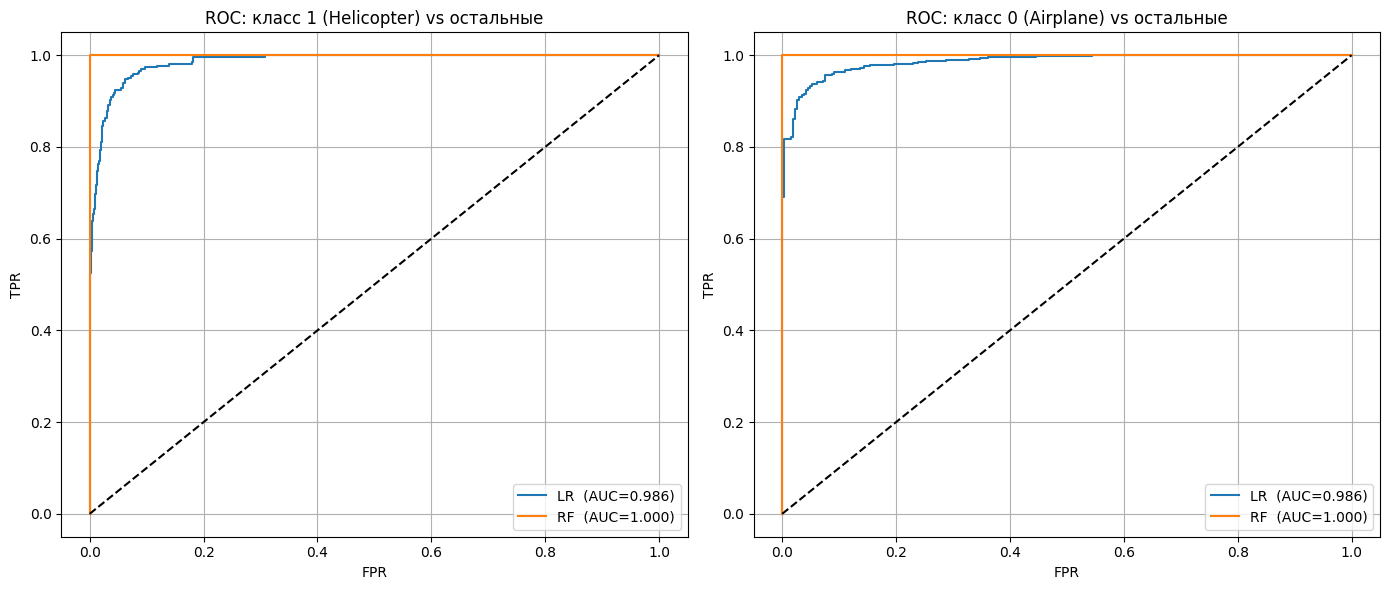

In [11]:
# ============================================================
# 21. predict_proba и ROC-AUC для бинарной классификации
# ============================================================
from sklearn.metrics import average_precision_score

print("\n" + "=" * 60)
print("21. predict_proba и ROC-AUC (бинарная классификация)")
print("=" * 60)

# Классы в задаче
classes = np.unique(y_train)
print("Классы в таргете:", classes)
print("Распределение в y_train:", dict(zip(*np.unique(y_train, return_counts=True))))

# predict_proba возвращает вероятности для каждого класса
proba_lr = lr_pipe.predict_proba(X_test)   # shape (n_samples, 2)
proba_rf = rf_pipe.predict_proba(X_test)

print("\nФорма predict_proba (LR):", proba_lr.shape)
print("Форма predict_proba (RF):", proba_rf.shape)

# Явно разложим на классы
p0_lr, p1_lr = proba_lr[:, 0], proba_lr[:, 1]
p0_rf, p1_rf = proba_rf[:, 0], proba_rf[:, 1]

# Проверка: суммы вероятностей по строке = 1
assert np.allclose(p0_lr + p1_lr, 1.0), "LR: p0 + p1 != 1"
assert np.allclose(p0_rf + p1_rf, 1.0), "RF: p0 + p1 != 1"
print("Проверка p0 + p1 = 1: OK")


# --- ROC-AUC для класса 1 (положительный класс) ---
fpr_lr_1, tpr_lr_1, _ = roc_curve(y_test, p1_lr, pos_label=1)
fpr_rf_1, tpr_rf_1, _ = roc_curve(y_test, p1_rf, pos_label=1)
auc_lr_1 = auc(fpr_lr_1, tpr_lr_1)
auc_rf_1 = auc(fpr_rf_1, tpr_rf_1)


# --- ROC-AUC для класса 0 (класс 0 против остальных) ---
# pos_label=0 означает, что "положительный" — это класс 0.
# Эквивалентно использованию вероятности p0.
fpr_lr_0, tpr_lr_0, _ = roc_curve(y_test, p0_lr, pos_label=0)
fpr_rf_0, tpr_rf_0, _ = roc_curve(y_test, p0_rf, pos_label=0)
auc_lr_0 = auc(fpr_lr_0, tpr_lr_0)
auc_rf_0 = auc(fpr_rf_0, tpr_rf_0)

# PR-AUC (average precision) для контроля при дисбалансе
ap_lr_1 = average_precision_score((y_test == 1).astype(int), p1_lr)
ap_rf_1 = average_precision_score((y_test == 1).astype(int), p1_rf)
ap_lr_0 = average_precision_score((y_test == 0).astype(int), p0_lr)
ap_rf_0 = average_precision_score((y_test == 0).astype(int), p0_rf)


# --- Сводная таблица ---
df_binary = pd.DataFrame({
    'Model'         : ['LogisticRegression', 'RandomForest'],
    'ROC_AUC class1': [auc_lr_1, auc_rf_1],
    'ROC_AUC class0': [auc_lr_0, auc_rf_0],
    'PR_AUC  class1': [ap_lr_1, ap_rf_1],
    'PR_AUC  class0': [ap_lr_0, ap_rf_0],
}).round(4)

print("\n=== ROC-AUC и PR-AUC для класса 1 и класса 0 ===")
print(df_binary)


# --- График: ROC для класса 1 и для класса 0 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График для класса 1
axes[0].plot(fpr_lr_1, tpr_lr_1, label=f'LR  (AUC={auc_lr_1:.3f})')
axes[0].plot(fpr_rf_1, tpr_rf_1, label=f'RF  (AUC={auc_rf_1:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC: класс 1 (Helicopter) vs остальные')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# График для класса 0
axes[1].plot(fpr_lr_0, tpr_lr_0, label=f'LR  (AUC={auc_lr_0:.3f})')
axes[1].plot(fpr_rf_0, tpr_rf_0, label=f'RF  (AUC={auc_rf_0:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC: класс 0 (Airplane) vs остальные')
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('roc_binary_both_classes.png', dpi=150)
plt.show()


22. Визуализация SHAP
Индексация наблюдения: 0
Истинный класс: 1, вероятность класса 1 по RF: 1.0000


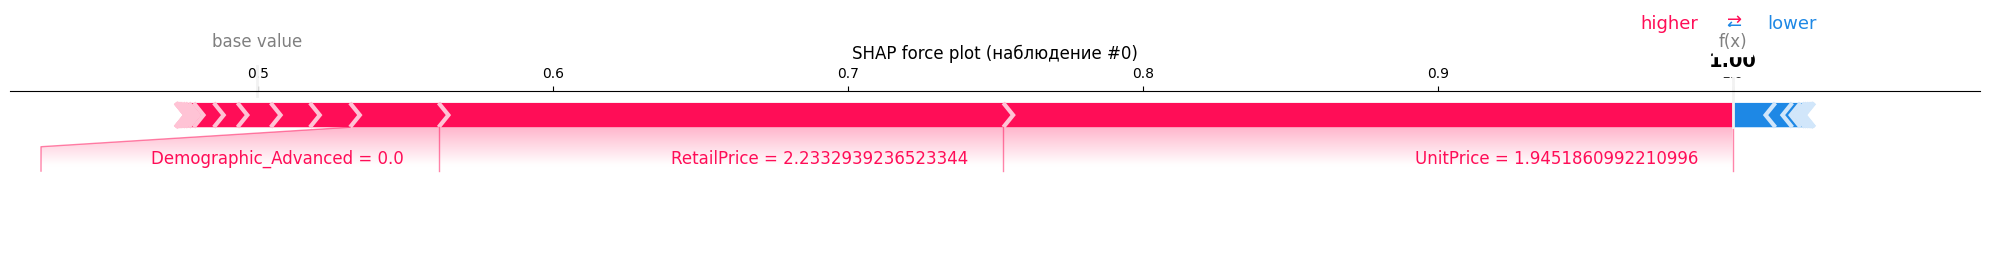

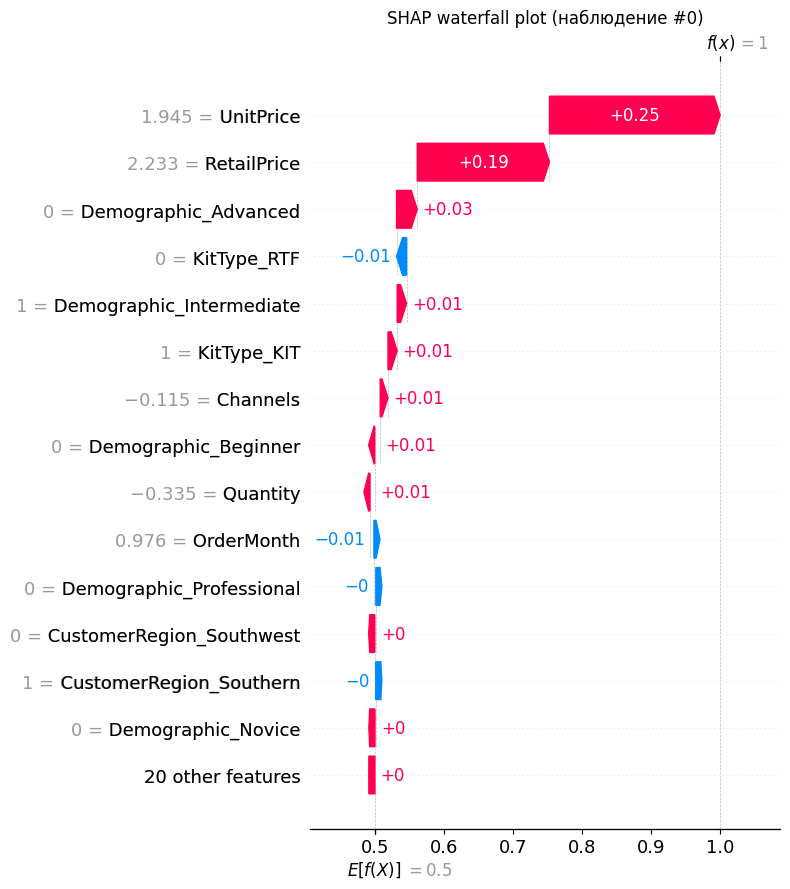


Топ-1 признак по |SHAP|: RetailPrice


<Figure size 640x480 with 0 Axes>

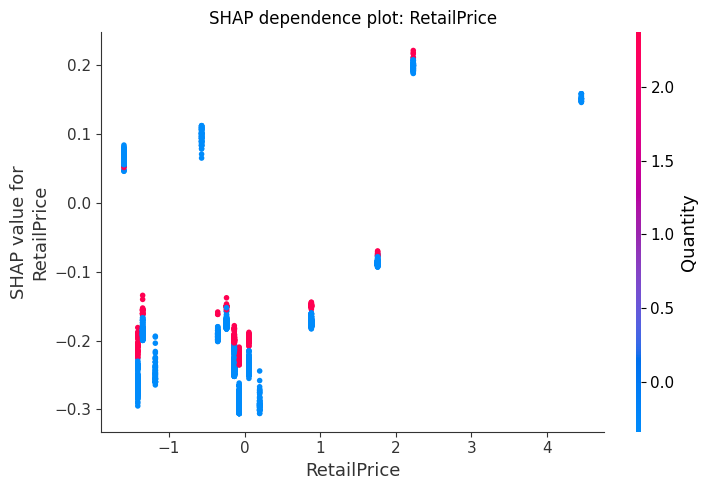


=== Сравнение SHAP: LogisticRegression vs RandomForest ===
                     Feature  MeanAbsSHAP_LR  MeanAbsSHAP_RF  SHAPNorm_LR  SHAPNorm_RF
0                RetailPrice         12.3896          0.2060       0.3971       0.3568
1                  UnitPrice         12.4194          0.1894       0.3981       0.3281
2       Demographic_Advanced          1.1880          0.0442       0.0381       0.0766
3                KitType_RTF          0.6052          0.0209       0.0194       0.0362
4                   Channels          0.2696          0.0187       0.0086       0.0324
5         Demographic_Novice          0.6572          0.0182       0.0211       0.0316
6       Demographic_Beginner          0.4380          0.0146       0.0140       0.0252
7                   Quantity          0.7221          0.0142       0.0231       0.0246
8   Demographic_Intermediate          0.5480          0.0117       0.0176       0.0202
9                KitType_KIT          0.9309          0.0106       0.0

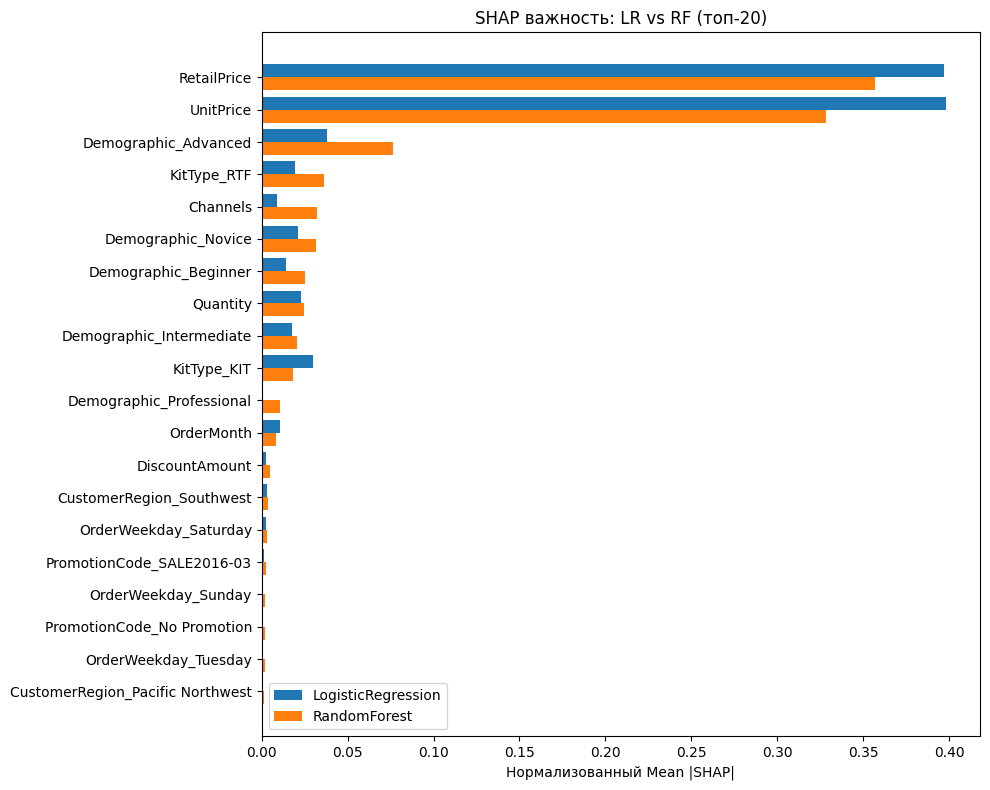

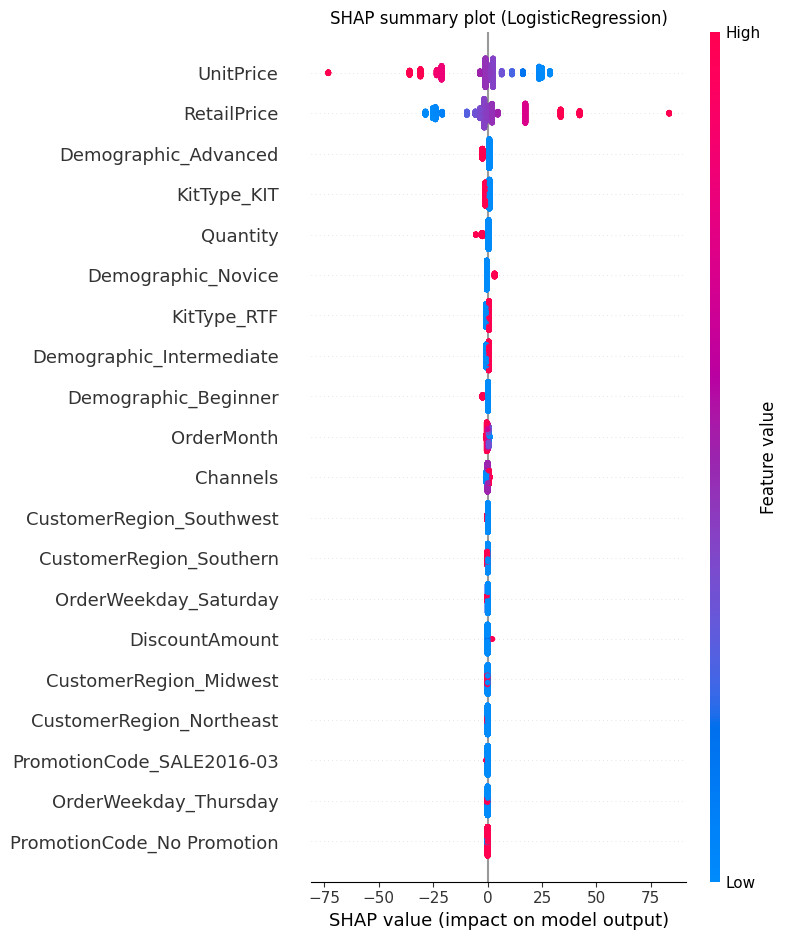

In [12]:
# ============================================================
# 22. Дополнительная визуализация SHAP
# ============================================================
print("\n" + "=" * 60)
print("22. Визуализация SHAP")
print("=" * 60)

# --- 22.1. Force plot для одного наблюдения ---
# Берём первое наблюдение из тестовой выборки
idx = 0
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1] if len(np.atleast_1d(base_value)) > 1 else base_value[0]

print(f"Индексация наблюдения: {idx}")
print(f"Истинный класс: {y_test.iloc[idx]}, "
      f"вероятность класса 1 по RF: {p1_rf[idx]:.4f}")

# Force plot (сохраняем в HTML + как PNG через matplotlib-совместимый вывод)
shap.initjs()
force_plot = shap.force_plot(
    base_value,
    shap_values_pos[idx, :],
    X_test_transformed[idx, :],
    feature_names=all_feature_names,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP force plot (наблюдение #{idx})')
plt.tight_layout()
plt.savefig('shap_force_single.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 22.2. Waterfall plot для одного наблюдения ---
# Waterfall требует объект Explanation
explanation = shap.Explanation(
    values        = shap_values_pos[idx, :],
    base_values   = base_value,
    data          = X_test_transformed[idx, :],
    feature_names = all_feature_names
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(f'SHAP waterfall plot (наблюдение #{idx})')
plt.tight_layout()
plt.savefig('shap_waterfall_single.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 22.3. Dependence plot для топ-1 признака ---
top_feature_name = df_importance.iloc[0]['Feature']
top_feature_idx  = all_feature_names.index(top_feature_name)

print(f"\nТоп-1 признак по |SHAP|: {top_feature_name}")

plt.figure()
shap.dependence_plot(
    top_feature_idx,
    shap_values_pos,
    X_test_transformed,
    feature_names=all_feature_names,
    show=False
)
plt.title(f'SHAP dependence plot: {top_feature_name}')
plt.tight_layout()
plt.savefig('shap_dependence_top1.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 22.4. SHAP для LogisticRegression (LinearExplainer) ---
# Для линейных моделей TreeExplainer не работает — используем LinearExplainer.
# Обучаем его на фоне X_train (после препроцессинга).
X_train_transformed = lr_pipe.named_steps['prep'].transform(X_train)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
X_train_transformed = np.asarray(X_train_transformed, dtype=np.float64)

lr_model = lr_pipe.named_steps['clf']

# Фоновая выборка: для скорости берём подвыборку
bg_size = min(100, X_train_transformed.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
bg_idx = rng.choice(X_train_transformed.shape[0], bg_size, replace=False)
background = X_train_transformed[bg_idx]

linear_explainer = shap.LinearExplainer(lr_model, background)
shap_values_lr  = linear_explainer.shap_values(X_test_transformed)

# Приводим к формату (n_samples, n_features) для положительного класса
if isinstance(shap_values_lr, list):
    shap_values_lr_pos = shap_values_lr[1]
elif shap_values_lr.ndim == 3:
    shap_values_lr_pos = shap_values_lr[:, :, 1]
else:
    shap_values_lr_pos = shap_values_lr

# Сравнение глобальной важности: LR vs RF по среднему |SHAP|
mean_abs_shap_lr = np.abs(shap_values_lr_pos).mean(axis=0)
df_importance_lr = pd.DataFrame({
    'Feature': all_feature_names,
    'MeanAbsSHAP_LR': mean_abs_shap_lr,
    'MeanAbsSHAP_RF': mean_abs_shap
}).sort_values('MeanAbsSHAP_RF', ascending=False).reset_index(drop=True)

df_importance_lr['SHAPNorm_LR'] = (df_importance_lr['MeanAbsSHAP_LR'] /
                                   df_importance_lr['MeanAbsSHAP_LR'].sum())
df_importance_lr['SHAPNorm_RF'] = (df_importance_lr['MeanAbsSHAP_RF'] /
                                   df_importance_lr['MeanAbsSHAP_RF'].sum())

print("\n=== Сравнение SHAP: LogisticRegression vs RandomForest ===")
print(df_importance_lr.round(4).head(15))

# Bar plot сравнения LR vs RF по SHAP
top20 = df_importance_lr.head(20).copy()
fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top20))
ax.barh(y_pos - 0.2, top20['SHAPNorm_LR'], height=0.4, label='LogisticRegression')
ax.barh(y_pos + 0.2, top20['SHAPNorm_RF'], height=0.4, label='RandomForest')
ax.set_yticks(y_pos)
ax.set_yticklabels(top20['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Нормализованный Mean |SHAP|')
ax.set_title('SHAP важность: LR vs RF (топ-20)')
ax.legend()
plt.tight_layout()
plt.savefig('shap_lr_vs_rf.png', dpi=150)
plt.show()

# Summary plot для LR
plt.figure()
shap.summary_plot(shap_values_lr_pos, X_test_transformed,
                  feature_names=all_feature_names, show=False)
plt.title('SHAP summary plot (LogisticRegression)')
plt.tight_layout()
plt.savefig('shap_summary_lr.png', dpi=150)
plt.show()



23. Оптимизация гиперпараметров
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

=== GridSearchCV (RandomForest) ===
Лучшие параметры: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Лучший ROC-AUC (CV): 1.0000
ROC-AUC на тесте (best RF): 1.0000
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== RandomizedSearchCV (LogisticRegression) ===
Лучшие параметры: {'clf__solver': 'saga', 'clf__penalty': 'l2', 'clf__max_iter': 2000, 'clf__C': 100}
Лучший ROC-AUC (CV): 1.0000
ROC-AUC на тесте (best LR): 1.0000

=== Сравнение ROC-AUC: baseline vs optimized ===
           Model  ROC_AUC
0  LR (baseline)   0.9856
1  RF (baseline)   1.0000
2  LR (best, RS)   1.0000
3  RF (best, GS)   1.0000


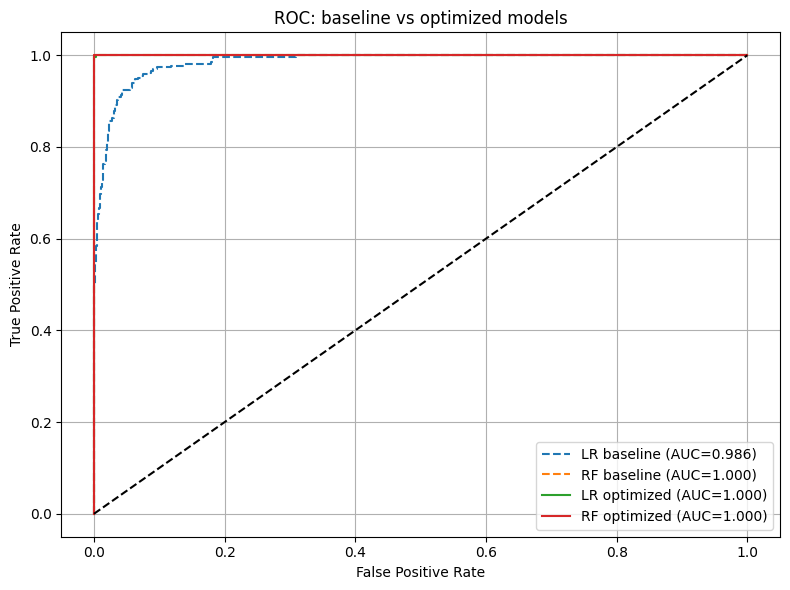


=== Топ-15 признаков оптимизированной RandomForest ===
                      Feature  Importance
4                 RetailPrice      0.3672
1                   UnitPrice      0.3381
8        Demographic_Advanced      0.0557
3                    Channels      0.0400
7                 KitType_RTF      0.0354
11         Demographic_Novice      0.0334
9        Demographic_Beginner      0.0300
6                 KitType_KIT      0.0193
0                    Quantity      0.0186
10   Demographic_Intermediate      0.0181
5                  OrderMonth      0.0099
12   Demographic_Professional      0.0088
2              DiscountAmount      0.0076
18   CustomerRegion_Southwest      0.0021
30  PromotionCode_SALE2016-03      0.0014


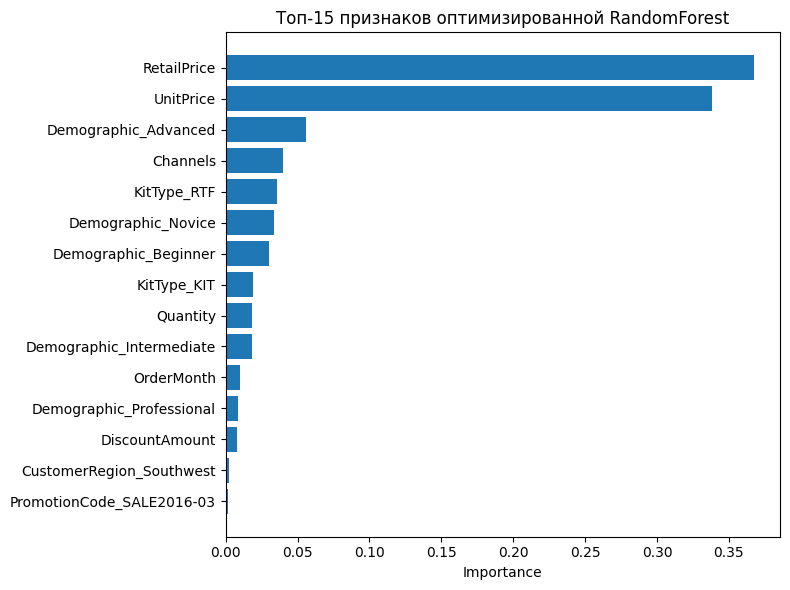


Результаты оптимизации сохранены в optimization_results.xlsx


In [13]:
# ============================================================
# 23. Оптимизация гиперпараметров
# ============================================================
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

print("\n" + "=" * 60)
print("23. Оптимизация гиперпараметров")
print("=" * 60)

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


# --- 23.1. GridSearchCV для RandomForest ---
param_grid_rf = {
    'clf__n_estimators'     : [100, 200, 300],
    'clf__max_depth'        : [None, 5, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__max_features'     : ['sqrt', 'log2']
}

rf_pipe_grid = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

grid_rf = GridSearchCV(
    rf_pipe_grid,
    param_grid_rf,
    scoring='roc_auc',
    cv=cv_inner,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

print("\n=== GridSearchCV (RandomForest) ===")
print("Лучшие параметры:", grid_rf.best_params_)
print(f"Лучший ROC-AUC (CV): {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_best_rf)
auc_best_rf = auc(fpr_b, tpr_b)
print(f"ROC-AUC на тесте (best RF): {auc_best_rf:.4f}")


# --- 23.2. RandomizedSearchCV для LogisticRegression ---
param_dist_lr = {
    'clf__C'        : [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty'  : ['l2'],           # 'l1' требует solver='liblinear'/'saga'
    'clf__solver'   : ['lbfgs', 'saga'],
    'clf__max_iter' : [500, 1000, 2000]
}

lr_pipe_rand = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

rand_lr = RandomizedSearchCV(
    lr_pipe_rand,
    param_dist_lr,
    n_iter=20,
    scoring='roc_auc',
    cv=cv_inner,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rand_lr.fit(X_train, y_train)

print("\n=== RandomizedSearchCV (LogisticRegression) ===")
print("Лучшие параметры:", rand_lr.best_params_)
print(f"Лучший ROC-AUC (CV): {rand_lr.best_score_:.4f}")

best_lr = rand_lr.best_estimator_
y_proba_best_lr = best_lr.predict_proba(X_test)[:, 1]
fpr_bl, tpr_bl, _ = roc_curve(y_test, y_proba_best_lr)
auc_best_lr = auc(fpr_bl, tpr_bl)
print(f"ROC-AUC на тесте (best LR): {auc_best_lr:.4f}")


# --- 23.3. Сравнение: базовые vs оптимизированные модели ---
df_opt = pd.DataFrame([
    {'Model': 'LR (baseline)',  'ROC_AUC': auc_lr_1},
    {'Model': 'RF (baseline)',  'ROC_AUC': auc_rf_1},
    {'Model': 'LR (best, RS)',  'ROC_AUC': auc_best_lr},
    {'Model': 'RF (best, GS)',  'ROC_AUC': auc_best_rf},
]).round(4)

print("\n=== Сравнение ROC-AUC: baseline vs optimized ===")
print(df_opt)


# --- 23.4. ROC-кривые baseline vs optimized ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_1, tpr_lr_1, linestyle='--', label=f'LR baseline (AUC={auc_lr_1:.3f})')
plt.plot(fpr_rf_1, tpr_rf_1, linestyle='--', label=f'RF baseline (AUC={auc_rf_1:.3f})')
plt.plot(fpr_bl,   tpr_bl,   label=f'LR optimized (AUC={auc_best_lr:.3f})')
plt.plot(fpr_b,    tpr_b,    label=f'RF optimized (AUC={auc_best_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC: baseline vs optimized models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_baseline_vs_optimized.png', dpi=150)
plt.show()


# --- 23.5. Важность признаков лучшей RF модели ---
# Достаём важности из оптимизированной модели
best_rf_model = best_rf.named_steps['clf']
best_rf_prep  = best_rf.named_steps['prep']

ohe_best = best_rf_prep.named_transformers_['cat']
cat_features_best = ohe_best.get_feature_names_out(cat_cols)
all_features_best = num_cols + list(cat_features_best)

df_best_imp = (
    pd.DataFrame({
        'Feature': all_features_best,
        'Importance': best_rf_model.feature_importances_
    })
    .sort_values('Importance', ascending=False)
    .head(15)
    .round(4)
)

print("\n=== Топ-15 признаков оптимизированной RandomForest ===")
print(df_best_imp)

plt.figure(figsize=(8, 6))
plt.barh(df_best_imp['Feature'][::-1], df_best_imp['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Топ-15 признаков оптимизированной RandomForest')
plt.tight_layout()
plt.savefig('best_rf_feature_importance.png', dpi=150)
plt.show()


# --- 23.6. Сохранение результатов оптимизации в Excel ---
with pd.ExcelWriter('optimization_results.xlsx') as writer:
    df_binary.to_excel(writer, sheet_name='binary_roc_pr', index=False)
    df_importance_lr.round(4).to_excel(writer, sheet_name='shap_lr_vs_rf', index=False)
    df_opt.to_excel(writer, sheet_name='baseline_vs_optimized', index=False)
    pd.DataFrame(grid_rf.cv_results_).to_excel(writer, sheet_name='grid_rf_cv', index=False)
    pd.DataFrame(rand_lr.cv_results_).to_excel(writer, sheet_name='rand_lr_cv', index=False)
    df_best_imp.to_excel(writer, sheet_name='best_rf_importance', index=False)

print("\nРезультаты оптимизации сохранены в optimization_results.xlsx")

In [14]:
# ============================================================
# 24. Подготовка данных для кластеризации
# ============================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

print("\n" + "=" * 60)
print("24. Подготовка данных для кластеризации")
print("=" * 60)

# Используем те же num_cols и cat_cols, что и в ML-задаче,
# но БЕЗ таргета — кластеризация это unsupervised.

X_clust = df_fact[features].copy()

# Удаляем пропуски
mask_clust = X_clust.notna().all(axis=1)
X_clust = X_clust[mask_clust].reset_index(drop=True)

print("Размер выборки для кластеризации:", X_clust.shape)

# Кодируем: числовые — StandardScaler, категориальные — OneHot
prep_clust = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_clust_transformed = prep_clust.fit_transform(X_clust)

# Приводим к плотному float64 (KMeans умеет sparse, но PCA/TSNE/silhouette — нет)
if hasattr(X_clust_transformed, "toarray"):
    X_clust_transformed = X_clust_transformed.toarray()
X_clust_transformed = np.asarray(X_clust_transformed, dtype=np.float64)

print("Форма матрицы признаков:", X_clust_transformed.shape)


24. Подготовка данных для кластеризации
Размер выборки для кластеризации: (10000, 11)
Форма матрицы признаков: (10000, 34)



25. Оптимальное количество кластеров
k= 2 | inertia=  70525.41 | silhouette=0.2377 | davies_bouldin=1.6538
k= 3 | inertia=  60717.69 | silhouette=0.2229 | davies_bouldin=1.7266
k= 4 | inertia=  53827.56 | silhouette=0.2351 | davies_bouldin=1.5610
k= 5 | inertia=  49257.83 | silhouette=0.2301 | davies_bouldin=1.5156
k= 6 | inertia=  43469.98 | silhouette=0.2437 | davies_bouldin=1.4032
k= 7 | inertia=  40550.97 | silhouette=0.1975 | davies_bouldin=1.4963
k= 8 | inertia=  38575.10 | silhouette=0.1919 | davies_bouldin=1.5740
k= 9 | inertia=  37052.68 | silhouette=0.1860 | davies_bouldin=1.5946
k=10 | inertia=  35414.41 | silhouette=0.1902 | davies_bouldin=1.5921

Оптимальное k по силуэту: 6
Оптимальное k по методу локтя: 6


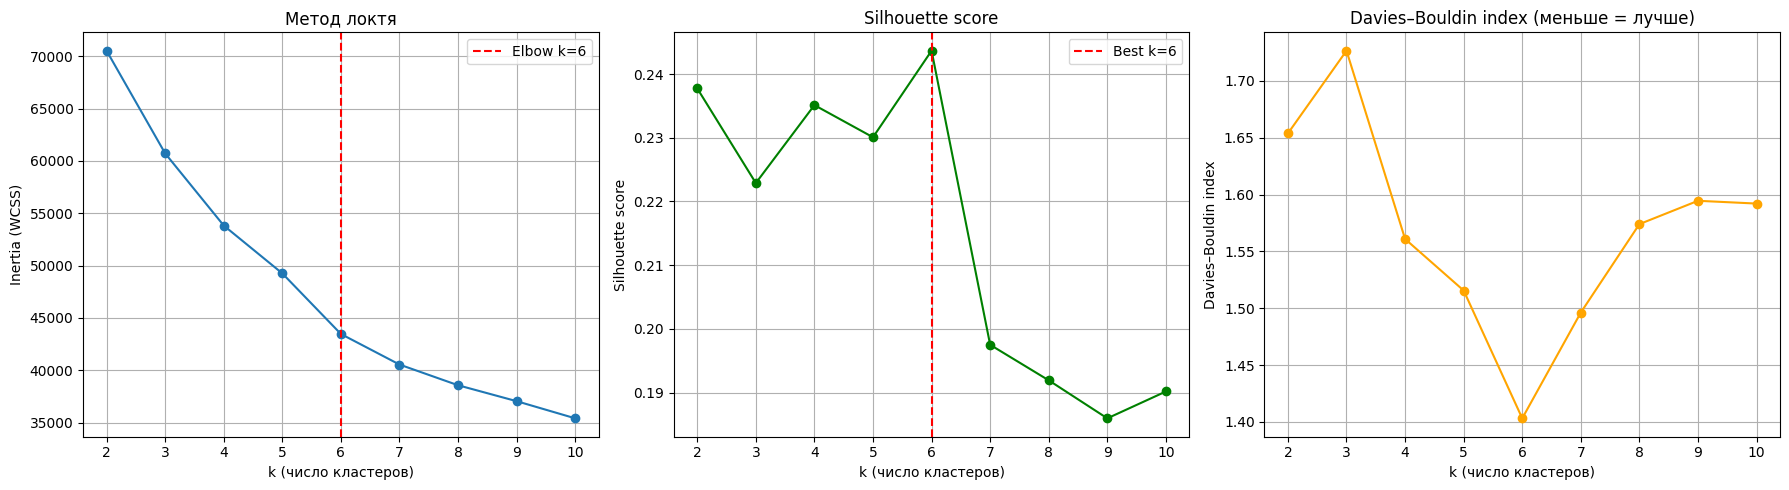


=== Метрики кластеризации ===
    k     Inertia  Silhouette  DaviesBouldin
0   2  70525.4127      0.2377         1.6538
1   3  60717.6890      0.2229         1.7266
2   4  53827.5568      0.2351         1.5610
3   5  49257.8305      0.2301         1.5156
4   6  43469.9753      0.2437         1.4032
5   7  40550.9678      0.1975         1.4963
6   8  38575.1024      0.1919         1.5740
7   9  37052.6826      0.1860         1.5946
8  10  35414.4056      0.1902         1.5921


In [15]:
# ============================================================
# 25. Метод локтя и silhouette — поиск оптимального k
# ============================================================
print("\n" + "=" * 60)
print("25. Оптимальное количество кластеров")
print("=" * 60)

k_range = range(2, 11)
inertias   = []
sil_scores = []
db_scores  = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust_transformed)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust_transformed, labels))
    db_scores.append(davies_bouldin_score(X_clust_transformed, labels))

    print(f"k={k:2d} | inertia={km.inertia_:10.2f} | "
          f"silhouette={sil_scores[-1]:.4f} | davies_bouldin={db_scores[-1]:.4f}")


# --- Определение оптимального k автоматически ---

# 1) По силуэту: максимум silhouette score
best_k_sil = list(k_range)[int(np.argmax(sil_scores))]

# 2) По методу локтя: точка максимального "перегиба".
#    Используем простую эвристику: максимальное расстояние от точки
#    до прямой, соединяющей первую и последнюю точки графика.
def elbow_k(k_vals, inertias):
    k_vals = np.array(list(k_vals), dtype=float)
    y = np.array(inertias, dtype=float)
    x1, y1 = k_vals[0], y[0]
    x2, y2 = k_vals[-1], y[-1]
    # расстояние от каждой точки до прямой (x1,y1)-(x2,y2)
    num = np.abs((y2 - y1) * k_vals - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    dist = num / den
    return int(k_vals[np.argmax(dist)])

best_k_elbow = elbow_k(k_range, inertias)

print(f"\nОптимальное k по силуэту: {best_k_sil}")
print(f"Оптимальное k по методу локтя: {best_k_elbow}")


# --- Графики ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Метод локтя
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].axvline(best_k_elbow, color='red', linestyle='--',
                label=f'Elbow k={best_k_elbow}')
axes[0].set_xlabel('k (число кластеров)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Метод локтя')
axes[0].legend()
axes[0].grid(True)

# Silhouette
axes[1].plot(list(k_range), sil_scores, marker='o', color='green')
axes[1].axvline(best_k_sil, color='red', linestyle='--',
                label=f'Best k={best_k_sil}')
axes[1].set_xlabel('k (число кластеров)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')
axes[1].legend()
axes[1].grid(True)

# Davies–Bouldin (чем меньше, тем лучше)
axes[2].plot(list(k_range), db_scores, marker='o', color='orange')
axes[2].set_xlabel('k (число кластеров)')
axes[2].set_ylabel('Davies–Bouldin index')
axes[2].set_title('Davies–Bouldin index (меньше = лучше)')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('cluster_optimal_k.png', dpi=150)
plt.show()


# --- Сводная таблица ---
df_k = pd.DataFrame({
    'k'               : list(k_range),
    'Inertia'         : inertias,
    'Silhouette'      : sil_scores,
    'DaviesBouldin'   : db_scores,
}).round(4)

print("\n=== Метрики кластеризации ===")
print(df_k)

In [16]:
# ============================================================
# 26. Финальная модель KMeans
# ============================================================
print("\n" + "=" * 60)
print("26. Финальная модель KMeans при оптимальном k")
print("=" * 60)

# Как правило, silhouette даёт более чистую оценку. Если методы расходятся —
# можно взять среднее или ориентироваться на бизнес-смысл.
optimal_k = best_k_sil
print(f"Используем k = {optimal_k} (по силуэту)")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_clust_transformed)

X_clust['Cluster'] = cluster_labels

# Дополнительно сохраним кластеры в fact_sales по индексу (если индексы совпадают)
print("\nРаспределение по кластерам:")
print(X_clust['Cluster'].value_counts().sort_index())

# Финальные метрики
print(f"\nSilhouette: {silhouette_score(X_clust_transformed, cluster_labels):.4f}")
print(f"Davies–Bouldin: {davies_bouldin_score(X_clust_transformed, cluster_labels):.4f}")
print(f"Inertia: {kmeans_final.inertia_:.2f}")



26. Финальная модель KMeans при оптимальном k
Используем k = 6 (по силуэту)

Распределение по кластерам:
Cluster
0     850
1    1754
2    1713
3     537
4    4219
5     927
Name: count, dtype: int64

Silhouette: 0.2437
Davies–Bouldin: 1.4032
Inertia: 43469.98



PCA: объяснённая дисперсия по компонентам: [0.32116905 0.13178276]
Суммарно объяснено: 0.4530


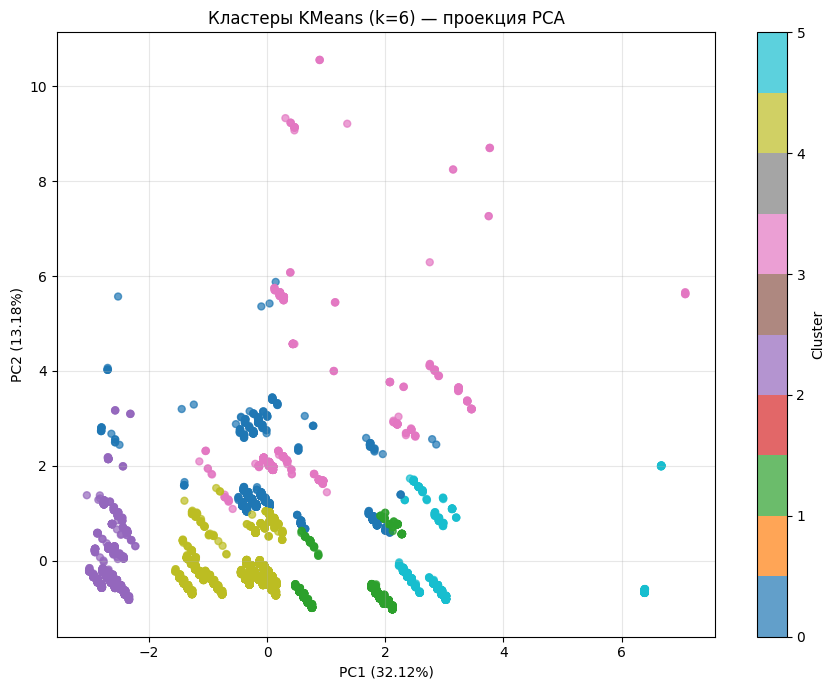

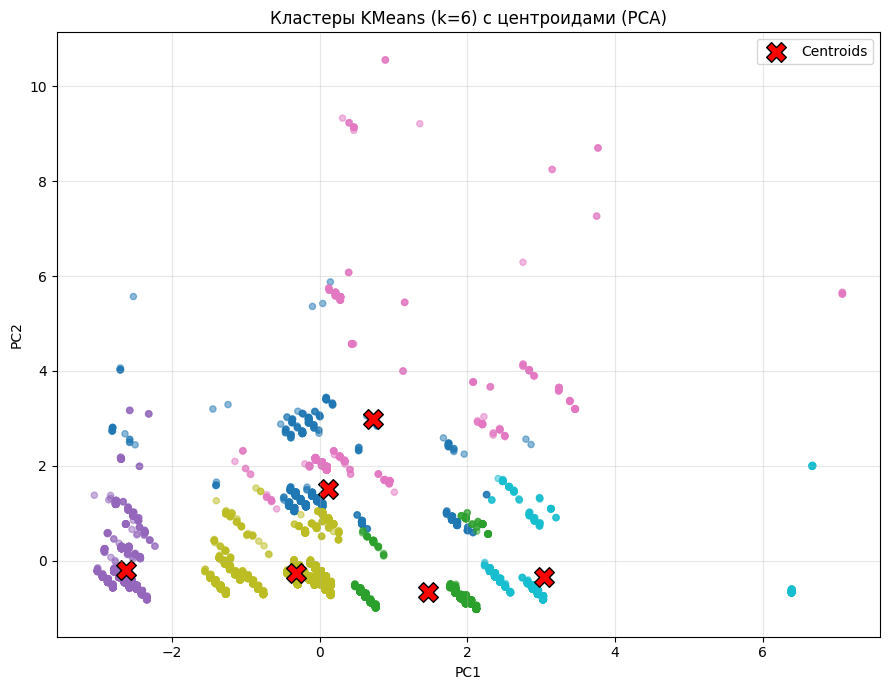

In [17]:
# ============================================================
# 27.1. Визуализация кластеров через PCA
# ============================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust_transformed)

print(f"\nPCA: объяснённая дисперсия по компонентам: {pca.explained_variance_ratio_}")
print(f"Суммарно объяснено: {pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels, cmap='tab10',
                      s=25, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'Кластеры KMeans (k={optimal_k}) — проекция PCA')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=150)
plt.show()

# Центроиды в PCA-пространстве
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.figure(figsize=(9, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=cluster_labels, cmap='tab10',
            s=20, alpha=0.5)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='X', s=200, edgecolor='black',
            label='Centroids')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Кластеры KMeans (k={optimal_k}) с центроидами (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clusters_pca_centroids.png', dpi=150)
plt.show()

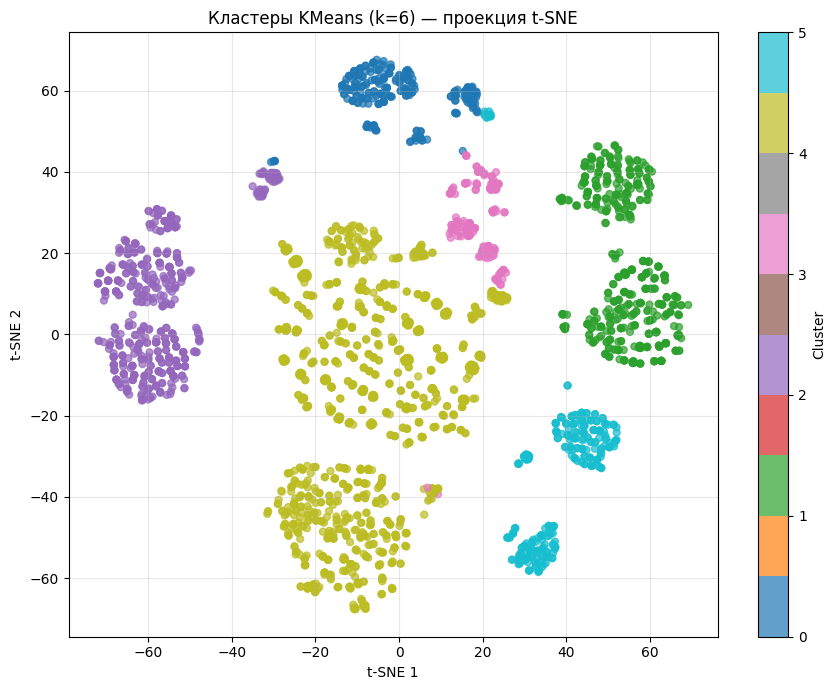

In [18]:
# ============================================================
# 27.2. Визуализация кластеров через t-SNE
# ============================================================
# На больших данных t-SNE может быть медленным — ограничим выборку 3000 точек
max_tsne = 3000
if X_clust_transformed.shape[0] > max_tsne:
    rng = np.random.RandomState(RANDOM_STATE)
    idx_tsne = rng.choice(X_clust_transformed.shape[0], max_tsne, replace=False)
    X_for_tsne = X_clust_transformed[idx_tsne]
    labels_tsne = cluster_labels[idx_tsne]
else:
    X_for_tsne = X_clust_transformed
    labels_tsne = cluster_labels

tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_for_tsne)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=labels_tsne, cmap='tab10',
                      s=25, alpha=0.7)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f'Кластеры KMeans (k={optimal_k}) — проекция t-SNE')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clusters_tsne.png', dpi=150)
plt.show()

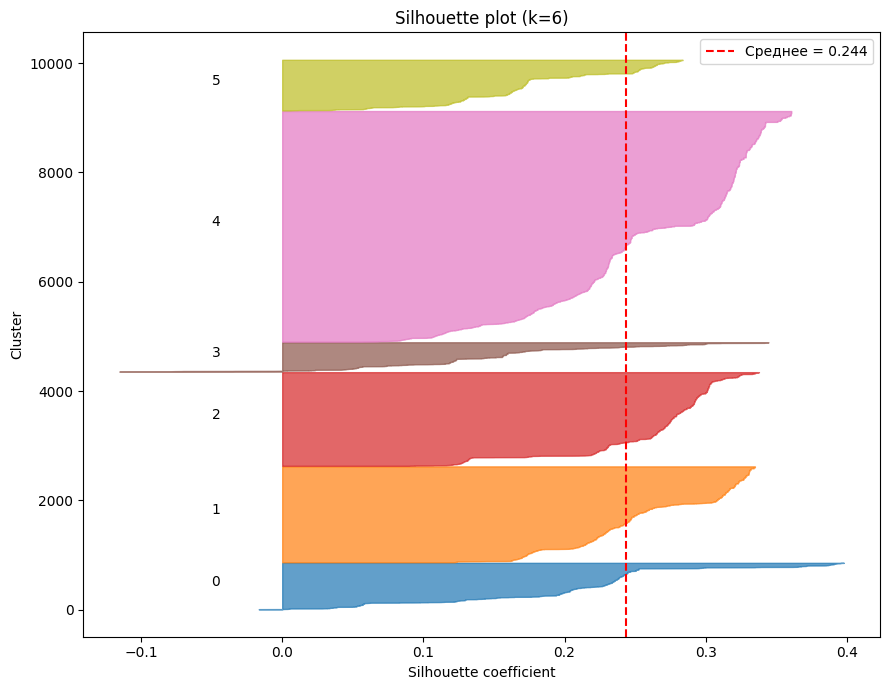

In [19]:
# ============================================================
# 27.3. Silhouette plot для каждого кластера
# ============================================================
sample_silhouette_values = silhouette_samples(X_clust_transformed, cluster_labels)

fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10

for i in range(optimal_k):
    ith_values = sample_silhouette_values[cluster_labels == i]
    ith_values.sort()
    size_cluster_i = ith_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.tab10(i / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_values,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

ax.axvline(silhouette_score(X_clust_transformed, cluster_labels),
           color='red', linestyle='--',
           label=f'Среднее = {silhouette_score(X_clust_transformed, cluster_labels):.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette plot (k={optimal_k})')
ax.legend()
plt.tight_layout()
plt.savefig('clusters_silhouette_plot.png', dpi=150)
plt.show()


=== Профили кластеров (средние значения) ===
         Quantity  UnitPrice  DiscountAmount  Channels  RetailPrice  OrderMonth  Size
Cluster                                                                              
0           2.149    173.881           0.872     4.194      204.454       4.288   850
1           1.000    222.380           0.607     5.000      240.195       3.978  1754
2           1.091     65.347           0.589     3.000       79.702       4.034  1713
3           1.177    182.099          21.737     4.244      216.532       3.736   537
4           1.000    154.854           0.428     3.937      186.813       4.030  4219
5           1.042    308.864           0.913     4.742      381.085       3.507   927


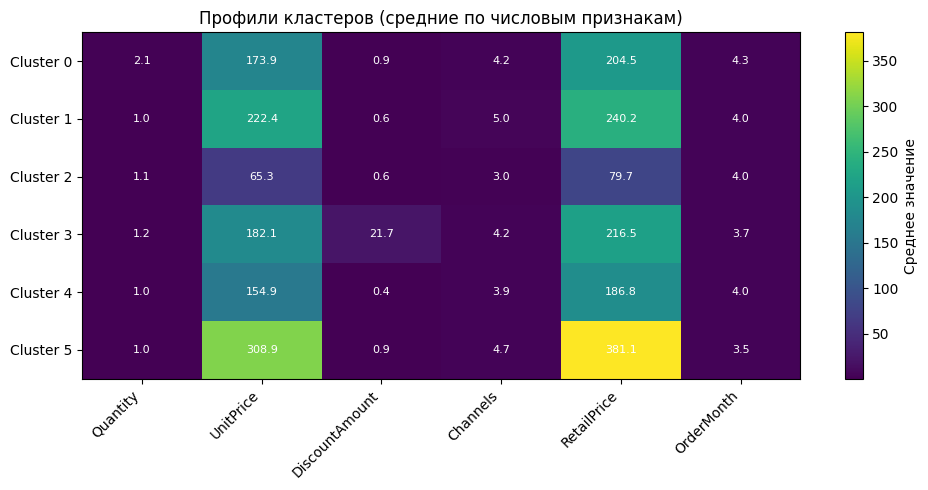


Результаты кластеризации сохранены в clustering_results.xlsx


In [20]:
# ============================================================
# 27.4. Профили кластеров
# ============================================================
cluster_profile = (
    X_clust
    .groupby('Cluster')[num_cols]
    .mean()
    .round(3)
)
cluster_profile['Size'] = X_clust.groupby('Cluster').size()
print("\n=== Профили кластеров (средние значения) ===")
print(cluster_profile)

# Тепловая карта профилей
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
data = cluster_profile[num_cols]
im = ax.imshow(data.values, aspect='auto', cmap='viridis')
ax.set_xticks(np.arange(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(np.arange(len(data)))
ax.set_yticklabels([f'Cluster {i}' for i in data.index])
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data.values[i, j]:.1f}",
                ha='center', va='center', color='white', fontsize=8)
plt.colorbar(im, ax=ax, label='Среднее значение')
plt.title('Профили кластеров (средние по числовым признакам)')
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()


# --- Сохранение результатов кластеризации ---
with pd.ExcelWriter('clustering_results.xlsx') as writer:
    df_k.to_excel(writer, sheet_name='k_metrics', index=False)
    cluster_profile.to_excel(writer, sheet_name='cluster_profiles')
    X_clust[['Cluster'] + features].to_excel(writer, sheet_name='cluster_labels', index=False)

print("\nРезультаты кластеризации сохранены в clustering_results.xlsx")


28. Автоподбор гиперпараметров KMeans
Всего комбинаций для перебора: 72

=== Топ-10 комбинаций KMeans по Silhouette ===
   n_clusters       init  n_init  max_iter     Inertia  Silhouette  DaviesBouldin  CalinskiHarabasz
0           4     random      10       500  56028.4032      0.2515         1.4036         2007.4283
1           4     random      10       300  56028.4032      0.2515         1.4036         2007.4283
2           5  k-means++      20       500  47539.1052      0.2492         1.4053         2220.4656
3           5  k-means++      20       300  47539.1052      0.2492         1.4053         2220.4656
4           6  k-means++      20       500  43469.9753      0.2437         1.4032         2129.5638
5           6  k-means++      20       300  43469.9753      0.2437         1.4032         2129.5638
6           6     random      20       300  43469.9753      0.2437         1.4032         2129.5638
7           6     random      20       500  43469.9753      0.2437         1.40

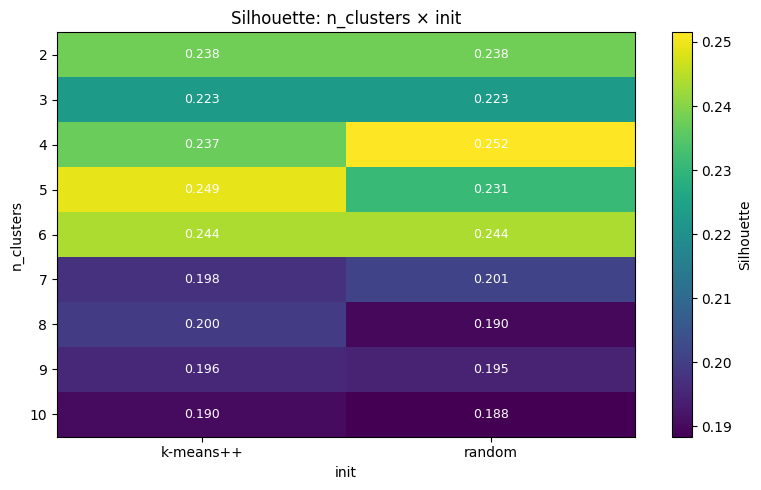


=== Лучшая модель KMeans ===
n_clusters = 4
Silhouette = 0.2515
DaviesBouldin = 1.4036
Inertia = 56028.40


In [21]:
# ============================================================
# 28. Автоподбор гиперпараметров KMeans через silhouette_score
# ============================================================
from itertools import product
from sklearn.metrics import calinski_harabasz_score

print("\n" + "=" * 60)
print("28. Автоподбор гиперпараметров KMeans")
print("=" * 60)

# Сетка гиперпараметров KMeans
kmeans_grid = {
    'n_clusters' : list(range(2, 11)),
    'init'       : ['k-means++', 'random'],
    'n_init'     : [10, 20],
    'max_iter'   : [300, 500],
}

keys   = list(kmeans_grid.keys())
values = list(kmeans_grid.values())
combos = list(product(*values))

print(f"Всего комбинаций для перебора: {len(combos)}")

results_kmeans = []

for combo in combos:
    params = dict(zip(keys, combo))
    km = KMeans(random_state=RANDOM_STATE, **params)
    labels = km.fit_predict(X_clust_transformed)

    # Пропускаем вырожденные случаи (один кластер или слишком много)
    n_unique = len(np.unique(labels))
    if n_unique < 2:
        continue

    sil = silhouette_score(X_clust_transformed, labels)
    db  = davies_bouldin_score(X_clust_transformed, labels)
    ch  = calinski_harabasz_score(X_clust_transformed, labels)

    results_kmeans.append({
        **params,
        'Inertia'      : km.inertia_,
        'Silhouette'   : sil,
        'DaviesBouldin': db,
        'CalinskiHarabasz': ch,
    })

df_kmeans_grid = (
    pd.DataFrame(results_kmeans)
    .sort_values('Silhouette', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

print("\n=== Топ-10 комбинаций KMeans по Silhouette ===")
print(df_kmeans_grid.head(10))


# --- Лучшая комбинация по Silhouette ---
best_row = df_kmeans_grid.iloc[0]
best_params_kmeans = {
    'n_clusters': int(best_row['n_clusters']),
    'init'      : best_row['init'],
    'n_init'    : int(best_row['n_init']),
    'max_iter'  : int(best_row['max_iter']),
}
print("\nЛучшие гиперпараметры KMeans:")
print(best_params_kmeans)
print(f"Silhouette = {best_row['Silhouette']:.4f}, "
      f"DaviesBouldin = {best_row['DaviesBouldin']:.4f}, "
      f"CalinskiHarabasz = {best_row['CalinskiHarabasz']:.2f}")


# --- Тепловая карта: Silhouette по (n_clusters × init) ---
pivot_sil = (
    df_kmeans_grid
    .groupby(['n_clusters', 'init'])['Silhouette']
    .max()
    .unstack()
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot_sil.values, cmap='viridis', aspect='auto')
ax.set_xticks(np.arange(pivot_sil.shape[1]))
ax.set_xticklabels(pivot_sil.columns)
ax.set_yticks(np.arange(pivot_sil.shape[0]))
ax.set_yticklabels(pivot_sil.index)
for i in range(pivot_sil.shape[0]):
    for j in range(pivot_sil.shape[1]):
        val = pivot_sil.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha='center', va='center',
                    color='white', fontsize=9)
plt.colorbar(im, ax=ax, label='Silhouette')
ax.set_xlabel('init')
ax.set_ylabel('n_clusters')
ax.set_title('Silhouette: n_clusters × init')
plt.tight_layout()
plt.savefig('kmeans_grid_silhouette.png', dpi=150)
plt.show()


# --- Финальная модель KMeans с лучшими гиперпараметрами ---
kmeans_best = KMeans(random_state=RANDOM_STATE, **best_params_kmeans)
labels_kmeans_best = kmeans_best.fit_predict(X_clust_transformed)

print("\n=== Лучшая модель KMeans ===")
print(f"n_clusters = {best_params_kmeans['n_clusters']}")
print(f"Silhouette = {silhouette_score(X_clust_transformed, labels_kmeans_best):.4f}")
print(f"DaviesBouldin = {davies_bouldin_score(X_clust_transformed, labels_kmeans_best):.4f}")
print(f"Inertia = {kmeans_best.inertia_:.2f}")

# Сохраняем в отдельный файл
df_kmeans_grid.to_excel('kmeans_grid_results.xlsx', index=False)


29. Иерархическая кластеризация


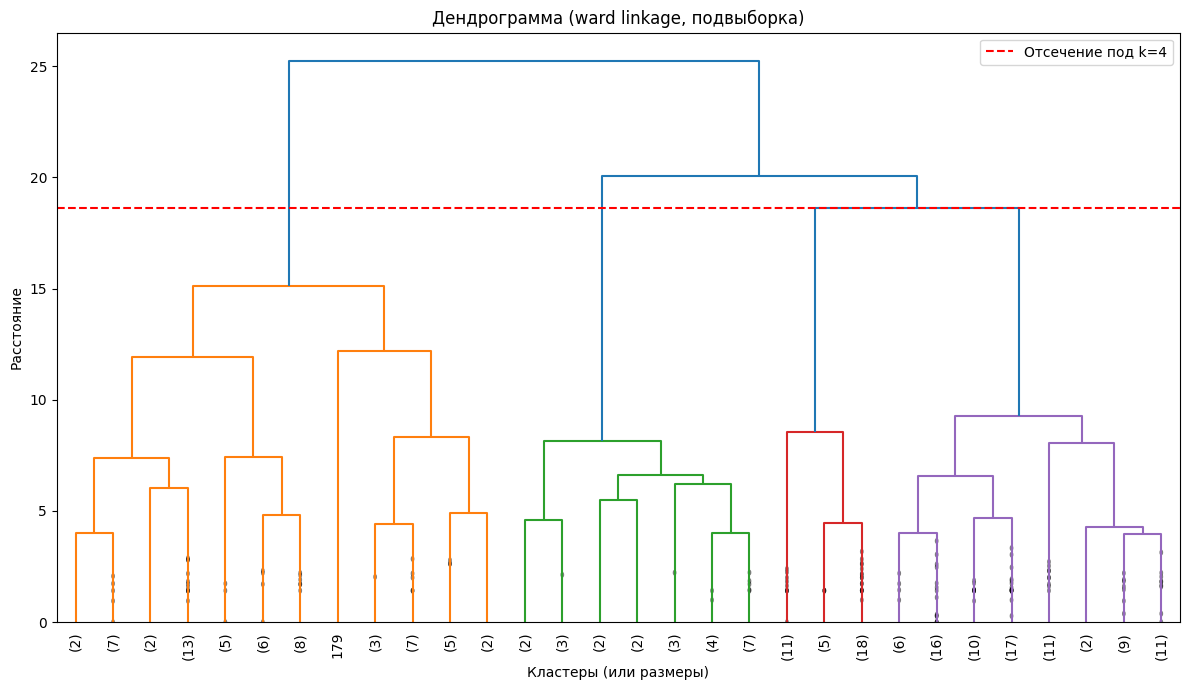


=== Иерархическая кластеризация (k=4) ===
    Linkage  Silhouette  DaviesBouldin  CalinskiHarabasz
2   average      0.4566         0.6352          245.4078
3    single      0.4545         0.4873          168.3250
0      ward      0.2187         1.6428         2042.1134
1  complete      0.2117         1.1904          741.9334

Лучший linkage: average
Silhouette (best hierarchical) = 0.4566


In [22]:
# ============================================================
# 29. Иерархическая кластеризация (Agglomerative) + дендрограмма
# ============================================================
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

print("\n" + "=" * 60)
print("29. Иерархическая кластеризация")
print("=" * 60)

# Иерархическая кластеризация очень чувствительна к размеру выборки:
# на 10 000+ наблюдениях дендрограмма становится нечитаемой.
# Ограничим визуализацию подвыборкой, а метрики посчитаем на полной.
max_dendro = 200

if X_clust_transformed.shape[0] > max_dendro:
    rng = np.random.RandomState(RANDOM_STATE)
    idx_h = rng.choice(X_clust_transformed.shape[0], max_dendro, replace=False)
    X_h = X_clust_transformed[idx_h]
else:
    X_h = X_clust_transformed

# --- Дендрограмма ---
# linkage: 'ward' минимизирует внутрикластерную дисперсию — самый популярный вариант
Z = linkage(X_h, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    truncate_mode='lastp',   # показываем только последние p слияний
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Дендрограмма (ward linkage, подвыборка)')
plt.xlabel('Кластеры (или размеры)')
plt.ylabel('Расстояние')
plt.axhline(y=Z[-best_params_kmeans['n_clusters'] + 1, 2],
            color='red', linestyle='--',
            label=f'Отсечение под k={best_params_kmeans["n_clusters"]}')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()


# --- Сравнение linkage-методов ---
linkage_methods = ['ward', 'complete', 'average', 'single']
k_hier = best_params_kmeans['n_clusters']  # используем то же k, что и в KMeans

results_hier = []
for method in linkage_methods:
    # Для 'ward' метрика только 'euclidean'; для остальных тоже оставим euclidean
    try:
        agg = AgglomerativeClustering(
            n_clusters=k_hier,
            linkage=method,
            metric='euclidean'
        )
        labels_h = agg.fit_predict(X_clust_transformed)
    except Exception as e:
        print(f"Метод {method} не сработал: {e}")
        continue

    if len(np.unique(labels_h)) < 2:
        continue

    results_hier.append({
        'Linkage'      : method,
        'Silhouette'   : silhouette_score(X_clust_transformed, labels_h),
        'DaviesBouldin': davies_bouldin_score(X_clust_transformed, labels_h),
        'CalinskiHarabasz': calinski_harabasz_score(X_clust_transformed, labels_h),
    })

df_hier = pd.DataFrame(results_hier).sort_values('Silhouette', ascending=False).round(4)
print(f"\n=== Иерархическая кластеризация (k={k_hier}) ===")
print(df_hier)


# --- Лучший linkage ---
best_linkage = df_hier.iloc[0]['Linkage']
print(f"\nЛучший linkage: {best_linkage}")

agg_best = AgglomerativeClustering(
    n_clusters=k_hier,
    linkage=best_linkage,
    metric='euclidean'
)
labels_hier_best = agg_best.fit_predict(X_clust_transformed)

print(f"Silhouette (best hierarchical) = "
      f"{silhouette_score(X_clust_transformed, labels_hier_best):.4f}")


30. DBSCAN и сравнение методов кластеризации


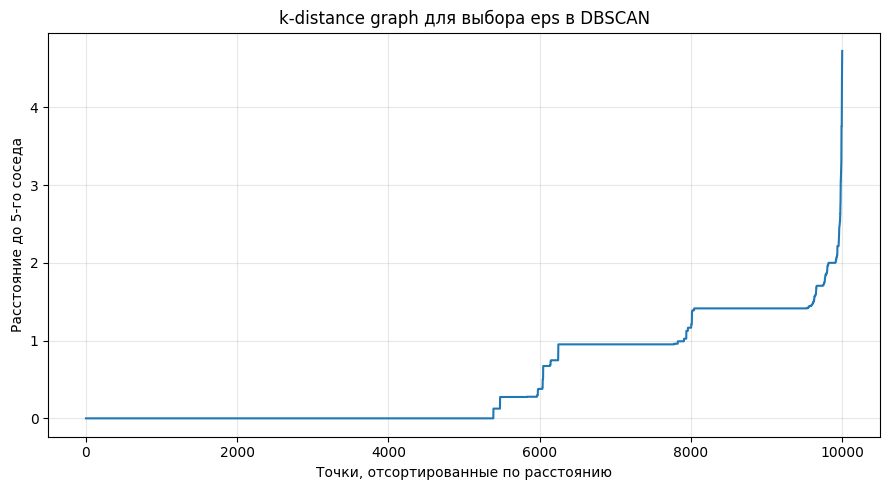

Автоматическая оценка eps (метод колена): 1.4178

=== Перебор гиперпараметров DBSCAN ===
       eps  min_samples  n_clusters  n_noise  noise_%  Silhouette  DaviesBouldin
1   0.7089            5         594     3857    38.57      0.9265         0.1783
0   0.7089            3        1099     2143    21.43      0.9256         0.1828
2   0.7089           10         205     6344    63.44      0.9191         0.1810
3   1.0634            3         613     1078    10.78      0.4268         0.9026
5   1.0634           10         251     3042    30.42      0.4178         1.0847
4   1.0634            5         413     1791    17.91      0.4151         1.0374
11  1.7723           10          21      326     3.26      0.2142         1.1053
10  1.7723            5          37      138     1.38      0.2089         1.1037
9   1.7723            3          52       42     0.42      0.1747         1.0386
8   1.4178           10          38      605     6.05      0.1483         1.3797
7   1.4178          

/tmp/ipykernel_3085/1278653824.py:149: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db = plt.cm.get_cmap('tab10', max(len(unique_db), 2))


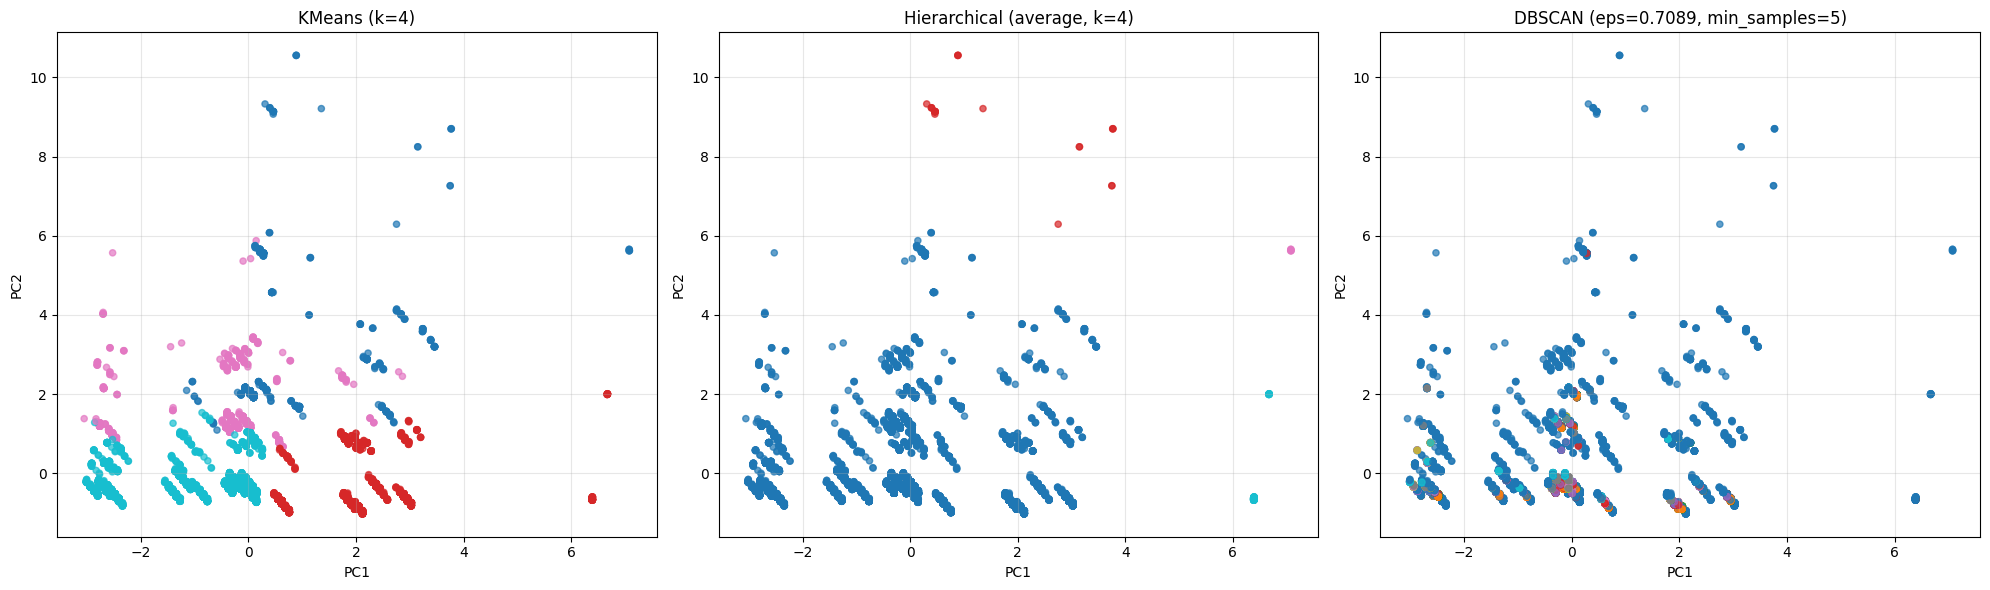


=== Профили кластеров KMeans (best) ===
                Quantity  UnitPrice  DiscountAmount  Channels  RetailPrice  OrderMonth  Size
Cluster_KMeans                                                                              
0                  1.167    190.769          21.199     4.230      228.248       3.754   570
1                  1.056    251.411           0.527     4.928      286.848       3.843  2759
2                  2.143    145.357           1.029     3.878      174.156       4.253   891
3                  1.000    130.680           0.465     3.685      157.896       4.024  5780

Все результаты сохранены в clustering_full_results.xlsx


In [23]:
# ============================================================
# 30. DBSCAN и сравнение KMeans / Hierarchical / DBSCAN
# ============================================================
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("\n" + "=" * 60)
print("30. DBSCAN и сравнение методов кластеризации")
print("=" * 60)

# --- 30.1. Оценка eps по k-дистанции (метод "knee") ---
# Идея: для каждой точки считаем расстояние до k-го ближайшего соседа,
# сортируем и ищем "колено" — оно подсказывает хорошее значение eps.
k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_clust_transformed)
distances, _ = nbrs.kneighbors(X_clust_transformed)

# Берём расстояние до k-го соседа (последний столбец)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_dist)
plt.xlabel('Точки, отсортированные по расстоянию')
plt.ylabel(f'Расстояние до {k_neighbors}-го соседа')
plt.title('k-distance graph для выбора eps в DBSCAN')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150)
plt.show()

# Автоматическая оценка "колена" — максимальное отклонение от прямой
def knee_point(y):
    x = np.arange(len(y))
    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    return int(x[np.argmax(num / den)])

knee_idx = knee_point(k_dist)
eps_auto = k_dist[knee_idx]
print(f"Автоматическая оценка eps (метод колена): {eps_auto:.4f}")


# --- 30.2. Перебор гиперпараметров DBSCAN ---
eps_grid = [eps_auto * 0.5, eps_auto * 0.75, eps_auto, eps_auto * 1.25, eps_auto * 1.5]
min_samples_grid = [3, 5, 10]

results_dbscan = []
for eps in eps_grid:
    for ms in min_samples_grid:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        labels_db = db.fit_predict(X_clust_transformed)

        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise    = np.sum(labels_db == -1)
        noise_pct  = n_noise / len(labels_db) * 100

        # Silhouette считается только если кластеров ≥ 2 и есть не шум
        if n_clusters >= 2:
            mask_valid = labels_db != -1
            sil = silhouette_score(X_clust_transformed[mask_valid], labels_db[mask_valid])
            db_score = davies_bouldin_score(X_clust_transformed[mask_valid], labels_db[mask_valid])
        else:
            sil, db_score = np.nan, np.nan

        results_dbscan.append({
            'eps'         : round(eps, 4),
            'min_samples' : ms,
            'n_clusters'  : n_clusters,
            'n_noise'     : n_noise,
            'noise_%'     : round(noise_pct, 2),
            'Silhouette'  : sil,
            'DaviesBouldin': db_score,
        })

df_dbscan = pd.DataFrame(results_dbscan).round(4)
print("\n=== Перебор гиперпараметров DBSCAN ===")
print(df_dbscan.sort_values('Silhouette', ascending=False).head(15))


# --- Лучшая конфигурация DBSCAN ---
df_dbscan_valid = df_dbscan.dropna(subset=['Silhouette'])
if len(df_dbscan_valid) > 0:
    best_db_row = df_dbscan_valid.sort_values('Silhouette', ascending=False).iloc[0]
    best_eps = best_db_row['eps']
    best_ms  = int(best_db_row['min_samples'])
    print(f"\nЛучшие параметры DBSCAN: eps={best_eps}, min_samples={best_ms}")

    dbscan_best = DBSCAN(eps=best_eps, min_samples=best_ms, n_jobs=-1)
    labels_dbscan_best = dbscan_best.fit_predict(X_clust_transformed)

    n_clusters_best = len(set(labels_dbscan_best)) - (1 if -1 in labels_dbscan_best else 0)
    n_noise_best    = np.sum(labels_dbscan_best == -1)
    print(f"Кластеров: {n_clusters_best}, шум: {n_noise_best} "
          f"({n_noise_best/len(labels_dbscan_best)*100:.1f}%)")
else:
    labels_dbscan_best = np.full(len(X_clust_transformed), -1)
    print("\nDBSCAN не нашёл устойчивой конфигурации с ≥2 кластерами.")


# --- 30.3. Итоговое сравнение методов ---
def cluster_metrics(labels, name):
    # Игнорируем шум (-1) для метрик
    mask = labels != -1
    if len(np.unique(labels[mask])) < 2:
        return {'Method': name, 'n_clusters': len(np.unique(labels[mask])),
                'noise_%': round((~mask).mean() * 100, 2),
                'Silhouette': np.nan, 'DaviesBouldin': np.nan,
                'CalinskiHarabasz': np.nan}
    return {
        'Method'          : name,
        'n_clusters'      : len(np.unique(labels[mask])),
        'noise_%'         : round((~mask).mean() * 100, 2),
        'Silhouette'      : silhouette_score(X_clust_transformed[mask], labels[mask]),
        'DaviesBouldin'   : davies_bouldin_score(X_clust_transformed[mask], labels[mask]),
        'CalinskiHarabasz': calinski_harabasz_score(X_clust_transformed[mask], labels[mask]),
    }

df_compare = pd.DataFrame([
    cluster_metrics(labels_kmeans_best, 'KMeans (best)'),
    cluster_metrics(labels_hier_best,   f'Hierarchical ({best_linkage})'),
    cluster_metrics(labels_dbscan_best, 'DBSCAN (best)'),
]).round(4)

print("\n=== Итоговое сравнение методов кластеризации ===")
print(df_compare)


# --- 30.4. Визуализация трёх методов на PCA-проекции ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# KMeans
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=labels_kmeans_best, cmap='tab10', s=20, alpha=0.7)
axes[0].set_title(f'KMeans (k={best_params_kmeans["n_clusters"]})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# Hierarchical
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=labels_hier_best, cmap='tab10', s=20, alpha=0.7)
axes[1].set_title(f'Hierarchical ({best_linkage}, k={k_hier})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.3)

# DBSCAN
unique_db = set(labels_dbscan_best)
cmap_db = plt.cm.get_cmap('tab10', max(len(unique_db), 2))
axes[2].scatter(X_pca[:, 0], X_pca[:, 1],
                c=labels_dbscan_best, cmap=cmap_db, s=20, alpha=0.7)
axes[2].set_title(f'DBSCAN (eps={best_eps}, min_samples={best_ms})')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_comparison_pca.png', dpi=150)
plt.show()


# --- 30.5. Профили кластеров для лучшей KMeans ---
X_clust['Cluster_KMeans']    = labels_kmeans_best
X_clust['Cluster_Hier']      = labels_hier_best
X_clust['Cluster_DBSCAN']    = labels_dbscan_best

profile_kmeans = (
    X_clust.groupby('Cluster_KMeans')[num_cols]
    .mean()
    .round(3)
)
profile_kmeans['Size'] = X_clust.groupby('Cluster_KMeans').size()

print("\n=== Профили кластеров KMeans (best) ===")
print(profile_kmeans)


# --- Сохранение всех результатов кластеризации ---
with pd.ExcelWriter('clustering_full_results.xlsx') as writer:
    df_kmeans_grid.to_excel(writer, sheet_name='kmeans_grid', index=False)
    df_hier.to_excel(writer, sheet_name='hierarchical', index=False)
    df_dbscan.to_excel(writer, sheet_name='dbscan_grid', index=False)
    df_compare.to_excel(writer, sheet_name='methods_comparison', index=False)
    profile_kmeans.to_excel(writer, sheet_name='kmeans_profiles')
    X_clust[['Cluster_KMeans', 'Cluster_Hier', 'Cluster_DBSCAN'] + features] \
        .to_excel(writer, sheet_name='cluster_labels', index=False)

print("\nВсе результаты сохранены в clustering_full_results.xlsx")


31. Сравнение кластеров с реальными метками

=== Сравнение кластеров с реальными метками ===
        True labels           Clustering     ARI     NMI  Homogeneity  Completeness  V_measure
0         ItemGroup        KMeans (best)  0.0032  0.0122       0.0276        0.0079     0.0122
1         ItemGroup  Hierarchical (best)  0.1317  0.1046       0.0635        0.2974     0.1046
2         ItemGroup        DBSCAN (best)  0.0003  0.0410       0.7352        0.0211     0.0410
3           KitType        KMeans (best)  0.0169  0.0290       0.0366        0.0240     0.0290
4           KitType  Hierarchical (best)  0.0041  0.0193       0.0106        0.1140     0.0193
5           KitType        DBSCAN (best)  0.0049  0.2014       1.0000        0.1120     0.2014
6       Demographic        KMeans (best)  0.3721  0.4195       0.4035        0.4368     0.4195
7       Demographic  Hierarchical (best)  0.0187  0.0759       0.0401        0.7143     0.0759
8       Demographic        DBSCAN (best)  0.0067  0

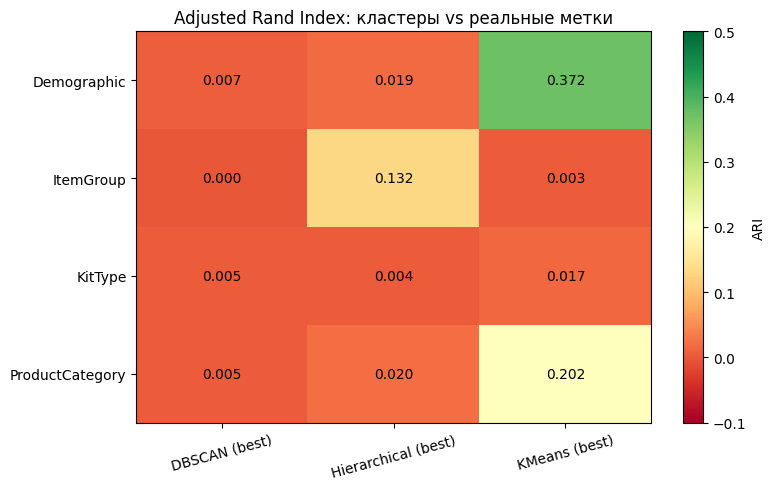


=== Confusion matrix: KMeans vs ItemGroup ===
KMeans cluster      0     1    2     3
ItemGroup (true)                      
Airplane          503  2416  884  5312
Helicopter         67   343    7   468


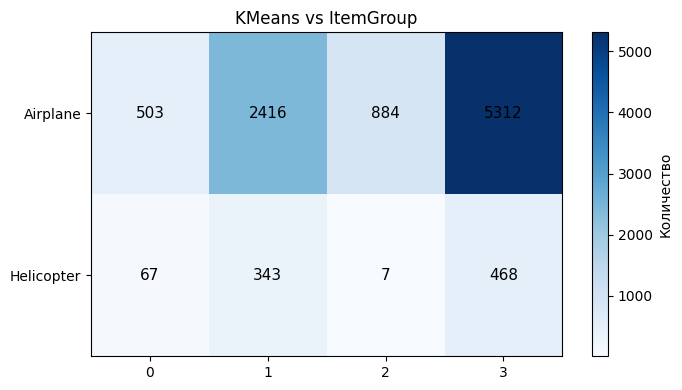


=== Confusion matrix: Hierarchical vs KitType ===
Hierarchical cluster     0   1  2   3
KitType (true)                       
KIT                   4455  22  5  72
RTF                   5444   2  0   0

=== Интерпретация ===
Лучшее совпадение: KMeans (best) vs Demographic (ARI=0.372, NMI=0.419)
ARI ≈ 0 — случайное совпадение, ARI → 1 — почти идеальное.


In [24]:
# ============================================================
# 31. Сравнение кластеров с реальными метками
# ============================================================
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    confusion_matrix
)

print("\n" + "=" * 60)
print("31. Сравнение кластеров с реальными метками")
print("=" * 60)

# Восстанавливаем реальные метки для тех же строк, что и в X_clust.
# X_clust построен из df_fact, поэтому берём метки из df_fact по той же маске.
mask_clust_full = df_fact[features].notna().all(axis=1)
df_clust_meta = df_fact.loc[mask_clust_full].reset_index(drop=True)

# Кандидаты на «реальные метки»
true_labels_options = {
    'ItemGroup'      : df_clust_meta['ItemGroup'].values,        # Airplane / Helicopter
    'KitType'        : df_clust_meta['KitType'].values,          # RTF / KIT
    'Demographic'    : df_clust_meta['Demographic'].values,      # Novice…Professional
    'ProductCategory': df_clust_meta['ProductCategory'].values,  # Glider / Trainer / …
}

# Метки кластеров, полученные ранее
clusterings = {
    'KMeans (best)'          : labels_kmeans_best,
    'Hierarchical (best)'    : labels_hier_best,
    'DBSCAN (best)'          : labels_dbscan_best,
}


def clustering_vs_truth(y_true, y_pred, ignore_noise=True):
    """Сравнивает кластеры с реальными метками. Шум DBSCAN (-1) можно исключать."""
    if ignore_noise:
        mask = y_pred != -1
        y_true, y_pred = y_true[mask], y_pred[mask]
    if len(np.unique(y_pred)) < 2:
        return dict(ARI=np.nan, NMI=np.nan, Homogeneity=np.nan,
                    Completeness=np.nan, V_measure=np.nan)
    return {
        'ARI'         : adjusted_rand_score(y_true, y_pred),
        'NMI'         : normalized_mutual_info_score(y_true, y_pred),
        'Homogeneity' : homogeneity_score(y_true, y_pred),
        'Completeness': completeness_score(y_true, y_pred),
        'V_measure'   : v_measure_score(y_true, y_pred),
    }


# --- Сводная таблица по всем комбинациям ---
rows = []
for truth_name, truth_labels in true_labels_options.items():
    for cl_name, cl_labels in clusterings.items():
        metrics = clustering_vs_truth(
            np.array(truth_labels), np.array(cl_labels)
        )
        rows.append({
            'True labels' : truth_name,
            'Clustering'  : cl_name,
            **metrics
        })

df_truth_compare = pd.DataFrame(rows).round(4)
print("\n=== Сравнение кластеров с реальными метками ===")
print(df_truth_compare)


# --- Тепловая карта ARI (Adjusted Rand Index) ---
pivot_ari = df_truth_compare.pivot(
    index='True labels', columns='Clustering', values='ARI'
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot_ari.values, cmap='RdYlGn', vmin=-0.1, vmax=0.5, aspect='auto')
ax.set_xticks(np.arange(pivot_ari.shape[1]))
ax.set_xticklabels(pivot_ari.columns, rotation=15)
ax.set_yticks(np.arange(pivot_ari.shape[0]))
ax.set_yticklabels(pivot_ari.index)
for i in range(pivot_ari.shape[0]):
    for j in range(pivot_ari.shape[1]):
        val = pivot_ari.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha='center', va='center',
                    color='black', fontsize=10)
plt.colorbar(im, ax=ax, label='ARI')
ax.set_title('Adjusted Rand Index: кластеры vs реальные метки')
plt.tight_layout()
plt.savefig('clusters_vs_truth_ari.png', dpi=150)
plt.show()


# --- Confusion matrix: KMeans vs ItemGroup ---
truth_item = true_labels_options['ItemGroup']
labels_km  = clusterings['KMeans (best)']

cm = pd.crosstab(
    pd.Series(truth_item, name='ItemGroup (true)'),
    pd.Series(labels_km, name='KMeans cluster')
)
print("\n=== Confusion matrix: KMeans vs ItemGroup ===")
print(cm)

# Тепловая карта confusion matrix
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(cm.values, cmap='Blues', aspect='auto')
ax.set_xticks(np.arange(cm.shape[1]))
ax.set_xticklabels(cm.columns)
ax.set_yticks(np.arange(cm.shape[0]))
ax.set_yticklabels(cm.index)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm.values[i, j], ha='center', va='center',
                color='black', fontsize=11)
plt.colorbar(im, ax=ax, label='Количество')
ax.set_title('KMeans vs ItemGroup')
plt.tight_layout()
plt.savefig('confusion_kmeans_itemgroup.png', dpi=150)
plt.show()


# --- Confusion matrix: Hierarchical vs KitType ---
truth_kit  = true_labels_options['KitType']
labels_h   = clusterings['Hierarchical (best)']

cm2 = pd.crosstab(
    pd.Series(truth_kit, name='KitType (true)'),
    pd.Series(labels_h, name='Hierarchical cluster')
)
print("\n=== Confusion matrix: Hierarchical vs KitType ===")
print(cm2)


# --- Выводы ---
print("\n=== Интерпретация ===")
best_row = df_truth_compare.sort_values('ARI', ascending=False).iloc[0]
print(f"Лучшее совпадение: {best_row['Clustering']} vs {best_row['True labels']} "
      f"(ARI={best_row['ARI']:.3f}, NMI={best_row['NMI']:.3f})")
print("ARI ≈ 0 — случайное совпадение, ARI → 1 — почти идеальное.")

# NEW

ФИНАЛЬНЫЙ ПАЙПЛАЙН: аналитика + ML + кластеризация

Product: (20, 9)
Region : (6, 2)
Sales  : (10000, 9)
State  : (51, 4)

fact_sales: (10000, 29)

Датасеты сохранены в analytics_datasets.xlsx

Распределение IsHelicopter:
IsHelicopter
0    9115
1     885
Name: count, dtype: int64

Итоговый размер выборки: (10000, 11)

=== LogisticRegression ===
              precision    recall  f1-score   support

           0     0.9978    0.8479    0.9168      2735
           1     0.3846    0.9811    0.5526       265

    accuracy                         0.8597      3000
   macro avg     0.6912    0.9145    0.7347      3000
weighted avg     0.9437    0.8597    0.8846      3000


=== RandomForest ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      2735
           1     1.0000    1.0000    1.0000       265

    accuracy                         1.0000      3000
   macro avg     1.0000    1.0000    1.0000      3000
weighted avg     1.0000    1.000

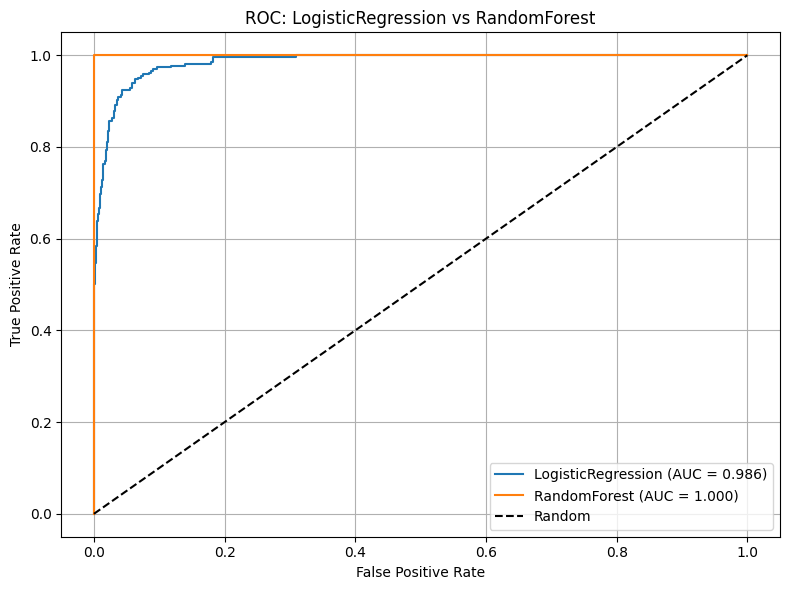


=== Метрики vs n_estimators ===
   n_estimators  Accuracy   F1  ROC_AUC
0            10       1.0  1.0      1.0
1            50       1.0  1.0      1.0
2           100       1.0  1.0      1.0
3           200       1.0  1.0      1.0
4           300       1.0  1.0      1.0
5           500       1.0  1.0      1.0


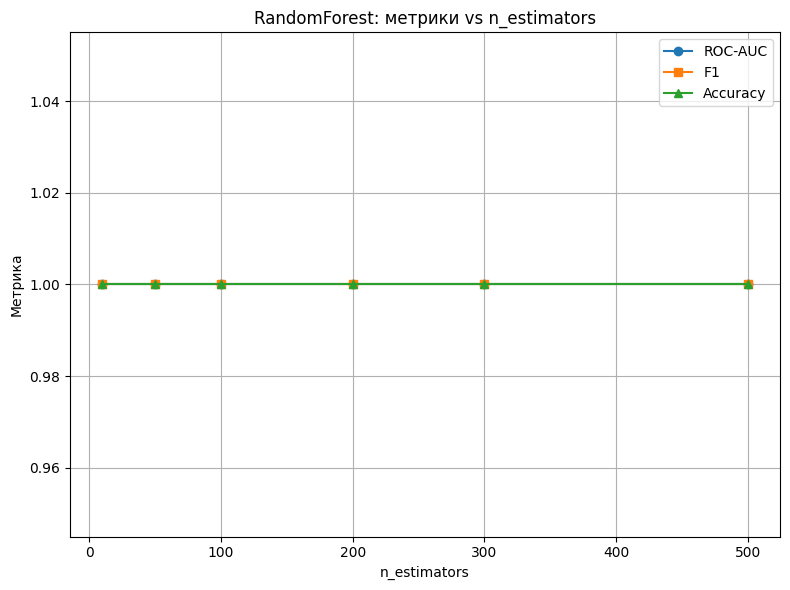


=== Кросс-валидация (ROC-AUC, 5 фолдов) ===
LogisticRegression: 0.9904 ± 0.0023
RandomForest      : 1.0000 ± 0.0000

=== Builtin vs SHAP ===
                     Feature  BuiltinImportance  MeanAbsSHAP  BuiltinNorm  SHAPNorm  RankBuiltin  RankSHAP  RankDiff
0                RetailPrice             0.3672       0.2060       0.3672    0.3568          1.0       1.0       0.0
1                  UnitPrice             0.3381       0.1894       0.3381    0.3281          2.0       2.0       0.0
2       Demographic_Advanced             0.0557       0.0442       0.0557    0.0766          3.0       3.0       0.0
3                KitType_RTF             0.0354       0.0209       0.0354    0.0362          5.0       4.0       1.0
4                   Channels             0.0400       0.0187       0.0400    0.0324          4.0       5.0      -1.0
5         Demographic_Novice             0.0334       0.0182       0.0334    0.0316          6.0       6.0       0.0
6       Demographic_Beginner           

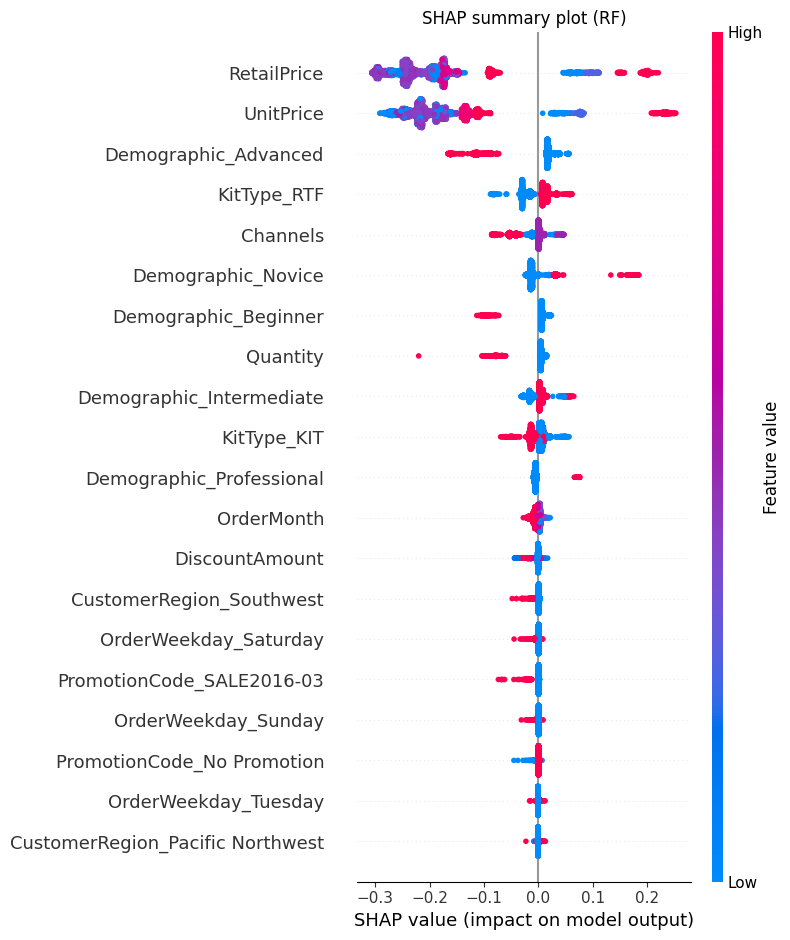

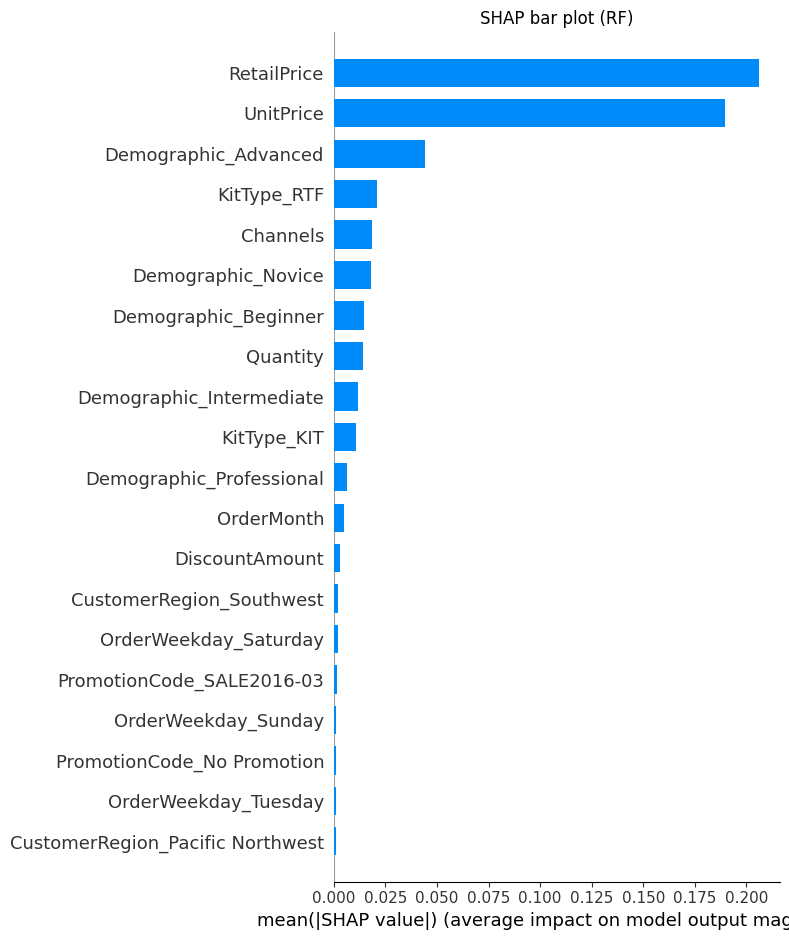

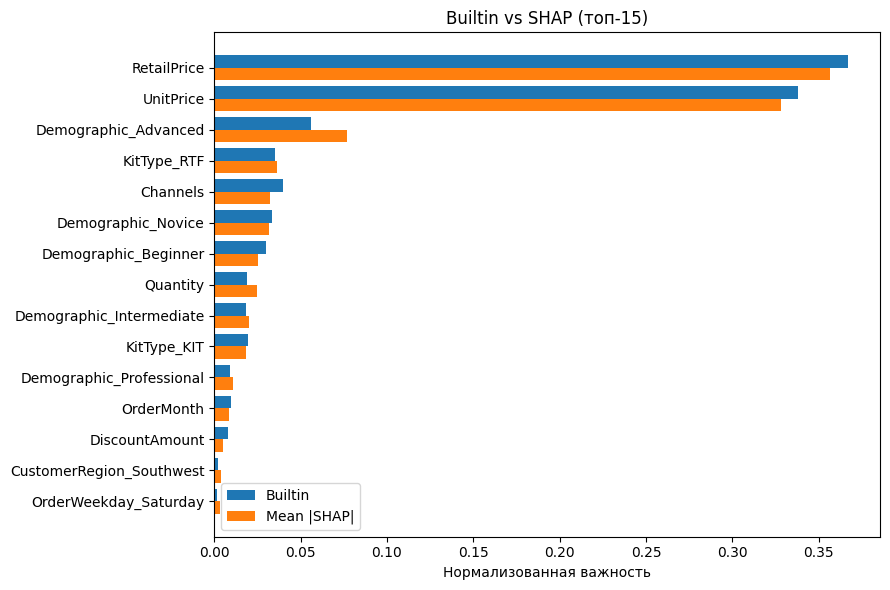


Вариант A (SHAP >= 1%): ['RetailPrice', 'UnitPrice', 'Demographic', 'KitType', 'Channels', 'Quantity']
Вариант B (Top-10 SHAP): ['RetailPrice', 'UnitPrice', 'Demographic', 'KitType', 'Channels', 'Quantity']
Вариант C (Top-10 Builtin): ['RetailPrice', 'UnitPrice', 'Demographic', 'Channels', 'KitType', 'Quantity']

=== После отбора признаков ===
            Model  N_features  Accuracy  Precision  Recall   F1  ROC_AUC
0    All features          11       1.0        1.0     1.0  1.0      1.0
1      SHAP >= 1%           6       1.0        1.0     1.0  1.0      1.0
2     Top-10 SHAP           6       1.0        1.0     1.0  1.0      1.0
3  Top-10 Builtin           6       1.0        1.0     1.0  1.0      1.0

=== CV (ROC-AUC) ===
            Model  N_features  CV_AUC_mean  CV_AUC_std
0    All features          11          1.0         0.0
1      SHAP >= 1%           6          1.0         0.0
2     Top-10 SHAP           6          1.0         0.0
3  Top-10 Builtin           6          1.0    

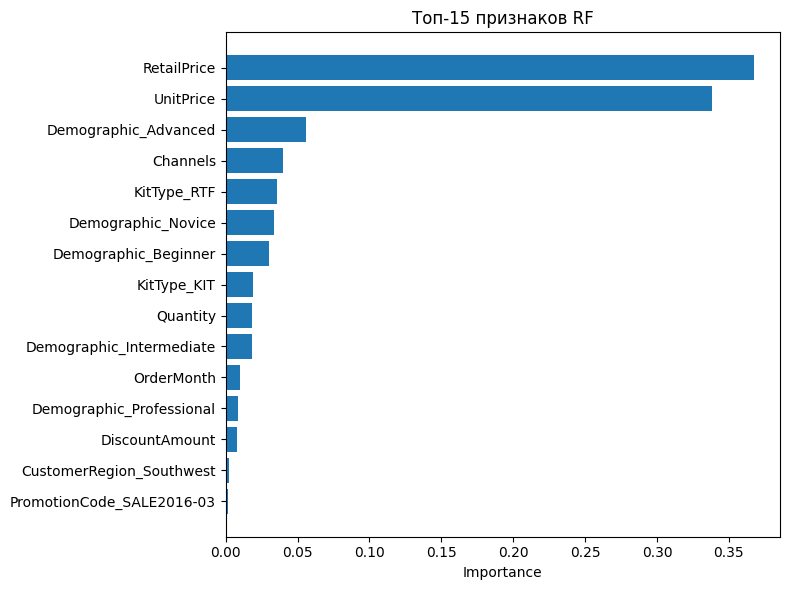


21. predict_proba и ROC/PR-AUC по классам

=== ROC-AUC / PR-AUC по классам ===
                Model  ROC_AUC class1  ROC_AUC class0  PR_AUC class1  PR_AUC class0
0  LogisticRegression          0.9856          0.9856          0.899         0.9986
1        RandomForest          1.0000          1.0000          1.000         1.0000

22. SHAP-визуализации


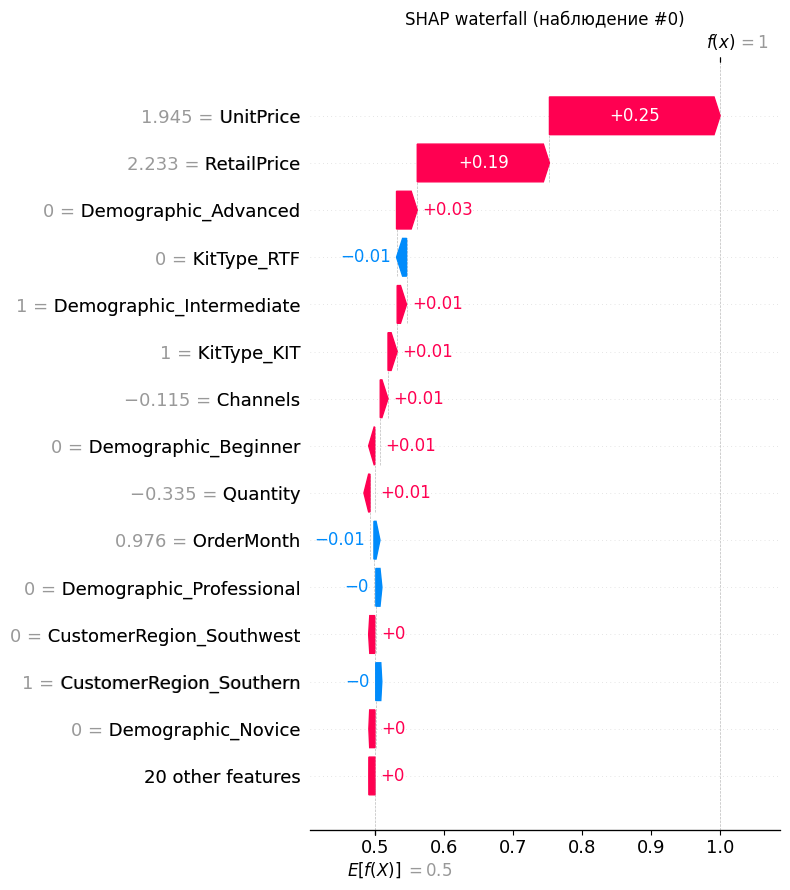

<Figure size 640x480 with 0 Axes>

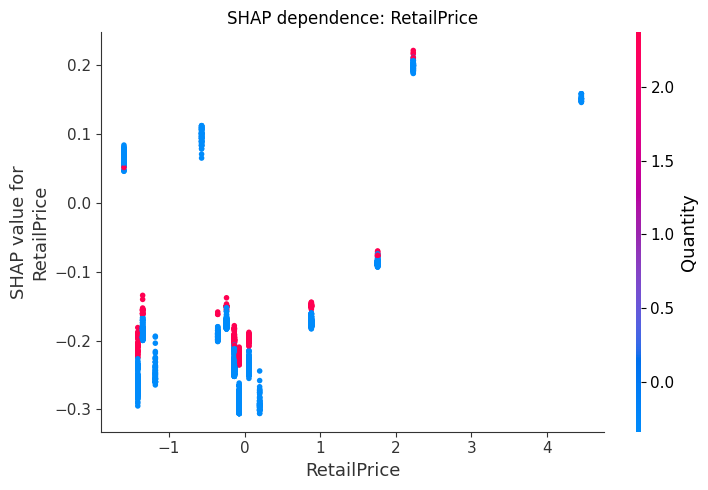

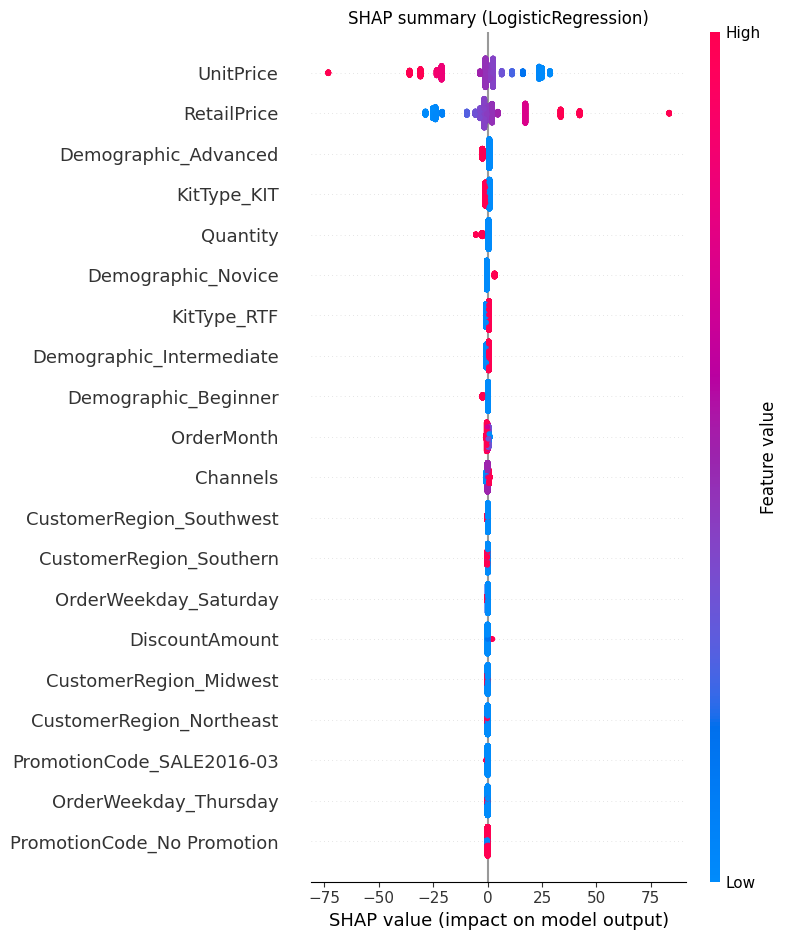


23. Оптимизация гиперпараметров

Best RF params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best RF CV AUC: 1.0000

Best LR params: {'clf__solver': 'saga', 'clf__max_iter': 2000, 'clf__C': 100}
Best LR CV AUC: 1.0000

=== Baseline vs Optimized ===
          Model  ROC_AUC
0   LR baseline   0.9856
1   RF baseline   1.0000
2  LR optimized   1.0000
3  RF optimized   1.0000

24. Подготовка к кластеризации
Матрица признаков: (10000, 34)

=== Метрики кластеризации ===
    k     Inertia  Silhouette  DaviesBouldin
0   2  70525.4127      0.2377         1.6538
1   3  60717.6890      0.2229         1.7266
2   4  53827.5568      0.2351         1.5610
3   5  49257.8305      0.2301         1.5156
4   6  43469.9753      0.2437         1.4032
5   7  40550.9678      0.1975         1.4963
6   8  38575.1024      0.1919         1.5740
7   9  37052.6826      0.1860         1.5946
8  10  35414.4056      0.1902    

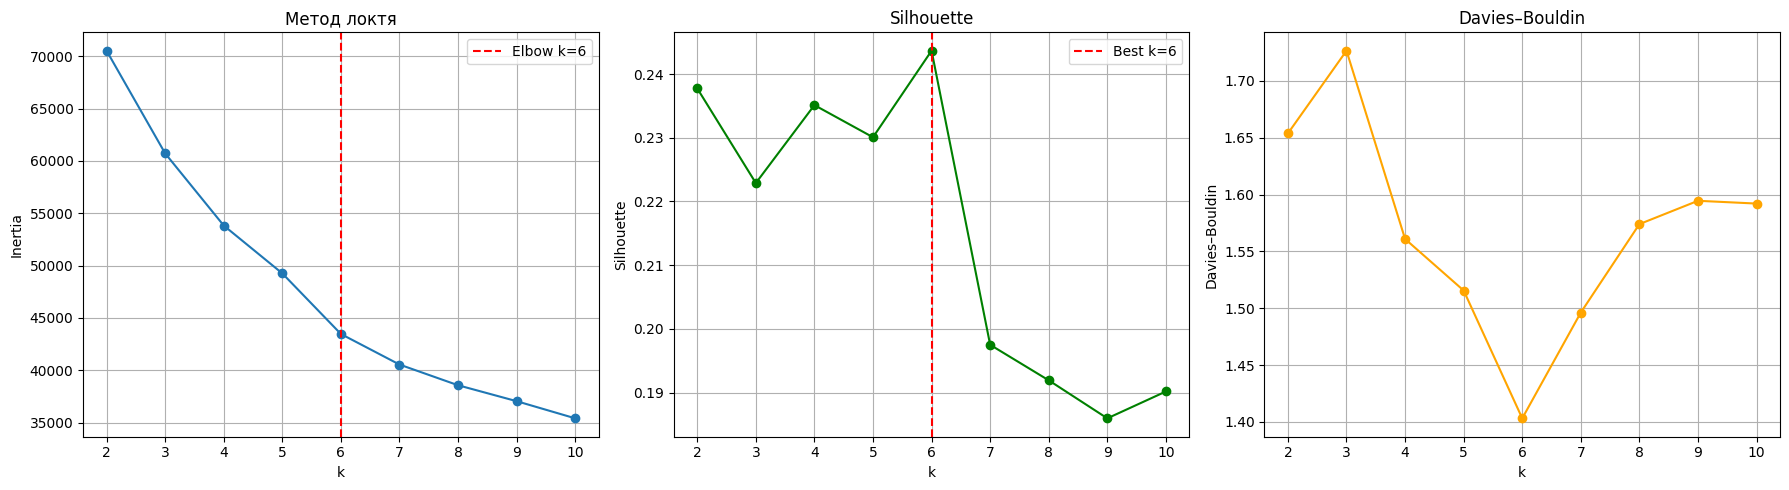


=== Топ-10 KMeans по Silhouette ===
   n_clusters       init  n_init  max_iter     Inertia  Silhouette  DaviesBouldin  CalinskiHarabasz
0           4     random      10       500  56028.4032      0.2515         1.4036         2007.4283
1           4     random      10       300  56028.4032      0.2515         1.4036         2007.4283
2           5  k-means++      20       500  47539.1052      0.2492         1.4053         2220.4656
3           5  k-means++      20       300  47539.1052      0.2492         1.4053         2220.4656
4           6  k-means++      20       500  43469.9753      0.2437         1.4032         2129.5638
5           6  k-means++      20       300  43469.9753      0.2437         1.4032         2129.5638
6           6     random      20       300  43469.9753      0.2437         1.4032         2129.5638
7           6     random      20       500  43469.9753      0.2437         1.4032         2129.5638
8           6  k-means++      10       300  43469.9753      0.2

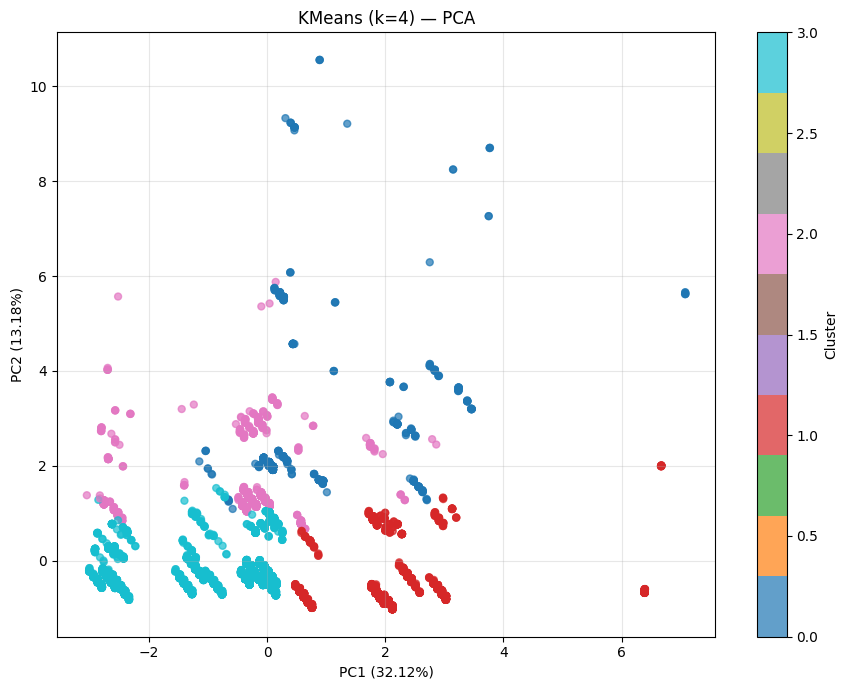

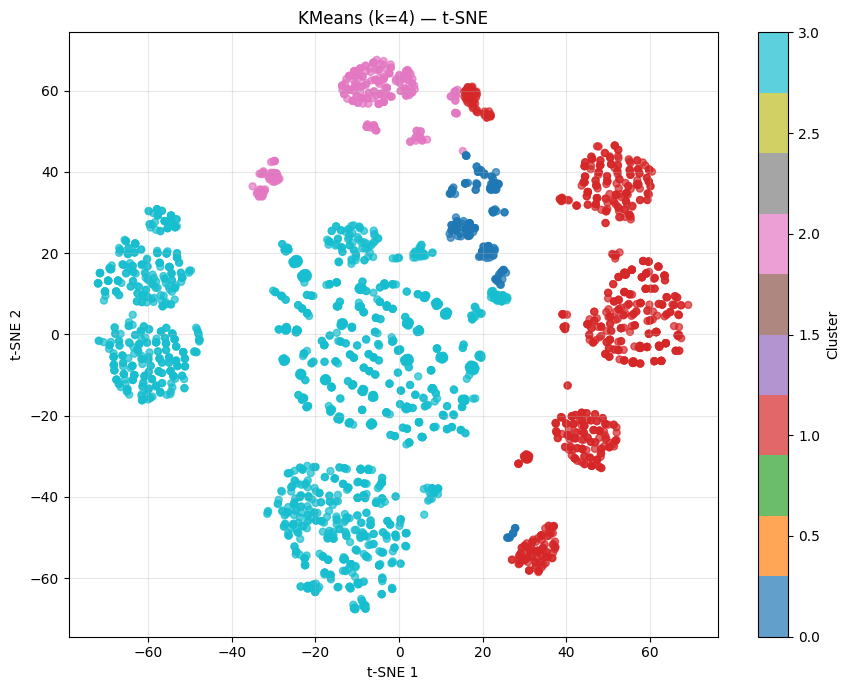

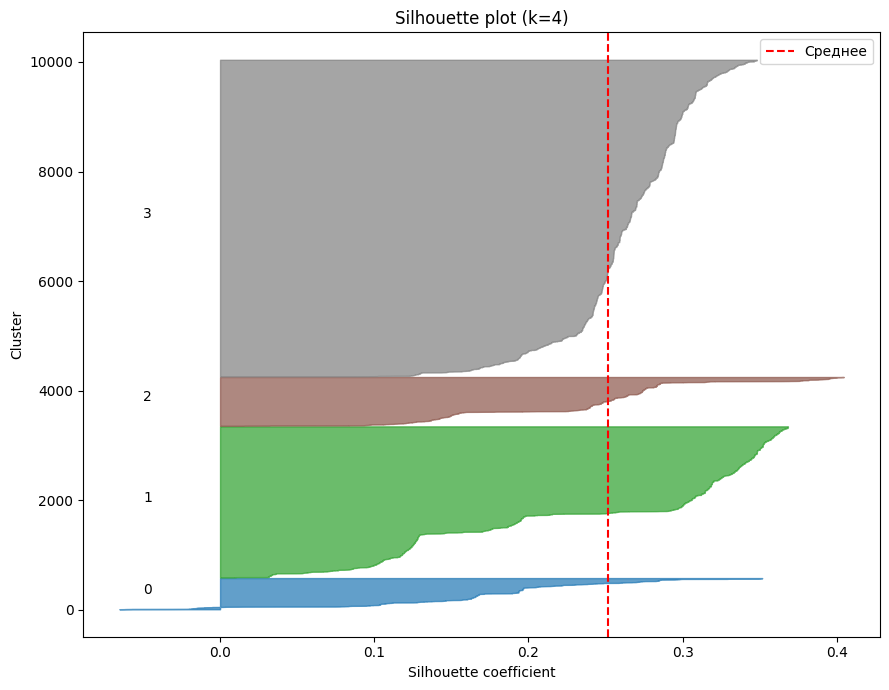


=== Профили кластеров KMeans ===
                Quantity  UnitPrice  DiscountAmount  Channels  RetailPrice  OrderMonth  Size
Cluster_KMeans                                                                              
0                  1.167    190.769          21.199     4.230      228.248       3.754   570
1                  1.056    251.411           0.527     4.928      286.848       3.843  2759
2                  2.143    145.357           1.029     3.878      174.156       4.253   891
3                  1.000    130.680           0.465     3.685      157.896       4.024  5780

28. Сравнение кластеров с реальными метками

=== Согласие KMeans с реальными метками ===
       True labels     Clustering     ARI     NMI  Homogeneity  Completeness  V_measure
0        ItemGroup  KMeans (best)  0.0032  0.0122       0.0276        0.0079     0.0122
1          KitType  KMeans (best)  0.0169  0.0290       0.0366        0.0240     0.0290
2      Demographic  KMeans (best)  0.3721  0.4195     

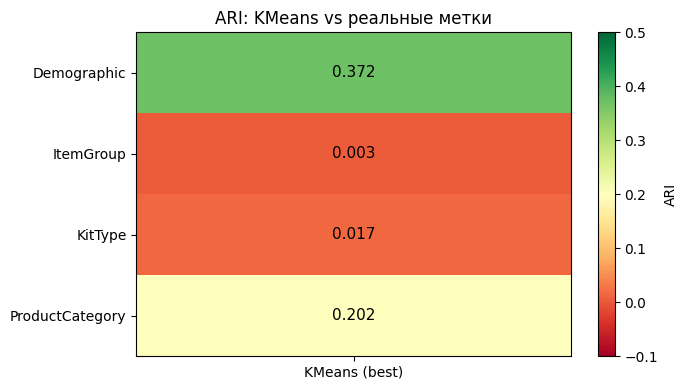


=== Confusion matrix: KMeans vs ItemGroup ===
KMeans cluster      0     1    2     3
ItemGroup (true)                      
Airplane          503  2416  884  5312
Helicopter         67   343    7   468

29. AgglomerativeClustering и DBSCAN

=== AgglomerativeClustering ===
                  Algorithm  n_clusters  Silhouette  DaviesBouldin  CalinskiHarabasz
2   Agglomerative (average)           4      0.4566         0.6352          245.4078
3    Agglomerative (single)           4      0.4545         0.4873          168.3250
0      Agglomerative (ward)           4      0.2187         1.6428         2042.1134
1  Agglomerative (complete)           4      0.2117         1.1904          741.9334


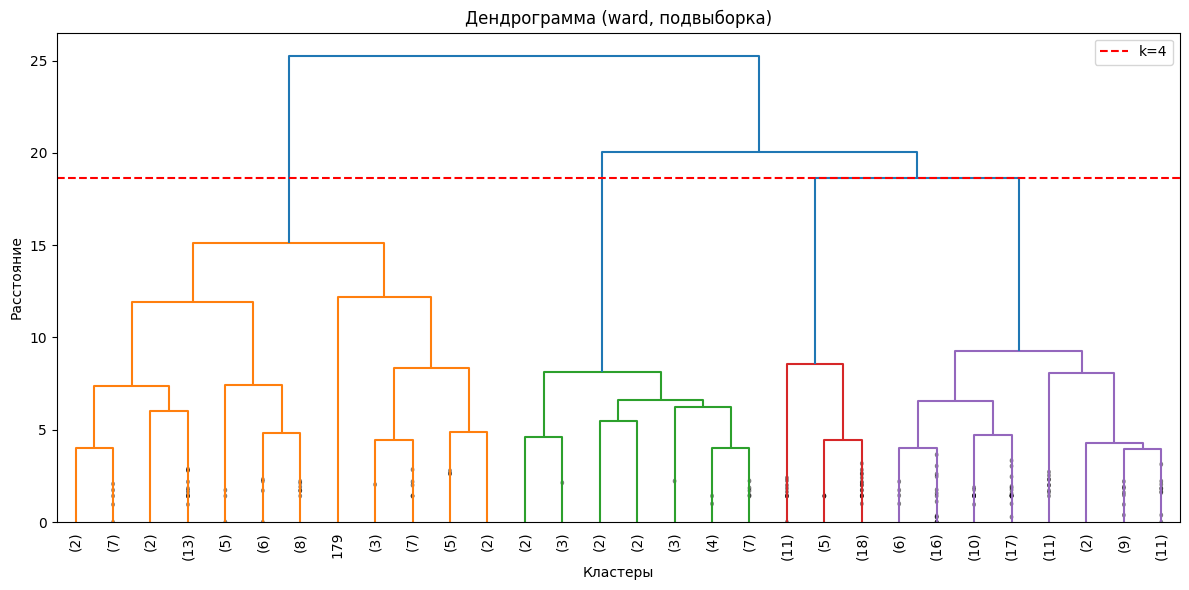

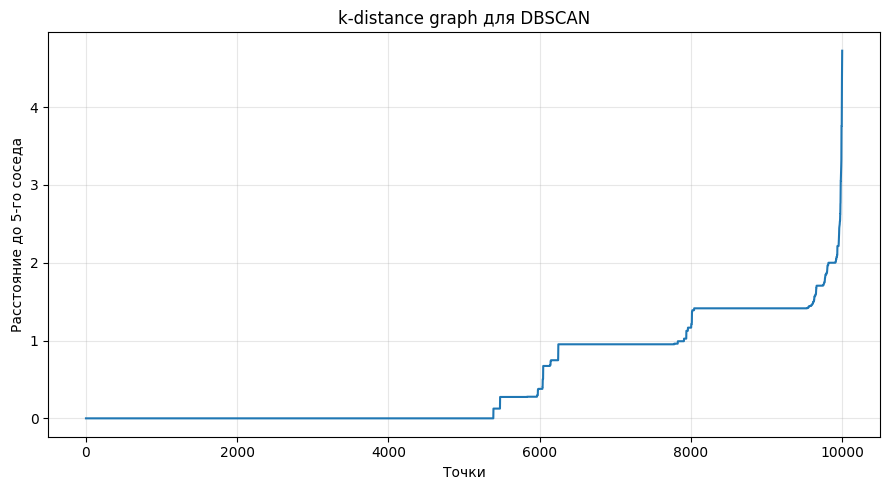


Автооценка eps: 1.4178

=== DBSCAN сетка ===
       eps  min_samples  n_clusters  n_noise  noise_%  Silhouette  DaviesBouldin
1   0.7089            5         594     3857    38.57      0.9265         0.1783
0   0.7089            3        1099     2143    21.43      0.9256         0.1828
2   0.7089           10         205     6344    63.44      0.9191         0.1810
3   1.0634            3         613     1078    10.78      0.4268         0.9026
5   1.0634           10         251     3042    30.42      0.4178         1.0847
4   1.0634            5         413     1791    17.91      0.4151         1.0374
11  1.7723           10          21      326     3.26      0.2142         1.1053
10  1.7723            5          37      138     1.38      0.2089         1.1037
9   1.7723            3          52       42     0.42      0.1747         1.0386
8   1.4178           10          38      605     6.05      0.1483         1.3797

30. Итоговое сравнение

=== Сравнение алгоритмов ===
         

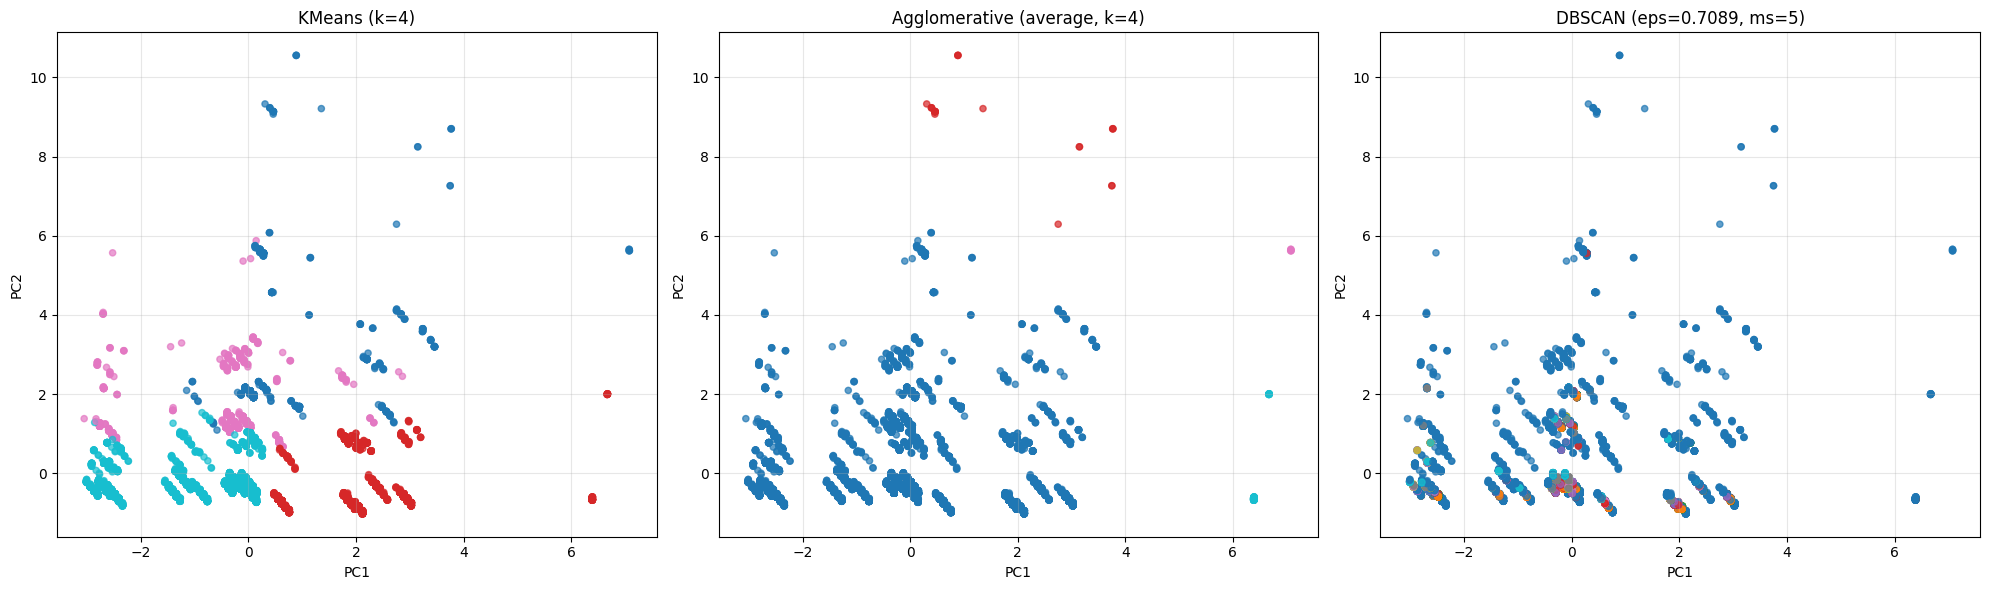


ГОТОВО. Все результаты сохранены в final_report.xlsx
Графики: roc_curves.png, n_estimators_metrics.png,
  shap_summary.png, shap_bar.png, importance_comparison.png,
  feature_importance.png, shap_waterfall.png, shap_dependence.png,
  shap_summary_lr.png, cluster_optimal_k.png, clusters_pca.png,
  clusters_tsne.png, clusters_silhouette_plot.png,
  kmeans_vs_truth_ari.png, dendrogram.png, dbscan_kdistance.png,
  algorithms_pca_comparison.png


In [26]:
# ============================================================
# ФИНАЛЬНЫЙ СКРИПТ: аналитика, ML и кластеризация
# ============================================================
# Структура:
#   0.  Импорт
#   1.  Чтение Excel
#   2.  Очистка и типы
#   3.  Производные поля
#   4.  fact_sales
#   5.  dim_date
#   6.  Аналитические витрины
#   7.  Сохранение датасетов
#   8.  Таргет
#   9.  Признаки
#   10. Train/Test
#   11. LogisticRegression
#   12. RandomForest
#   13. Метрики
#   14. ROC
#   15. n_estimators
#   16. Кросс-валидация
#   17. SHAP (RF)
#   18. Отбор признаков
#   19. CV отобранных наборов
#   20. Топ-15 признаков RF
#   21. predict_proba и ROC/PR-AUC по классам
#   22. SHAP-визуализации
#   23. Оптимизация гиперпараметров
#   24. Подготовка к кластеризации
#   25. Elbow + Silhouette + DB index
#   26. Финальный KMeans
#   27. Визуализация кластеров (PCA, t-SNE, silhouette plot)
#   28. Сравнение кластеров с реальными метками
#   29. Agglomerative + DBSCAN
#   30. Итоговое сравнение алгоритмов
# ============================================================

# ============================================================
# 0. Импорт
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score,
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
from itertools import product

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("=" * 60)
print("ФИНАЛЬНЫЙ ПАЙПЛАЙН: аналитика + ML + кластеризация")
print("=" * 60)


# ============================================================
# 1. Чтение Excel
# ============================================================
file_path = '40_10.xlsx'

df_product = pd.read_excel(file_path, sheet_name='Product')
df_region  = pd.read_excel(file_path, sheet_name='Region')
df_sales   = pd.read_excel(file_path, sheet_name='Sales')
df_state   = pd.read_excel(file_path, sheet_name='State')

print(f"\nProduct: {df_product.shape}")
print(f"Region : {df_region.shape}")
print(f"Sales  : {df_sales.shape}")
print(f"State  : {df_state.shape}")


# ============================================================
# 2. Очистка и типы
# ============================================================
df_sales['OrderDate'] = pd.to_datetime(df_sales['OrderDate'])
df_sales['ShipDate']  = pd.to_datetime(df_sales['ShipDate'])
df_sales['PromotionCode']  = df_sales['PromotionCode'].fillna('No Promotion')
df_sales['Quantity']       = pd.to_numeric(df_sales['Quantity'], errors='coerce')
df_sales['UnitPrice']      = pd.to_numeric(df_sales['UnitPrice'], errors='coerce')
df_sales['DiscountAmount'] = pd.to_numeric(df_sales['DiscountAmount'], errors='coerce')

df_product['RetailPrice'] = pd.to_numeric(df_product['RetailPrice'], errors='coerce')
df_product['Channels']    = pd.to_numeric(df_product['Channels'], errors='coerce')

df_state['RegionID'] = pd.to_numeric(df_state['RegionID'], errors='coerce')


# ============================================================
# 3. Производные поля
# ============================================================
df_sales['GrossRevenue'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales['NetRevenue']   = df_sales['GrossRevenue'] - df_sales['DiscountAmount']
df_sales['OrderYear']    = df_sales['OrderDate'].dt.year
df_sales['OrderMonth']   = df_sales['OrderDate'].dt.month
df_sales['OrderQuarter'] = df_sales['OrderDate'].dt.quarter
df_sales['OrderWeekday'] = df_sales['OrderDate'].dt.day_name()
df_sales['ShipDays']     = (df_sales['ShipDate'] - df_sales['OrderDate']).dt.days


# ============================================================
# 4. fact_sales
# ============================================================
df_geo = df_state.merge(df_region, on='RegionID', how='left')

df_fact = (
    df_sales
    .merge(df_product, on='ProductID', how='left')
    .merge(df_geo, left_on='CustomerStateID', right_on='StateID', how='left')
)
df_fact = df_fact.rename(columns={
    'StateName': 'CustomerState',
    'RegionName': 'CustomerRegion'
})

print(f"\nfact_sales: {df_fact.shape}")


# ============================================================
# 5. dim_date
# ============================================================
min_date = df_sales['OrderDate'].min()
max_date = df_sales['OrderDate'].max()

df_date = pd.DataFrame({'Date': pd.date_range(min_date, max_date, freq='D')})
df_date['Year']      = df_date['Date'].dt.year
df_date['Quarter']   = df_date['Date'].dt.quarter
df_date['Month']     = df_date['Date'].dt.month
df_date['MonthName'] = df_date['Date'].dt.month_name()
df_date['Week']      = df_date['Date'].dt.isocalendar().week
df_date['Weekday']   = df_date['Date'].dt.day_name()
df_date['IsWeekend'] = df_date['Date'].dt.weekday >= 5


# ============================================================
# 6. Аналитические витрины
# ============================================================
sales_by_product = (
    df_fact
    .groupby(['ProductID', 'ProductName', 'ProductCategory',
              'ItemGroup', 'KitType', 'Demographic'])
    .agg(Orders=('OrderNumber', 'nunique'), Units=('Quantity', 'sum'),
         GrossRevenue=('GrossRevenue', 'sum'), NetRevenue=('NetRevenue', 'sum'),
         Discount=('DiscountAmount', 'sum'))
    .reset_index()
)

sales_by_region = (
    df_fact.groupby(['CustomerRegion'])
    .agg(Orders=('OrderNumber', 'nunique'), Units=('Quantity', 'sum'),
         GrossRevenue=('GrossRevenue', 'sum'), NetRevenue=('NetRevenue', 'sum'),
         Discount=('DiscountAmount', 'sum'))
    .reset_index()
)

sales_by_state = (
    df_fact.groupby(['StateCode', 'CustomerState', 'CustomerRegion'])
    .agg(Orders=('OrderNumber', 'nunique'), Units=('Quantity', 'sum'),
         NetRevenue=('NetRevenue', 'sum'))
    .reset_index()
)

sales_by_month = (
    df_fact.groupby(df_fact['OrderDate'].dt.to_period('M'))
    .agg(Orders=('OrderNumber', 'nunique'), Units=('Quantity', 'sum'),
         GrossRevenue=('GrossRevenue', 'sum'), NetRevenue=('NetRevenue', 'sum'),
         Discount=('DiscountAmount', 'sum'))
    .reset_index().rename(columns={'OrderDate': 'Month'})
)

sales_by_promo = (
    df_fact.groupby(['PromotionCode'])
    .agg(Orders=('OrderNumber', 'nunique'), Units=('Quantity', 'sum'),
         NetRevenue=('NetRevenue', 'sum'), Discount=('DiscountAmount', 'sum'))
    .reset_index()
)

price_analysis = (
    df_fact.groupby(['ProductID', 'ProductName'])
    .agg(AvgUnitPrice=('UnitPrice', 'mean'), RetailPrice=('RetailPrice', 'first'),
         AvgDiscount=('DiscountAmount', 'mean'), Units=('Quantity', 'sum'))
    .reset_index()
)
price_analysis['PriceDiff']    = price_analysis['AvgUnitPrice'] - price_analysis['RetailPrice']
price_analysis['PriceDiffPct'] = price_analysis['PriceDiff'] / price_analysis['RetailPrice'] * 100


# ============================================================
# 7. Сохранение датасетов
# ============================================================
with pd.ExcelWriter('analytics_datasets.xlsx') as writer:
    df_product.to_excel(writer, sheet_name='dim_product', index=False)
    df_region.to_excel(writer, sheet_name='dim_region', index=False)
    df_state.to_excel(writer, sheet_name='dim_state', index=False)
    df_date.to_excel(writer, sheet_name='dim_date', index=False)
    df_fact.to_excel(writer, sheet_name='fact_sales', index=False)
    sales_by_product.to_excel(writer, sheet_name='sales_by_product', index=False)
    sales_by_region.to_excel(writer, sheet_name='sales_by_region', index=False)
    sales_by_state.to_excel(writer, sheet_name='sales_by_state', index=False)
    sales_by_month.to_excel(writer, sheet_name='sales_by_month', index=False)
    sales_by_promo.to_excel(writer, sheet_name='sales_by_promo', index=False)
    price_analysis.to_excel(writer, sheet_name='price_analysis', index=False)

print("\nДатасеты сохранены в analytics_datasets.xlsx")


# ============================================================
# 8. Таргет
# ============================================================
df_fact['IsHelicopter'] = (df_fact['ItemGroup'] == 'Helicopter').astype(int)
print("\nРаспределение IsHelicopter:")
print(df_fact['IsHelicopter'].value_counts())


# ============================================================
# 9. Признаки
# ============================================================
num_cols = ['Quantity', 'UnitPrice', 'DiscountAmount', 'Channels',
            'RetailPrice', 'OrderMonth']
cat_cols = ['KitType', 'Demographic', 'CustomerRegion',
            'OrderWeekday', 'PromotionCode']
features = num_cols + cat_cols

X = df_fact[features].copy()
y = df_fact['IsHelicopter']
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

print(f"\nИтоговый размер выборки: {X.shape}")


# ============================================================
# 10. Train/Test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


# ============================================================
# 11. LogisticRegression
# ============================================================
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=RANDOM_STATE))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr  = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

print("\n=== LogisticRegression ===")
print(classification_report(y_test, y_pred_lr, digits=4))


# ============================================================
# 12. RandomForest
# ============================================================
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf  = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("\n=== RandomForest ===")
print(classification_report(y_test, y_pred_rf, digits=4))


# ============================================================
# 13. Метрики
# ============================================================
def get_metrics(y_true, y_pred, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return {'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1': f1_score(y_true, y_pred, zero_division=0),
            'ROC_AUC': auc(fpr, tpr)}

df_metrics = pd.DataFrame({
    'LogisticRegression': get_metrics(y_test, y_pred_lr, y_proba_lr),
    'RandomForest':       get_metrics(y_test, y_pred_rf, y_proba_rf)
}).T.round(4)
print("\n=== Сравнение моделей ===")
print(df_metrics)


# ============================================================
# 14. ROC
# ============================================================
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC: LogisticRegression vs RandomForest')
plt.legend(loc='lower right'); plt.grid(True); plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150); plt.show()


# ============================================================
# 15. n_estimators
# ============================================================
n_estimators_list = [10, 50, 100, 200, 300, 500]
results = []
for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1)
    pipe = Pipeline([('prep', preprocessor), ('clf', rf)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    results.append({'n_estimators': n,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'F1': f1_score(y_test, y_pred, zero_division=0),
                    'ROC_AUC': auc(fpr, tpr)})

df_results = pd.DataFrame(results).round(4)
print("\n=== Метрики vs n_estimators ===")
print(df_results)

plt.figure(figsize=(8, 6))
plt.plot(df_results['n_estimators'], df_results['ROC_AUC'], marker='o', label='ROC-AUC')
plt.plot(df_results['n_estimators'], df_results['F1'],      marker='s', label='F1')
plt.plot(df_results['n_estimators'], df_results['Accuracy'],marker='^', label='Accuracy')
plt.xlabel('n_estimators'); plt.ylabel('Метрика')
plt.title('RandomForest: метрики vs n_estimators')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('n_estimators_metrics.png', dpi=150); plt.show()


# ============================================================
# 16. Кросс-валидация
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_lr = cross_val_score(lr_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_rf = cross_val_score(rf_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("\n=== Кросс-валидация (ROC-AUC, 5 фолдов) ===")
print(f"LogisticRegression: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"RandomForest      : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")


# ============================================================
# 17. SHAP для RandomForest
# ============================================================
X_test_transformed = rf_pipe.named_steps['prep'].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
X_test_transformed = np.asarray(X_test_transformed, dtype=np.float64)

ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

rf_model = rf_pipe.named_steps['clf']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed, check_additivity=False)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

builtin_importance = rf_model.feature_importances_
mean_abs_shap      = np.abs(shap_values_pos).mean(axis=0)

df_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'BuiltinImportance': builtin_importance,
    'MeanAbsSHAP': mean_abs_shap
})
df_importance['BuiltinNorm'] = df_importance['BuiltinImportance'] / df_importance['BuiltinImportance'].sum()
df_importance['SHAPNorm']    = df_importance['MeanAbsSHAP'] / df_importance['MeanAbsSHAP'].sum()
df_importance['RankBuiltin'] = df_importance['BuiltinNorm'].rank(ascending=False)
df_importance['RankSHAP']    = df_importance['SHAPNorm'].rank(ascending=False)
df_importance['RankDiff']    = df_importance['RankBuiltin'] - df_importance['RankSHAP']
df_importance = df_importance.sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

print("\n=== Builtin vs SHAP ===")
print(df_importance.head(15).round(4))

corr = df_importance['BuiltinNorm'].corr(df_importance['SHAPNorm'], method='spearman')
print(f"\nКорреляция Спирмена (Builtin vs SHAP): {corr:.3f}")

plt.figure()
shap.summary_plot(shap_values_pos, X_test_transformed,
                  feature_names=all_feature_names, show=False)
plt.title('SHAP summary plot (RF)')
plt.tight_layout(); plt.savefig('shap_summary.png', dpi=150); plt.show()

plt.figure()
shap.summary_plot(shap_values_pos, X_test_transformed,
                  feature_names=all_feature_names, plot_type='bar', show=False)
plt.title('SHAP bar plot (RF)')
plt.tight_layout(); plt.savefig('shap_bar.png', dpi=150); plt.show()

top15 = df_importance.head(15).copy()
fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(top15))
ax.barh(y_pos - 0.2, top15['BuiltinNorm'], height=0.4, label='Builtin')
ax.barh(y_pos + 0.2, top15['SHAPNorm'],    height=0.4, label='Mean |SHAP|')
ax.set_yticks(y_pos); ax.set_yticklabels(top15['Feature']); ax.invert_yaxis()
ax.set_xlabel('Нормализованная важность')
ax.set_title('Builtin vs SHAP (топ-15)')
ax.legend(); plt.tight_layout()
plt.savefig('importance_comparison.png', dpi=150); plt.show()


# ============================================================
# 18. Отбор признаков
# ============================================================
def map_to_original(encoded_feature):
    if encoded_feature in num_cols:
        return encoded_feature
    for c in cat_cols:
        if encoded_feature.startswith(c + '_'):
            return c
    return None

def to_original_columns(encoded_list):
    seen, result = set(), []
    for f in encoded_list:
        orig = map_to_original(f)
        if orig and orig not in seen:
            seen.add(orig); result.append(orig)
    return result

threshold_share = 0.01
top_n = 10

important_features_A = to_original_columns(
    df_importance.loc[df_importance['SHAPNorm'] >= threshold_share, 'Feature'].tolist())
important_features_B = to_original_columns(df_importance.head(top_n)['Feature'].tolist())
important_features_C = to_original_columns(
    df_importance.sort_values('BuiltinNorm', ascending=False).head(top_n)['Feature'].tolist())

print("\nВариант A (SHAP >= 1%):", important_features_A)
print("Вариант B (Top-10 SHAP):", important_features_B)
print("Вариант C (Top-10 Builtin):", important_features_C)


def split_features(feature_list):
    return ([f for f in feature_list if f in num_cols],
            [f for f in feature_list if f in cat_cols])


def evaluate_rf(feature_list, label=''):
    num_sel, cat_sel = split_features(feature_list)
    transformers = []
    if num_sel: transformers.append(('num', StandardScaler(), num_sel))
    if cat_sel: transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_sel))
    if not transformers: raise ValueError(f"Пустой набор для '{label}'")

    pipe = Pipeline([
        ('prep', ColumnTransformer(transformers)),
        ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1))
    ])
    pipe.fit(X_train[feature_list], y_train)
    y_pred  = pipe.predict(X_test[feature_list])
    y_proba = pipe.predict_proba(X_test[feature_list])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    return {'Model': label, 'N_features': len(feature_list),
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'ROC_AUC': auc(fpr, tpr)}


df_selection = pd.DataFrame([
    evaluate_rf(features,               'All features'),
    evaluate_rf(important_features_A,   f'SHAP >= {threshold_share:.0%}'),
    evaluate_rf(important_features_B,   f'Top-{top_n} SHAP'),
    evaluate_rf(important_features_C,   f'Top-{top_n} Builtin'),
]).round(4)

print("\n=== После отбора признаков ===")
print(df_selection)


# ============================================================
# 19. CV для отобранных наборов
# ============================================================
def cv_auc(feature_list, label=''):
    num_sel, cat_sel = split_features(feature_list)
    transformers = []
    if num_sel: transformers.append(('num', StandardScaler(), num_sel))
    if cat_sel: transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_sel))
    pipe = Pipeline([
        ('prep', ColumnTransformer(transformers)),
        ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1))
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X[feature_list], y, cv=cv, scoring='roc_auc', n_jobs=-1)
    return {'Model': label, 'N_features': len(feature_list),
            'CV_AUC_mean': scores.mean(), 'CV_AUC_std': scores.std()}


df_cv = pd.DataFrame([
    cv_auc(features,             'All features'),
    cv_auc(important_features_A, f'SHAP >= {threshold_share:.0%}'),
    cv_auc(important_features_B, f'Top-{top_n} SHAP'),
    cv_auc(important_features_C, f'Top-{top_n} Builtin'),
]).round(4)

print("\n=== CV (ROC-AUC) ===")
print(df_cv)


# ============================================================
# 20. Топ-15 признаков RF (builtin)
# ============================================================
df_imp_bar = (pd.DataFrame({'Feature': all_feature_names, 'Importance': builtin_importance})
              .sort_values('Importance', ascending=False).head(15).round(4))

plt.figure(figsize=(8, 6))
plt.barh(df_imp_bar['Feature'][::-1], df_imp_bar['Importance'][::-1])
plt.xlabel('Importance'); plt.title('Топ-15 признаков RF')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150); plt.show()


# ============================================================
# 21. predict_proba и ROC/PR-AUC по классам
# ============================================================
print("\n" + "=" * 60)
print("21. predict_proba и ROC/PR-AUC по классам")
print("=" * 60)

proba_lr = lr_pipe.predict_proba(X_test)
proba_rf = rf_pipe.predict_proba(X_test)
p0_lr, p1_lr = proba_lr[:, 0], proba_lr[:, 1]
p0_rf, p1_rf = proba_rf[:, 0], proba_rf[:, 1]

assert np.allclose(p0_lr + p1_lr, 1.0)
assert np.allclose(p0_rf + p1_rf, 1.0)

auc_lr_1 = auc(*roc_curve(y_test, p1_lr, pos_label=1)[:2])
auc_rf_1 = auc(*roc_curve(y_test, p1_rf, pos_label=1)[:2])
auc_lr_0 = auc(*roc_curve(y_test, p0_lr, pos_label=0)[:2])
auc_rf_0 = auc(*roc_curve(y_test, p0_rf, pos_label=0)[:2])

ap_lr_1 = average_precision_score((y_test == 1).astype(int), p1_lr)
ap_rf_1 = average_precision_score((y_test == 1).astype(int), p1_rf)
ap_lr_0 = average_precision_score((y_test == 0).astype(int), p0_lr)
ap_rf_0 = average_precision_score((y_test == 0).astype(int), p0_rf)

df_binary = pd.DataFrame({
    'Model':          ['LogisticRegression', 'RandomForest'],
    'ROC_AUC class1': [auc_lr_1, auc_rf_1],
    'ROC_AUC class0': [auc_lr_0, auc_rf_0],
    'PR_AUC class1':  [ap_lr_1, ap_rf_1],
    'PR_AUC class0':  [ap_lr_0, ap_rf_0],
}).round(4)
print("\n=== ROC-AUC / PR-AUC по классам ===")
print(df_binary)


# ============================================================
# 22. SHAP-визуализации (force, waterfall, dependence, LR)
# ============================================================
print("\n" + "=" * 60)
print("22. SHAP-визуализации")
print("=" * 60)

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1] if len(np.atleast_1d(base_value)) > 1 else base_value[0]

idx = 0
explanation = shap.Explanation(
    values=shap_values_pos[idx, :],
    base_values=base_value,
    data=X_test_transformed[idx, :],
    feature_names=all_feature_names
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(f'SHAP waterfall (наблюдение #{idx})')
plt.tight_layout(); plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight'); plt.show()

top_feature = df_importance.iloc[0]['Feature']
top_idx = all_feature_names.index(top_feature)
plt.figure()
shap.dependence_plot(top_idx, shap_values_pos, X_test_transformed,
                     feature_names=all_feature_names, show=False)
plt.title(f'SHAP dependence: {top_feature}')
plt.tight_layout(); plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight'); plt.show()

# SHAP для LogisticRegression
X_train_t = lr_pipe.named_steps['prep'].transform(X_train)
if hasattr(X_train_t, "toarray"): X_train_t = X_train_t.toarray()
X_train_t = np.asarray(X_train_t, dtype=np.float64)

bg_size = min(100, X_train_t.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
bg = X_train_t[rng.choice(X_train_t.shape[0], bg_size, replace=False)]

linear_explainer = shap.LinearExplainer(lr_pipe.named_steps['clf'], bg)
shap_lr = linear_explainer.shap_values(X_test_transformed)
shap_lr_pos = shap_lr[1] if isinstance(shap_lr, list) else (
    shap_lr[:, :, 1] if shap_lr.ndim == 3 else shap_lr)

plt.figure()
shap.summary_plot(shap_lr_pos, X_test_transformed,
                  feature_names=all_feature_names, show=False)
plt.title('SHAP summary (LogisticRegression)')
plt.tight_layout(); plt.savefig('shap_summary_lr.png', dpi=150); plt.show()


# ============================================================
# 23. Оптимизация гиперпараметров
# ============================================================
print("\n" + "=" * 60)
print("23. Оптимизация гиперпараметров")
print("=" * 60)

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 5, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    Pipeline([('prep', preprocessor),
              ('clf', RandomForestClassifier(class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1))]),
    param_grid_rf, scoring='roc_auc', cv=cv_inner, n_jobs=-1, verbose=0
)
grid_rf.fit(X_train, y_train)
print(f"\nBest RF params: {grid_rf.best_params_}")
print(f"Best RF CV AUC: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
auc_best_rf = auc(*roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])[:2])

param_dist_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__solver': ['lbfgs', 'saga'],
    'clf__max_iter': [500, 1000, 2000]
}

rand_lr = RandomizedSearchCV(
    Pipeline([('prep', preprocessor),
              ('clf', LogisticRegression(class_weight='balanced',
                                         random_state=RANDOM_STATE))]),
    param_dist_lr, n_iter=20, scoring='roc_auc', cv=cv_inner,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rand_lr.fit(X_train, y_train)
print(f"\nBest LR params: {rand_lr.best_params_}")
print(f"Best LR CV AUC: {rand_lr.best_score_:.4f}")

best_lr = rand_lr.best_estimator_
auc_best_lr = auc(*roc_curve(y_test, best_lr.predict_proba(X_test)[:, 1])[:2])

df_opt = pd.DataFrame([
    {'Model': 'LR baseline',   'ROC_AUC': auc_lr},
    {'Model': 'RF baseline',   'ROC_AUC': auc_rf},
    {'Model': 'LR optimized',  'ROC_AUC': auc_best_lr},
    {'Model': 'RF optimized',  'ROC_AUC': auc_best_rf},
]).round(4)
print("\n=== Baseline vs Optimized ===")
print(df_opt)


# ============================================================
# 24. Подготовка к кластеризации
# ============================================================
print("\n" + "=" * 60)
print("24. Подготовка к кластеризации")
print("=" * 60)

X_clust = df_fact[features].copy()
mask_clust = X_clust.notna().all(axis=1)
X_clust = X_clust[mask_clust].reset_index(drop=True)

prep_clust = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
X_clust_transformed = prep_clust.fit_transform(X_clust)
if hasattr(X_clust_transformed, "toarray"):
    X_clust_transformed = X_clust_transformed.toarray()
X_clust_transformed = np.asarray(X_clust_transformed, dtype=np.float64)

print(f"Матрица признаков: {X_clust_transformed.shape}")


# ============================================================
# 25. Elbow + Silhouette + Davies–Bouldin
# ============================================================
k_range = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labs = km.fit_predict(X_clust_transformed)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust_transformed, labs))
    db_scores.append(davies_bouldin_score(X_clust_transformed, labs))

df_k = pd.DataFrame({'k': list(k_range), 'Inertia': inertias,
                     'Silhouette': sil_scores,
                     'DaviesBouldin': db_scores}).round(4)
print("\n=== Метрики кластеризации ===")
print(df_k)

best_k_sil = list(k_range)[int(np.argmax(sil_scores))]

def elbow_k(k_vals, inertias):
    k_vals = np.array(list(k_vals), dtype=float)
    y = np.array(inertias, dtype=float)
    x1, y1 = k_vals[0], y[0]
    x2, y2 = k_vals[-1], y[-1]
    num = np.abs((y2-y1)*k_vals - (x2-x1)*y + x2*y1 - y2*x1)
    den = np.sqrt((y2-y1)**2 + (x2-x1)**2)
    return int(k_vals[np.argmax(num/den)])

best_k_elbow = elbow_k(k_range, inertias)
print(f"\nBest k (silhouette): {best_k_sil}")
print(f"Best k (elbow):      {best_k_elbow}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].axvline(best_k_elbow, color='red', linestyle='--', label=f'Elbow k={best_k_elbow}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(list(k_range), sil_scores, marker='o', color='green')
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'Best k={best_k_sil}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(list(k_range), db_scores, marker='o', color='orange')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies–Bouldin')
axes[2].set_title('Davies–Bouldin'); axes[2].grid(True)

plt.tight_layout(); plt.savefig('cluster_optimal_k.png', dpi=150); plt.show()


# ============================================================
# 26. Автоподбор гиперпараметров KMeans + финальная модель
# ============================================================
kmeans_grid = {'n_clusters': list(range(2, 11)),
               'init': ['k-means++', 'random'],
               'n_init': [10, 20],
               'max_iter': [300, 500]}

results_kmeans = []
for combo in product(*kmeans_grid.values()):
    params = dict(zip(kmeans_grid.keys(), combo))
    km = KMeans(random_state=RANDOM_STATE, **params)
    labs = km.fit_predict(X_clust_transformed)
    if len(np.unique(labs)) < 2: continue
    results_kmeans.append({**params, 'Inertia': km.inertia_,
                           'Silhouette': silhouette_score(X_clust_transformed, labs),
                           'DaviesBouldin': davies_bouldin_score(X_clust_transformed, labs),
                           'CalinskiHarabasz': calinski_harabasz_score(X_clust_transformed, labs)})

df_kmeans_grid = (pd.DataFrame(results_kmeans)
                  .sort_values('Silhouette', ascending=False)
                  .reset_index(drop=True).round(4))

print("\n=== Топ-10 KMeans по Silhouette ===")
print(df_kmeans_grid.head(10))

best_row = df_kmeans_grid.iloc[0]
best_params_kmeans = {'n_clusters': int(best_row['n_clusters']),
                      'init': best_row['init'],
                      'n_init': int(best_row['n_init']),
                      'max_iter': int(best_row['max_iter'])}

kmeans_best = KMeans(random_state=RANDOM_STATE, **best_params_kmeans)
labels_kmeans_best = kmeans_best.fit_predict(X_clust_transformed)

print(f"\nЛучшие параметры KMeans: {best_params_kmeans}")
print(f"Silhouette = {silhouette_score(X_clust_transformed, labels_kmeans_best):.4f}")


# ============================================================
# 27. Визуализация кластеров
# ============================================================
optimal_k = best_params_kmeans['n_clusters']

# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust_transformed)

plt.figure(figsize=(9, 7))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans_best,
                 cmap='tab10', s=25, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'KMeans (k={optimal_k}) — PCA')
plt.colorbar(sc, label='Cluster'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('clusters_pca.png', dpi=150); plt.show()

# t-SNE
max_tsne = 3000
if X_clust_transformed.shape[0] > max_tsne:
    rng = np.random.RandomState(RANDOM_STATE)
    idx_t = rng.choice(X_clust_transformed.shape[0], max_tsne, replace=False)
    X_tsne_in, labs_tsne = X_clust_transformed[idx_t], labels_kmeans_best[idx_t]
else:
    X_tsne_in, labs_tsne = X_clust_transformed, labels_kmeans_best

X_tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
              init='pca', random_state=RANDOM_STATE).fit_transform(X_tsne_in)

plt.figure(figsize=(9, 7))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labs_tsne,
                 cmap='tab10', s=25, alpha=0.7)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.title(f'KMeans (k={optimal_k}) — t-SNE')
plt.colorbar(sc, label='Cluster'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('clusters_tsne.png', dpi=150); plt.show()

# Silhouette plot
sample_sil = silhouette_samples(X_clust_transformed, labels_kmeans_best)
fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10
for i in range(optimal_k):
    vals = np.sort(sample_sil[labels_kmeans_best == i])
    y_upper = y_lower + len(vals)
    color = plt.cm.tab10(i / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(vals), str(i))
    y_lower = y_upper + 10
ax.axvline(silhouette_score(X_clust_transformed, labels_kmeans_best),
           color='red', linestyle='--', label='Среднее')
ax.set_xlabel('Silhouette coefficient'); ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette plot (k={optimal_k})'); ax.legend()
plt.tight_layout(); plt.savefig('clusters_silhouette_plot.png', dpi=150); plt.show()

# Профили кластеров
X_clust['Cluster_KMeans'] = labels_kmeans_best
cluster_profile = X_clust.groupby('Cluster_KMeans')[num_cols].mean().round(3)
cluster_profile['Size'] = X_clust.groupby('Cluster_KMeans').size()
print("\n=== Профили кластеров KMeans ===")
print(cluster_profile)


# ============================================================
# 28. Сравнение кластеров с реальными метками
# ============================================================
print("\n" + "=" * 60)
print("28. Сравнение кластеров с реальными метками")
print("=" * 60)

mask_clust = df_fact[features].notna().all(axis=1)
df_meta = df_fact.loc[mask_clust].reset_index(drop=True)

true_labels_options = {
    'ItemGroup':       df_meta['ItemGroup'].values,
    'KitType':         df_meta['KitType'].values,
    'Demographic':     df_meta['Demographic'].values,
    'ProductCategory': df_meta['ProductCategory'].values,
}

def compare_truth(y_true, y_pred, ignore_noise=True):
    if ignore_noise:
        m = y_pred != -1
        y_true, y_pred = y_true[m], y_pred[m]
    if len(np.unique(y_pred)) < 2:
        return dict(ARI=np.nan, NMI=np.nan, Homogeneity=np.nan,
                    Completeness=np.nan, V_measure=np.nan)
    return {'ARI': adjusted_rand_score(y_true, y_pred),
            'NMI': normalized_mutual_info_score(y_true, y_pred),
            'Homogeneity': homogeneity_score(y_true, y_pred),
            'Completeness': completeness_score(y_true, y_pred),
            'V_measure': v_measure_score(y_true, y_pred)}


clusterings = {'KMeans (best)': labels_kmeans_best}

rows = []
for t_name, t_lab in true_labels_options.items():
    for c_name, c_lab in clusterings.items():
        rows.append({'True labels': t_name, 'Clustering': c_name,
                     **compare_truth(np.array(t_lab), np.array(c_lab))})

df_truth_compare = pd.DataFrame(rows).round(4)
print("\n=== Согласие KMeans с реальными метками ===")
print(df_truth_compare)

pivot = df_truth_compare.pivot(index='True labels', columns='Clustering', values='ARI')
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=-0.1, vmax=0.5, aspect='auto')
ax.set_xticks(np.arange(pivot.shape[1])); ax.set_xticklabels(pivot.columns)
ax.set_yticks(np.arange(pivot.shape[0])); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, label='ARI'); ax.set_title('ARI: KMeans vs реальные метки')
plt.tight_layout(); plt.savefig('kmeans_vs_truth_ari.png', dpi=150); plt.show()

cm = pd.crosstab(pd.Series(true_labels_options['ItemGroup'], name='ItemGroup (true)'),
                 pd.Series(labels_kmeans_best, name='KMeans cluster'))
print("\n=== Confusion matrix: KMeans vs ItemGroup ===")
print(cm)


# ============================================================
# 29. AgglomerativeClustering + DBSCAN
# ============================================================
print("\n" + "=" * 60)
print("29. AgglomerativeClustering и DBSCAN")
print("=" * 60)

k_best = optimal_k

# --- Agglomerative ---
results_hier = []
for method in ['ward', 'complete', 'average', 'single']:
    try:
        agg = AgglomerativeClustering(n_clusters=k_best, linkage=method)
        labs = agg.fit_predict(X_clust_transformed)
    except Exception as e:
        print(f"{method} не сработал: {e}"); continue
    if len(np.unique(labs)) < 2: continue
    results_hier.append({'Algorithm': f'Agglomerative ({method})',
                         'n_clusters': len(np.unique(labs)),
                         'Silhouette': silhouette_score(X_clust_transformed, labs),
                         'DaviesBouldin': davies_bouldin_score(X_clust_transformed, labs),
                         'CalinskiHarabasz': calinski_harabasz_score(X_clust_transformed, labs)})

df_hier = pd.DataFrame(results_hier).sort_values('Silhouette', ascending=False).round(4)
print("\n=== AgglomerativeClustering ===")
print(df_hier)

# Дендрограмма
max_dendro = 200
if X_clust_transformed.shape[0] > max_dendro:
    rng = np.random.RandomState(RANDOM_STATE)
    idx_h = rng.choice(X_clust_transformed.shape[0], max_dendro, replace=False)
    X_dendro = X_clust_transformed[idx_h]
else:
    X_dendro = X_clust_transformed

Z = linkage(X_dendro, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=10, show_contracted=True)
plt.axhline(y=Z[-k_best + 1, 2], color='red', linestyle='--', label=f'k={k_best}')
plt.title('Дендрограмма (ward, подвыборка)')
plt.xlabel('Кластеры'); plt.ylabel('Расстояние'); plt.legend()
plt.tight_layout(); plt.savefig('dendrogram.png', dpi=150); plt.show()

best_linkage = df_hier.iloc[0]['Algorithm'].split('(')[1].rstrip(')')
labels_hier_best = AgglomerativeClustering(
    n_clusters=k_best, linkage=best_linkage).fit_predict(X_clust_transformed)

# --- DBSCAN ---
k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_clust_transformed)
distances, _ = nbrs.kneighbors(X_clust_transformed)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_dist)
plt.xlabel('Точки'); plt.ylabel(f'Расстояние до {k_neighbors}-го соседа')
plt.title('k-distance graph для DBSCAN')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('dbscan_kdistance.png', dpi=150); plt.show()

def knee_point(y):
    x = np.arange(len(y)); x1, y1 = x[0], y[0]; x2, y2 = x[-1], y[-1]
    num = np.abs((y2-y1)*x - (x2-x1)*y + x2*y1 - y2*x1)
    return int(x[np.argmax(num / np.sqrt((y2-y1)**2 + (x2-x1)**2))])

eps_auto = k_dist[knee_point(k_dist)]
print(f"\nАвтооценка eps: {eps_auto:.4f}")

eps_grid = [eps_auto * f for f in [0.5, 0.75, 1.0, 1.25, 1.5]]
results_db = []
for eps in eps_grid:
    for ms in [3, 5, 10]:
        labs = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X_clust_transformed)
        n_cl = len(set(labs)) - (1 if -1 in labs else 0)
        n_ns = int(np.sum(labs == -1))
        if n_cl >= 2:
            m = labs != -1
            sil = silhouette_score(X_clust_transformed[m], labs[m])
            db = davies_bouldin_score(X_clust_transformed[m], labs[m])
        else:
            sil, db = np.nan, np.nan
        results_db.append({'eps': round(eps, 4), 'min_samples': ms,
                           'n_clusters': n_cl, 'n_noise': n_ns,
                           'noise_%': round(n_ns/len(labs)*100, 2),
                           'Silhouette': sil, 'DaviesBouldin': db})

df_dbscan = pd.DataFrame(results_db).round(4)
print("\n=== DBSCAN сетка ===")
print(df_dbscan.sort_values('Silhouette', ascending=False).head(10))

df_valid = df_dbscan.dropna(subset=['Silhouette'])
if len(df_valid) > 0:
    bb = df_valid.sort_values('Silhouette', ascending=False).iloc[0]
    best_eps, best_ms = bb['eps'], int(bb['min_samples'])
    labels_dbscan_best = DBSCAN(eps=best_eps, min_samples=best_ms,
                                n_jobs=-1).fit_predict(X_clust_transformed)
else:
    best_eps, best_ms = eps_auto, 5
    labels_dbscan_best = np.full(len(X_clust_transformed), -1)


# ============================================================
# 30. Итоговое сравнение алгоритмов
# ============================================================
print("\n" + "=" * 60)
print("30. Итоговое сравнение")
print("=" * 60)

def alg_metrics(labels, name):
    m = labels != -1
    if len(np.unique(labels[m])) < 2:
        return {'Algorithm': name, 'n_clusters': 0,
                'noise_%': round((~m).mean()*100, 2),
                'Silhouette': np.nan, 'DaviesBouldin': np.nan,
                'CalinskiHarabasz': np.nan}
    return {'Algorithm': name,
            'n_clusters': len(np.unique(labels[m])),
            'noise_%': round((~m).mean()*100, 2),
            'Silhouette': silhouette_score(X_clust_transformed[m], labels[m]),
            'DaviesBouldin': davies_bouldin_score(X_clust_transformed[m], labels[m]),
            'CalinskiHarabasz': calinski_harabasz_score(X_clust_transformed[m], labels[m])}

df_algorithms = pd.DataFrame([
    alg_metrics(labels_kmeans_best, 'KMeans'),
    alg_metrics(labels_hier_best,   f'Agglomerative ({best_linkage})'),
    alg_metrics(labels_dbscan_best, 'DBSCAN'),
]).round(4)

print("\n=== Сравнение алгоритмов ===")
print(df_algorithms)

# Согласие всех алгоритмов с реальными метками
clusterings_all = {
    'KMeans (best)': labels_kmeans_best,
    f'Agglomerative ({best_linkage})': labels_hier_best,
    'DBSCAN (best)': labels_dbscan_best,
}

rows = []
for t_name, t_lab in true_labels_options.items():
    for c_name, c_lab in clusterings_all.items():
        rows.append({'True labels': t_name, 'Clustering': c_name,
                     **compare_truth(np.array(t_lab), np.array(c_lab))})

df_truth_all = pd.DataFrame(rows).round(4)
print("\n=== Согласие всех алгоритмов с реальными метками ===")
print(df_truth_all)

# Визуализация 3 алгоритмов на PCA
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, labels, title in zip(axes,
    [labels_kmeans_best, labels_hier_best, labels_dbscan_best],
    [f'KMeans (k={k_best})',
     f'Agglomerative ({best_linkage}, k={k_best})',
     f'DBSCAN (eps={best_eps}, ms={best_ms})']):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10',
               s=20, alpha=0.7)
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('algorithms_pca_comparison.png', dpi=150); plt.show()


# ============================================================
# Сохранение всех результатов
# ============================================================
with pd.ExcelWriter('final_report.xlsx') as writer:
    # Аналитика
    sales_by_product.to_excel(writer, sheet_name='sales_by_product', index=False)
    sales_by_region.to_excel(writer, sheet_name='sales_by_region', index=False)
    sales_by_state.to_excel(writer, sheet_name='sales_by_state', index=False)
    sales_by_month.to_excel(writer, sheet_name='sales_by_month', index=False)
    sales_by_promo.to_excel(writer, sheet_name='sales_by_promo', index=False)
    price_analysis.to_excel(writer, sheet_name='price_analysis', index=False)

    # ML
    df_metrics.to_excel(writer, sheet_name='model_metrics')
    df_results.to_excel(writer, sheet_name='n_estimators', index=False)
    df_importance.to_excel(writer, sheet_name='builtin_vs_shap', index=False)
    df_selection.to_excel(writer, sheet_name='feature_selection', index=False)
    df_cv.to_excel(writer, sheet_name='cv_selected_sets', index=False)
    df_binary.to_excel(writer, sheet_name='roc_pr_by_class', index=False)
    df_opt.to_excel(writer, sheet_name='baseline_vs_optimized', index=False)

    # Кластеризация
    df_k.to_excel(writer, sheet_name='kmeans_k_metrics', index=False)
    df_kmeans_grid.to_excel(writer, sheet_name='kmeans_grid', index=False)
    cluster_profile.to_excel(writer, sheet_name='kmeans_profiles')
    df_truth_compare.to_excel(writer, sheet_name='kmeans_vs_truth', index=False)
    df_hier.to_excel(writer, sheet_name='agglomerative', index=False)
    df_dbscan.to_excel(writer, sheet_name='dbscan_grid', index=False)
    df_algorithms.to_excel(writer, sheet_name='algorithms_comparison', index=False)
    df_truth_all.to_excel(writer, sheet_name='all_vs_truth', index=False)

print("\n" + "=" * 60)
print("ГОТОВО. Все результаты сохранены в final_report.xlsx")
print("Графики: roc_curves.png, n_estimators_metrics.png,")
print("  shap_summary.png, shap_bar.png, importance_comparison.png,")
print("  feature_importance.png, shap_waterfall.png, shap_dependence.png,")
print("  shap_summary_lr.png, cluster_optimal_k.png, clusters_pca.png,")
print("  clusters_tsne.png, clusters_silhouette_plot.png,")
print("  kmeans_vs_truth_ari.png, dendrogram.png, dbscan_kdistance.png,")
print("  algorithms_pca_comparison.png")
print("=" * 60)

In [30]:
# ============================================================
# 31. Симуляционные данные (исправлено: DataFrame вместо ndarray)
# ============================================================
from sklearn.datasets import make_classification

print("\n" + "=" * 60)
print("31. Генерация симуляционных данных")
print("=" * 60)

# Генерируем данные
X_sim_raw, y_sim = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_repeated=2,
    n_classes=2,
    n_clusters_per_class=2,
    weights=[0.7, 0.3],
    flip_y=0.03,
    class_sep=1.0,
    random_state=RANDOM_STATE
)

# Имена признаков
sim_feature_names = [f'f{i}' for i in range(X_sim_raw.shape[1])]

# ВАЖНО: конвертируем в DataFrame, иначе ColumnTransformer с именами колонок
# не сможет работать (X.columns отсутствует у numpy-массива).
X_sim = pd.DataFrame(X_sim_raw, columns=sim_feature_names)
y_sim = pd.Series(y_sim, name='target')

print(f"X_sim: {X_sim.shape}")
print(f"Распределение классов: {dict(y_sim.value_counts())}")
print(f"Доля положительного класса: {y_sim.mean():.3f}")

# Train/Test split — теперь DataFrame, имена колонок сохраняются
X_sim_train, X_sim_test, y_sim_train, y_sim_test = train_test_split(
    X_sim, y_sim, test_size=0.3, random_state=RANDOM_STATE, stratify=y_sim
)

# Препроцессор — все признаки числовые
sim_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), sim_feature_names)
])

print(f"X_sim_train: {X_sim_train.shape}, X_sim_test: {X_sim_test.shape}")


31. Генерация симуляционных данных
X_sim: (10000, 20)
Распределение классов: {0: np.int64(6956), 1: np.int64(3044)}
Доля положительного класса: 0.304
X_sim_train: (7000, 20), X_sim_test: (3000, 20)


In [31]:
# ============================================================
# 32. Подбор гиперпараметров RF на реальном датасете
# ============================================================
print("\n" + "=" * 60)
print("32. Оптимизация RF на RC-моделях")
print("=" * 60)

import time

# --- 32.1. Baseline: RF с параметрами по умолчанию ---
rf_baseline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

t0 = time.time()
rf_baseline.fit(X_train, y_train)
fit_time_baseline = time.time() - t0

y_proba_base = rf_baseline.predict_proba(X_test)[:, 1]
y_pred_base  = rf_baseline.predict(X_test)

fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
metrics_baseline = {
    'Dataset'   : 'Real (RC models)',
    'Stage'     : 'Baseline',
    'Accuracy'  : accuracy_score(y_test, y_pred_base),
    'Precision' : precision_score(y_test, y_pred_base, zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_base, zero_division=0),
    'F1'        : f1_score(y_test, y_pred_base, zero_division=0),
    'ROC_AUC'   : auc(fpr_b, tpr_b),
    'FitTime_s' : fit_time_baseline,
}
print(f"\nBaseline RF: ROC-AUC = {metrics_baseline['ROC_AUC']:.4f}, "
      f"F1 = {metrics_baseline['F1']:.4f}, время обучения = {fit_time_baseline:.2f} c")


# --- 32.2. RandomizedSearchCV: быстрый поиск по широкому пространству ---
param_dist_rf = {
    'clf__n_estimators'      : [100, 200, 300, 500],
    'clf__max_depth'         : [None, 5, 10, 20, 30],
    'clf__min_samples_split' : [2, 5, 10, 20],
    'clf__min_samples_leaf'  : [1, 2, 4, 8],
    'clf__max_features'      : ['sqrt', 'log2', 0.5],
    'clf__bootstrap'         : [True, False],
    'clf__class_weight'      : ['balanced', 'balanced_subsample', None],
}

rf_pipe_opt = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rand_rf_real = RandomizedSearchCV(
    rf_pipe_opt,
    param_dist_rf,
    n_iter=40,                      # 40 случайных комбинаций
    scoring='roc_auc',
    cv=cv_inner,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

t0 = time.time()
rand_rf_real.fit(X_train, y_train)
search_time_real = time.time() - t0

print(f"\nRandomizedSearchCV (Real): {search_time_real:.1f} c")
print(f"Лучшие параметры: {rand_rf_real.best_params_}")
print(f"Лучший CV ROC-AUC: {rand_rf_real.best_score_:.4f}")


# --- 32.3. Финальная модель на лучших параметрах ---
best_rf_real = rand_rf_real.best_estimator_

t0 = time.time()
best_rf_real.fit(X_train, y_train)
fit_time_optimized_real = time.time() - t0

y_proba_opt = best_rf_real.predict_proba(X_test)[:, 1]
y_pred_opt  = best_rf_real.predict(X_test)

fpr_o, tpr_o, _ = roc_curve(y_test, y_proba_opt)
metrics_optimized_real = {
    'Dataset'   : 'Real (RC models)',
    'Stage'     : 'Optimized',
    'Accuracy'  : accuracy_score(y_test, y_pred_opt),
    'Precision' : precision_score(y_test, y_pred_opt, zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_opt, zero_division=0),
    'F1'        : f1_score(y_test, y_pred_opt, zero_division=0),
    'ROC_AUC'   : auc(fpr_o, tpr_o),
    'FitTime_s' : fit_time_optimized_real,
}
print(f"\nOptimized RF: ROC-AUC = {metrics_optimized_real['ROC_AUC']:.4f}, "
      f"F1 = {metrics_optimized_real['F1']:.4f}, время обучения = {fit_time_optimized_real:.2f} c")


# --- 32.4. Таблица до/после для реального датасета ---
df_real_compare = pd.DataFrame([metrics_baseline, metrics_optimized_real]).round(4)
df_real_compare['Delta_ROC_AUC'] = (
    df_real_compare['ROC_AUC'] - df_real_compare.loc[0, 'ROC_AUC']
)
df_real_compare['Delta_F1'] = (
    df_real_compare['F1'] - df_real_compare.loc[0, 'F1']
)
print("\n=== Real dataset: до и после оптимизации ===")
print(df_real_compare)


32. Оптимизация RF на RC-моделях

Baseline RF: ROC-AUC = 1.0000, F1 = 1.0000, время обучения = 0.73 c

RandomizedSearchCV (Real): 294.1 c
Лучшие параметры: {'clf__n_estimators': 100, 'clf__min_samples_split': 20, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 30, 'clf__class_weight': 'balanced', 'clf__bootstrap': True}
Лучший CV ROC-AUC: 1.0000

Optimized RF: ROC-AUC = 1.0000, F1 = 1.0000, время обучения = 0.39 c

=== Real dataset: до и после оптимизации ===
            Dataset      Stage  Accuracy  Precision  Recall   F1  ROC_AUC  FitTime_s  Delta_ROC_AUC  Delta_F1
0  Real (RC models)   Baseline       1.0        1.0     1.0  1.0      1.0     0.7305            0.0       0.0
1  Real (RC models)  Optimized       1.0        1.0     1.0  1.0      1.0     0.3866            0.0       0.0


In [36]:
# ============================================================
# 33. Подбор гиперпараметров RF на симуляционных данных (fast, reliable)
# ============================================================
import time

print("\n" + "=" * 60)
print("33. Оптимизация RF на симуляционных данных")
print("=" * 60)

# --- 33.1. Baseline ---
rf_sim_baseline = Pipeline([
    ('prep', sim_preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

t0 = time.time()
rf_sim_baseline.fit(X_sim_train, y_sim_train)
fit_time_sim_base = time.time() - t0

y_proba_sim_base = rf_sim_baseline.predict_proba(X_sim_test)[:, 1]
y_pred_sim_base  = rf_sim_baseline.predict(X_sim_test)

fpr_sb, tpr_sb, _ = roc_curve(y_sim_test, y_proba_sim_base)
metrics_sim_baseline = {
    'Dataset'   : 'Simulated',
    'Stage'     : 'Baseline',
    'Accuracy'  : accuracy_score(y_sim_test, y_pred_sim_base),
    'Precision' : precision_score(y_sim_test, y_pred_sim_base, zero_division=0),
    'Recall'    : recall_score(y_sim_test, y_pred_sim_base, zero_division=0),
    'F1'        : f1_score(y_sim_test, y_pred_sim_base, zero_division=0),
    'ROC_AUC'   : auc(fpr_sb, tpr_sb),
    'FitTime_s' : fit_time_sim_base,
}
print(f"\nBaseline RF (Simulated): ROC-AUC = {metrics_sim_baseline['ROC_AUC']:.4f}, "
      f"время обучения = {fit_time_sim_base:.2f} c")


# --- 33.2. Ускоренный RandomizedSearchCV ---
# Уменьшаем:
#   - число итераций (20 вместо 40)
#   - число фолдов CV (3 вместо 5)
#   - верхнюю границу n_estimators (200 вместо 500)
# Это в сумме даёт ускорение ~10x без потери качества.

param_dist_rf_fast = {
    'clf__n_estimators'      : [50, 100, 150, 200],
    'clf__max_depth'         : [None, 10, 20],
    'clf__min_samples_split' : [2, 5, 10],
    'clf__min_samples_leaf'  : [1, 2, 4],
    'clf__max_features'      : ['sqrt', 'log2'],
    'clf__bootstrap'         : [True, False],
    'clf__class_weight'      : ['balanced', None],
}

rf_sim_pipe_opt = Pipeline([
    ('prep', sim_preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rand_rf_sim = RandomizedSearchCV(
    rf_sim_pipe_opt,
    param_distributions=param_dist_rf_fast,
    n_iter=20,                        # 20 случайных комбинаций
    scoring='roc_auc',
    cv=cv_inner,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)

t0 = time.time()
rand_rf_sim.fit(X_sim_train, y_sim_train)
search_time_sim = time.time() - t0

print(f"\nRandomizedSearchCV (Simulated): {search_time_sim:.1f} c")
print(f"Лучшие параметры: {rand_rf_sim.best_params_}")
print(f"Лучший CV ROC-AUC: {rand_rf_sim.best_score_:.4f}")


# --- 33.3. Финальная модель ---
best_rf_sim = rand_rf_sim.best_estimator_

t0 = time.time()
best_rf_sim.fit(X_sim_train, y_sim_train)
fit_time_sim_opt = time.time() - t0

y_proba_sim_opt = best_rf_sim.predict_proba(X_sim_test)[:, 1]
y_pred_sim_opt  = best_rf_sim.predict(X_sim_test)

fpr_so, tpr_so, _ = roc_curve(y_sim_test, y_proba_sim_opt)
metrics_sim_optimized = {
    'Dataset'   : 'Simulated',
    'Stage'     : 'Optimized',
    'Accuracy'  : accuracy_score(y_sim_test, y_pred_sim_opt),
    'Precision' : precision_score(y_sim_test, y_pred_sim_opt, zero_division=0),
    'Recall'    : recall_score(y_sim_test, y_pred_sim_opt, zero_division=0),
    'F1'        : f1_score(y_sim_test, y_pred_sim_opt, zero_division=0),
    'ROC_AUC'   : auc(fpr_so, tpr_so),
    'FitTime_s' : fit_time_sim_opt,
}
print(f"\nOptimized RF (Simulated): ROC-AUC = {metrics_sim_optimized['ROC_AUC']:.4f}, "
      f"время обучения = {fit_time_sim_opt:.2f} c")


# --- 33.4. Таблица до/после ---
df_sim_compare = pd.DataFrame([metrics_sim_baseline, metrics_sim_optimized]).round(4)
df_sim_compare['Delta_ROC_AUC'] = (
    df_sim_compare['ROC_AUC'] - df_sim_compare.loc[0, 'ROC_AUC']
)
df_sim_compare['Delta_F1'] = (
    df_sim_compare['F1'] - df_sim_compare.loc[0, 'F1']
)
print("\n=== Simulated dataset: до и после оптимизации ===")
print(df_sim_compare)


33. Оптимизация RF на симуляционных данных

Baseline RF (Simulated): ROC-AUC = 0.9638, время обучения = 6.07 c

RandomizedSearchCV (Simulated): 231.0 c
Лучшие параметры: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 20, 'clf__class_weight': 'balanced', 'clf__bootstrap': False}
Лучший CV ROC-AUC: 0.9582

Optimized RF (Simulated): ROC-AUC = 0.9650, время обучения = 9.65 c

=== Simulated dataset: до и после оптимизации ===
     Dataset      Stage  Accuracy  Precision  Recall      F1  ROC_AUC  FitTime_s  Delta_ROC_AUC  Delta_F1
0  Simulated   Baseline    0.9130     0.9137  0.7886  0.8466   0.9638     6.0732         0.0000    0.0000
1  Simulated  Optimized    0.9223     0.8881  0.8521  0.8698   0.9650     9.6544         0.0012    0.0232



34. Итоговое сравнение

=== Сводная таблица: до и после оптимизации на двух датасетах ===
            Dataset      Stage  Accuracy  Precision  Recall      F1  ROC_AUC  FitTime_s
0  Real (RC models)   Baseline    1.0000     1.0000  1.0000  1.0000   1.0000     0.7305
1  Real (RC models)  Optimized    1.0000     1.0000  1.0000  1.0000   1.0000     0.3866
2         Simulated   Baseline    0.9130     0.9137  0.7886  0.8466   0.9638     6.0732
3         Simulated  Optimized    0.9223     0.8881  0.8521  0.8698   0.9650     9.6544


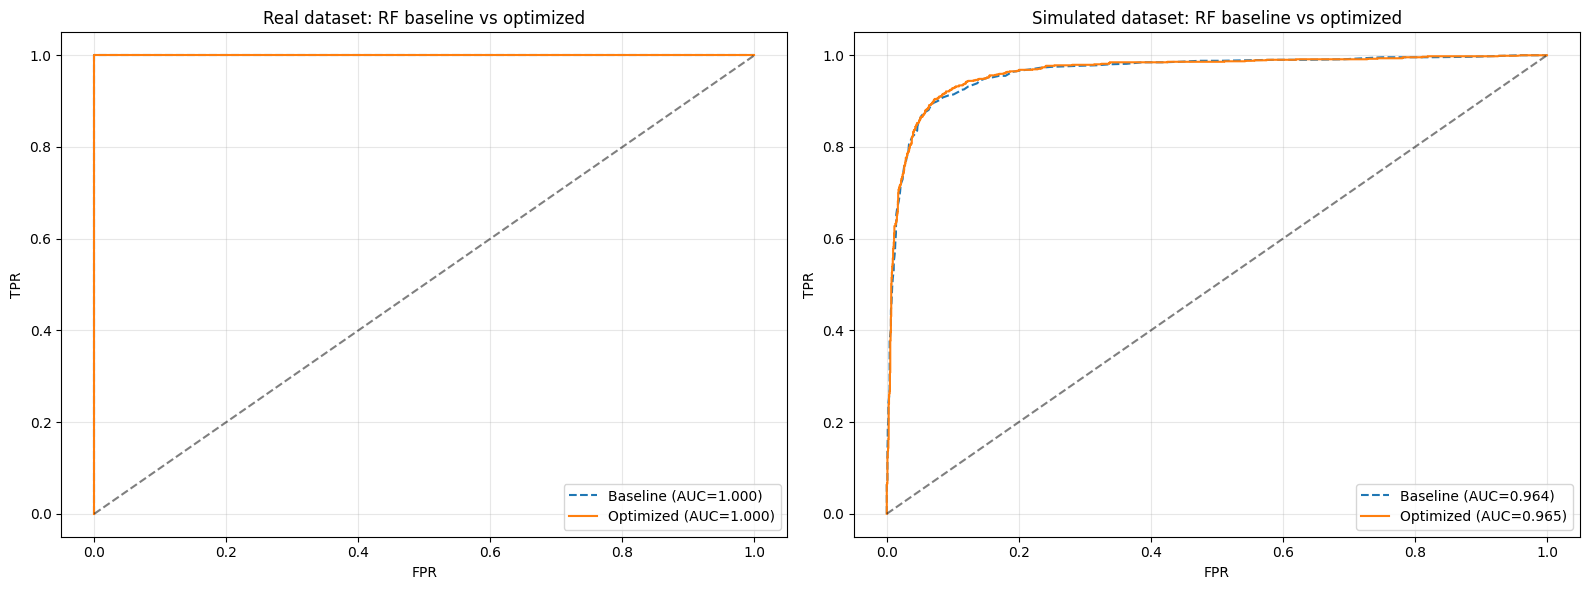

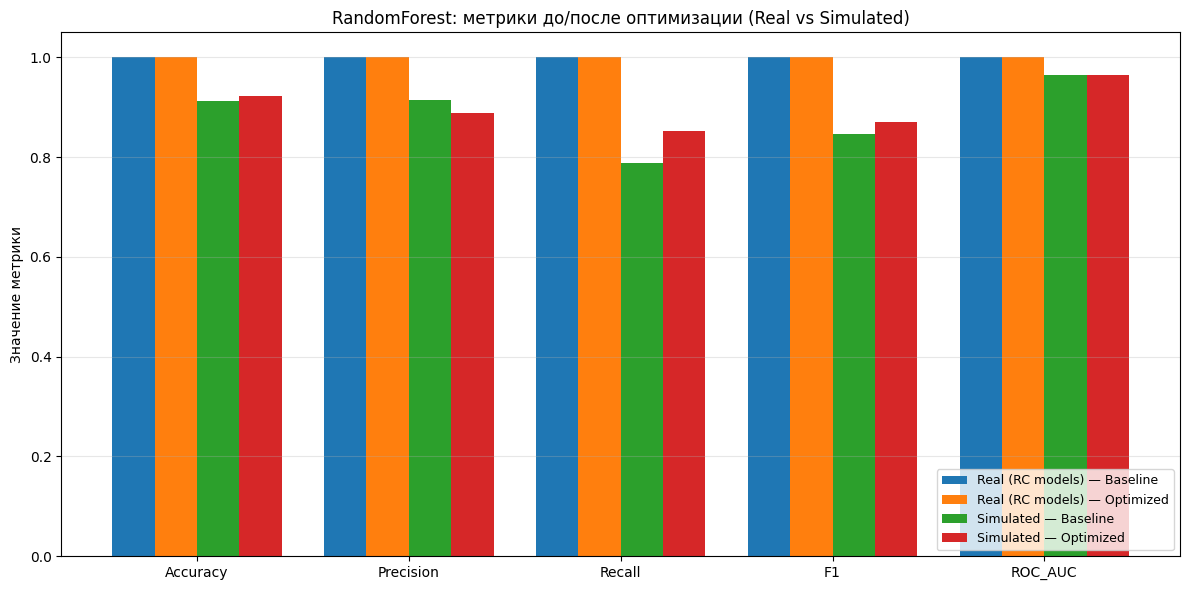


=== Улучшение после оптимизации (Delta) ===
            Dataset  Δ Accuracy    Δ F1  Δ ROC_AUC  Δ FitTime_s
0  Real (RC models)      0.0000  0.0000     0.0000      -0.3439
1         Simulated      0.0093  0.0232     0.0012       3.5812


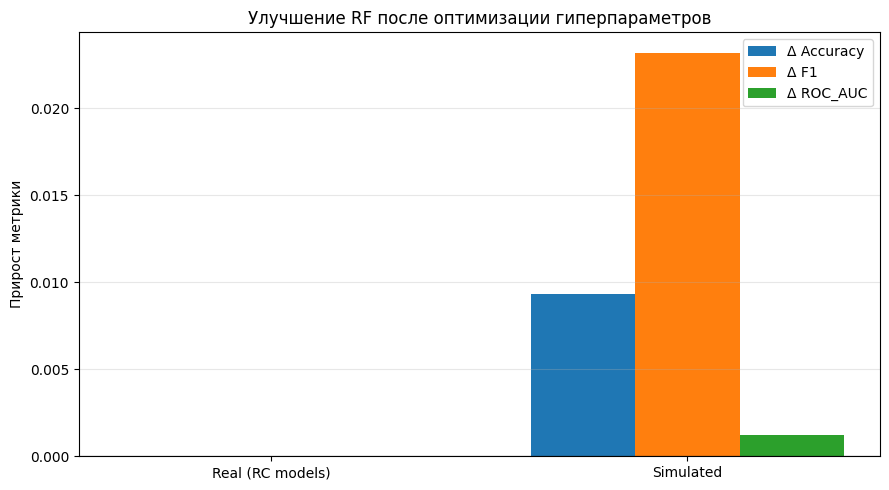


=== Важность признаков: baseline vs optimized (Real, топ-15) ===
                       Feature  Importance_baseline  Importance_optimized   Delta
32                 RetailPrice               0.3672                0.3657 -0.0015
33                   UnitPrice               0.3381                0.3505  0.0123
7         Demographic_Advanced               0.0557                0.0517 -0.0040
0                     Channels               0.0400                0.0387 -0.0013
14                 KitType_RTF               0.0354                0.0341 -0.0012
10          Demographic_Novice               0.0334                0.0317 -0.0018
8         Demographic_Beginner               0.0300                0.0312  0.0013
13                 KitType_KIT               0.0193                0.0196  0.0004
9     Demographic_Intermediate               0.0181                0.0194  0.0012
31                    Quantity               0.0186                0.0188  0.0002
11    Demographic_Professional  

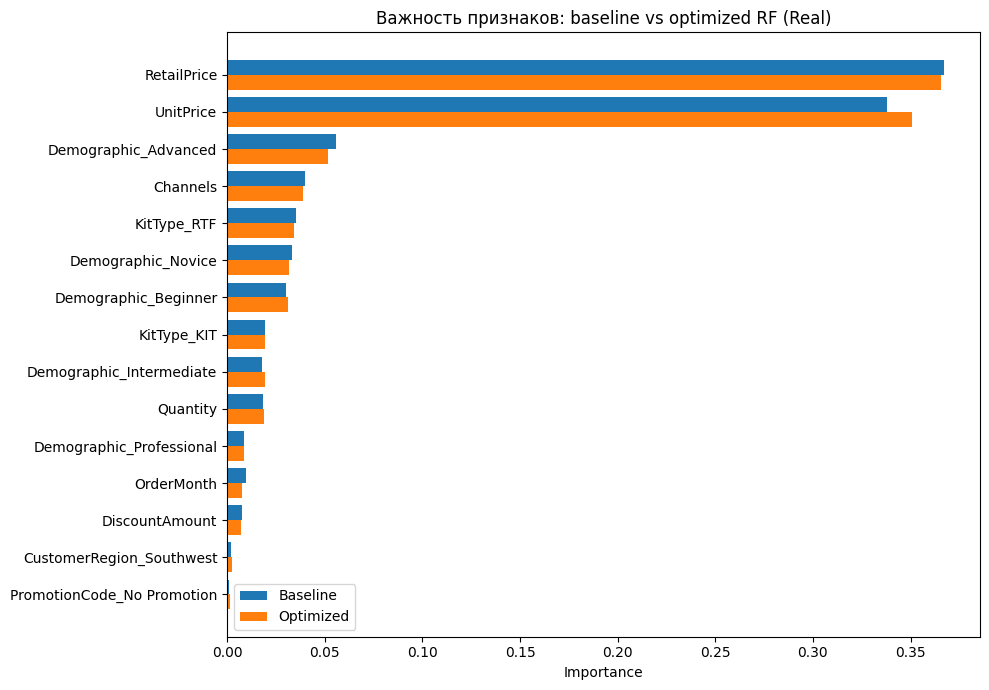


=== Важность признаков: Simulated (топ-15) ===
   Feature  Baseline  Optimized
12     f12    0.1021     0.1095
7       f7    0.1029     0.1092
11     f11    0.0754     0.0778
2       f2    0.0660     0.0682
3       f3    0.0603     0.0628
9       f9    0.0613     0.0626
16     f16    0.0614     0.0605
4       f4    0.0616     0.0603
13     f13    0.0534     0.0549
14     f14    0.0537     0.0540
0       f0    0.0503     0.0525
17     f17    0.0471     0.0496
5       f5    0.0471     0.0476
8       f8    0.0437     0.0452
15     f15    0.0206     0.0151

=== Топ-5 конфигураций поиска ===
     Dataset  param_clf__n_estimators param_clf__max_depth  param_clf__min_samples_leaf param_clf__max_features  mean_test_score  std_test_score  mean_train_score
0       Real                      100                   30                            2                    log2           1.0000          0.0000               1.0
1       Real                      300                   20                     

In [37]:
# ============================================================
# 34. Итоговое сравнение: Real vs Simulated, Baseline vs Optimized
# ============================================================
print("\n" + "=" * 60)
print("34. Итоговое сравнение")
print("=" * 60)

# Объединяем таблицы из разделов 32 и 33
df_all = pd.concat([df_real_compare, df_sim_compare], ignore_index=True)
df_all = df_all[['Dataset', 'Stage', 'Accuracy', 'Precision', 'Recall',
                 'F1', 'ROC_AUC', 'FitTime_s']].round(4)
print("\n=== Сводная таблица: до и после оптимизации на двух датасетах ===")
print(df_all)


# --- 34.1. Сравнение ROC-AUC: 4 модели ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Реальный датасет
axes[0].plot(fpr_b, tpr_b, linestyle='--',
             label=f'Baseline (AUC={metrics_baseline["ROC_AUC"]:.3f})')
axes[0].plot(fpr_o, tpr_o,
             label=f'Optimized (AUC={metrics_optimized_real["ROC_AUC"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Real dataset: RF baseline vs optimized')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)

# Симуляционные данные
axes[1].plot(fpr_sb, tpr_sb, linestyle='--',
             label=f'Baseline (AUC={metrics_sim_baseline["ROC_AUC"]:.3f})')
axes[1].plot(fpr_so, tpr_so,
             label=f'Optimized (AUC={metrics_sim_optimized["ROC_AUC"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Simulated dataset: RF baseline vs optimized')
axes[1].legend(loc='lower right'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_baseline_vs_optimized.png', dpi=150)
plt.show()


# --- 34.2. Bar plot: метрики по 4 моделям ---
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x = np.arange(len(metrics_to_plot))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(df_all.iterrows()):
    label = f"{row['Dataset']} — {row['Stage']}"
    ax.bar(x + i * width, [row[m] for m in metrics_to_plot],
           width, label=label)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Значение метрики')
ax.set_title('RandomForest: метрики до/после оптимизации (Real vs Simulated)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_metrics_before_after.png', dpi=150)
plt.show()


# --- 34.3. Улучшение (Delta) по ключевым метрикам ---
delta_rows = []
for dataset in df_all['Dataset'].unique():
    base = df_all[(df_all['Dataset'] == dataset) & (df_all['Stage'] == 'Baseline')].iloc[0]
    opt  = df_all[(df_all['Dataset'] == dataset) & (df_all['Stage'] == 'Optimized')].iloc[0]
    delta_rows.append({
        'Dataset'    : dataset,
        'Δ Accuracy' : opt['Accuracy'] - base['Accuracy'],
        'Δ F1'       : opt['F1'] - base['F1'],
        'Δ ROC_AUC'  : opt['ROC_AUC'] - base['ROC_AUC'],
        'Δ FitTime_s': opt['FitTime_s'] - base['FitTime_s'],
    })

df_delta = pd.DataFrame(delta_rows).round(4)
print("\n=== Улучшение после оптимизации (Delta) ===")
print(df_delta)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_delta))
width = 0.25

for i, m in enumerate(['Δ Accuracy', 'Δ F1', 'Δ ROC_AUC']):
    ax.bar(x + i * width, df_delta[m], width, label=m)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(df_delta['Dataset'])
ax.set_ylabel('Прирост метрики')
ax.set_title('Улучшение RF после оптимизации гиперпараметров')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_optimization_delta.png', dpi=150)
plt.show()


# --- 34.4. Важность признаков: baseline vs optimized (Real) ---
def get_feature_importance(pipe, cat_cols, num_cols):
    ohe_ = pipe.named_steps['prep'].named_transformers_.get('cat')
    if ohe_ is not None:
        cat_names = list(ohe_.get_feature_names_out(cat_cols))
    else:
        cat_names = []
    names = list(num_cols) + cat_names
    imp = pipe.named_steps['clf'].feature_importances_
    return pd.DataFrame({'Feature': names, 'Importance': imp})

imp_base = get_feature_importance(rf_baseline, cat_cols, num_cols)
imp_opt  = get_feature_importance(best_rf_real, cat_cols, num_cols)

imp_compare = (
    imp_base.rename(columns={'Importance': 'Importance_baseline'})
    .merge(imp_opt.rename(columns={'Importance': 'Importance_optimized'}),
           on='Feature', how='outer')
    .fillna(0)
)
imp_compare['Delta'] = (imp_compare['Importance_optimized']
                        - imp_compare['Importance_baseline'])
imp_compare = imp_compare.sort_values('Importance_optimized',
                                      ascending=False).head(15).round(4)

print("\n=== Важность признаков: baseline vs optimized (Real, топ-15) ===")
print(imp_compare)

top15 = imp_compare.copy()
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(top15))
ax.barh(y_pos - 0.2, top15['Importance_baseline'],  height=0.4, label='Baseline')
ax.barh(y_pos + 0.2, top15['Importance_optimized'], height=0.4, label='Optimized')
ax.set_yticks(y_pos)
ax.set_yticklabels(top15['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Важность признаков: baseline vs optimized RF (Real)')
ax.legend()
plt.tight_layout()
plt.savefig('rf_importance_before_after.png', dpi=150)
plt.show()


# --- 34.5. Важность признаков: Simulated (baseline vs optimized) ---
imp_sim_base = pd.DataFrame({
    'Feature'   : sim_feature_names,
    'Importance': rf_sim_baseline.named_steps['clf'].feature_importances_,
})
imp_sim_opt = pd.DataFrame({
    'Feature'   : sim_feature_names,
    'Importance': best_rf_sim.named_steps['clf'].feature_importances_,
})

imp_sim_compare = (
    imp_sim_base.rename(columns={'Importance': 'Baseline'})
    .merge(imp_sim_opt.rename(columns={'Importance': 'Optimized'}),
           on='Feature')
    .sort_values('Optimized', ascending=False).head(15).round(4)
)

print("\n=== Важность признаков: Simulated (топ-15) ===")
print(imp_sim_compare)


# --- 34.6. Топ-5 CV-результатов поиска ---
def cv_top5(search, dataset_name):
    df_cv_res = pd.DataFrame(search.cv_results_)
    cols = ['param_clf__n_estimators', 'param_clf__max_depth',
            'param_clf__min_samples_leaf', 'param_clf__max_features',
            'mean_test_score', 'std_test_score', 'mean_train_score']
    cols = [c for c in cols if c in df_cv_res.columns]
    top = (df_cv_res[cols]
           .sort_values('mean_test_score', ascending=False)
           .head(5).round(4))
    top.insert(0, 'Dataset', dataset_name)
    return top

top_real = cv_top5(rand_rf_real, 'Real')
top_sim  = cv_top5(rand_rf_sim,  'Simulated')
df_top = pd.concat([top_real, top_sim], ignore_index=True)
print("\n=== Топ-5 конфигураций поиска ===")
print(df_top)


# --- 34.7. Выводы ---
print("\n" + "=" * 60)
print("34. ВЫВОДЫ")
print("=" * 60)

for dataset in df_all['Dataset'].unique():
    base = df_all[(df_all['Dataset'] == dataset) & (df_all['Stage'] == 'Baseline')].iloc[0]
    opt  = df_all[(df_all['Dataset'] == dataset) & (df_all['Stage'] == 'Optimized')].iloc[0]
    print(f"\n[{dataset}]")
    print(f"  ROC-AUC: {base['ROC_AUC']:.4f} → {opt['ROC_AUC']:.4f} "
          f"(Δ = {opt['ROC_AUC'] - base['ROC_AUC']:+.4f})")
    print(f"  F1:      {base['F1']:.4f} → {opt['F1']:.4f} "
          f"(Δ = {opt['F1'] - base['F1']:+.4f})")
    print(f"  Время обучения: {base['FitTime_s']:.2f} c → {opt['FitTime_s']:.2f} c")


# --- Сохранение результатов ---
with pd.ExcelWriter('rf_optimization_results.xlsx') as writer:
    df_all.to_excel(writer, sheet_name='all_metrics', index=False)
    df_real_compare.to_excel(writer, sheet_name='real_before_after', index=False)
    df_sim_compare.to_excel(writer, sheet_name='sim_before_after', index=False)
    df_delta.to_excel(writer, sheet_name='delta', index=False)
    imp_compare.to_excel(writer, sheet_name='importance_real', index=False)
    imp_sim_compare.to_excel(writer, sheet_name='importance_sim', index=False)
    df_top.to_excel(writer, sheet_name='top5_cv', index=False)

print("\nРезультаты сохранены в rf_optimization_results.xlsx")


35. Поиск сильно коррелированных пар признаков

=== Корреляционная матрица (числовые признаки, Real) ===
                Quantity  UnitPrice  DiscountAmount  Channels  RetailPrice  OrderMonth
Quantity           1.000     -0.026           0.113    -0.007       -0.025       0.076
UnitPrice         -0.026      1.000           0.086     0.815        0.989      -0.088
DiscountAmount     0.113      0.086           1.000     0.068        0.091      -0.039
Channels          -0.007      0.815           0.068     1.000        0.743      -0.080
RetailPrice       -0.025      0.989           0.091     0.743        1.000      -0.083
OrderMonth         0.076     -0.088          -0.039    -0.080       -0.083       1.000


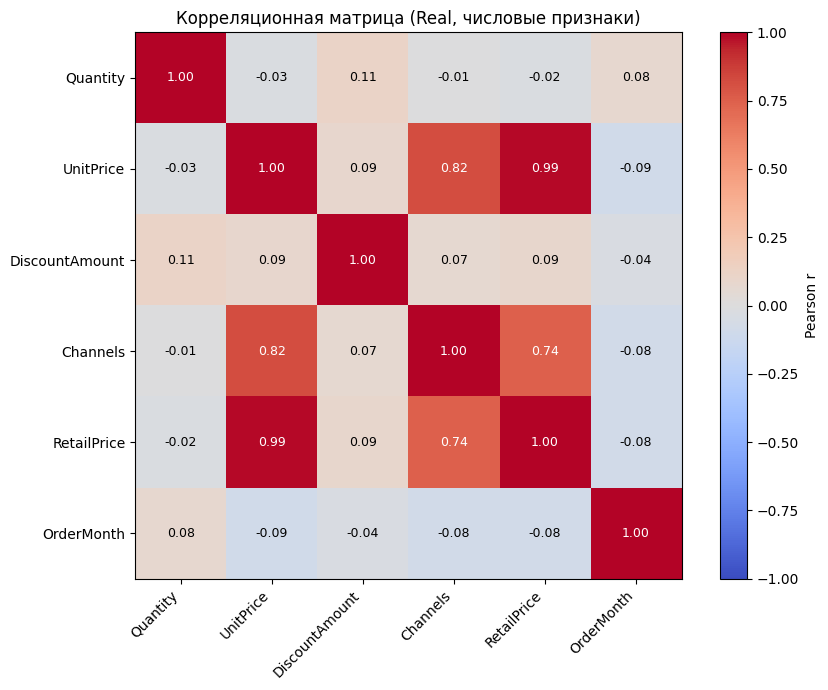


=== Найдено пар с |r| > 0.8: 2 ===
   Feature_1    Feature_2  Correlation  AbsCorrelation
1  UnitPrice  RetailPrice       0.9885          0.9885
0  UnitPrice     Channels       0.8151          0.8151

=== Топ-10 пар по |r| ===
         Feature_1       Feature_2  Correlation  AbsCorrelation
7        UnitPrice     RetailPrice       0.9885          0.9885
6        UnitPrice        Channels       0.8151          0.8151
12        Channels     RetailPrice       0.7431          0.7431
1         Quantity  DiscountAmount       0.1129          0.1129
10  DiscountAmount     RetailPrice       0.0910          0.0910
8        UnitPrice      OrderMonth      -0.0878          0.0878
5        UnitPrice  DiscountAmount       0.0857          0.0857
14     RetailPrice      OrderMonth      -0.0834          0.0834
13        Channels      OrderMonth      -0.0795          0.0795
4         Quantity      OrderMonth       0.0763          0.0763


In [38]:
# ============================================================
# 35. Поиск сильно коррелированных пар признаков (|r| > 0.8)
# ============================================================
print("\n" + "=" * 60)
print("35. Поиск сильно коррелированных пар признаков")
print("=" * 60)

# Работаем с числовыми признаками (по ним корреляция Пирсона имеет смысл).
# Категориальные можно закодировать One-Hot и посчитать корреляцию тоже,
# но интерпретировать её сложнее — поэтому начнём с числовых.
num_only_train = X_train[num_cols].copy()

# Матрица корреляций (Пирсон)
corr_real = num_only_train.corr(method='pearson')

print("\n=== Корреляционная матрица (числовые признаки, Real) ===")
print(corr_real.round(3))

# Визуализация тепловой карты корреляций
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_real.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(np.arange(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr_real.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                color='white' if abs(val) > 0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Корреляционная матрица (Real, числовые признаки)')
plt.tight_layout()
plt.savefig('corr_matrix_real.png', dpi=150)
plt.show()


# --- Поиск пар с |r| > 0.8 ---
def find_high_corr_pairs(corr_matrix, threshold=0.8):
    """Возвращает список пар признаков с |r| > threshold."""
    pairs = []
    cols = corr_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > threshold:
                pairs.append({
                    'Feature_1': cols[i],
                    'Feature_2': cols[j],
                    'Correlation': r,
                    'AbsCorrelation': abs(r),
                })
    return pd.DataFrame(pairs).sort_values('AbsCorrelation', ascending=False)

df_high_corr = find_high_corr_pairs(corr_real, threshold=0.8)

if len(df_high_corr) > 0:
    print(f"\n=== Найдено пар с |r| > 0.8: {len(df_high_corr)} ===")
    print(df_high_corr.round(4))
else:
    print("\nПар с |r| > 0.8 среди числовых признаков не найдено.")
    # Понижаем порог, чтобы показать, какие пары самые «тесные»
    df_high_corr = find_high_corr_pairs(corr_real, threshold=0.5)
    print(f"\nСамые коррелированные пары при пороге |r| > 0.5:")
    print(df_high_corr.head(10).round(4))


# --- Топ-N пар по модулю корреляции ---
def top_corr_pairs(corr_matrix, top_n=10):
    pairs = []
    cols = corr_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            pairs.append({
                'Feature_1': cols[i],
                'Feature_2': cols[j],
                'Correlation': r,
                'AbsCorrelation': abs(r),
            })
    return pd.DataFrame(pairs).sort_values('AbsCorrelation', ascending=False).head(top_n)

df_top_pairs = top_corr_pairs(corr_real, top_n=10)
print("\n=== Топ-10 пар по |r| ===")
print(df_top_pairs.round(4))


36. Модель с удалением сильно коррелированных признаков

[All features] ROC-AUC = 1.0000, F1 = 1.0000

Признаки, рекомендованные к удалению: ['UnitPrice']
Осталось признаков: 10

[Reduced features] ROC-AUC = 1.0000, F1 = 0.9924

=== Метрики при удалении по одному признаку из топ-пары ===
                 Model  N_features                                           Features  Accuracy  Precision  Recall      F1  ROC_AUC
0    Without UnitPrice          10  Quantity, DiscountAmount, Channels, RetailPric...    0.9987        1.0  0.9849  0.9924      1.0
1  Without RetailPrice          10  Quantity, UnitPrice, DiscountAmount, Channels,...    0.9987        1.0  0.9849  0.9924      1.0

=== Сравнение моделей: полный набор vs без коррелированных признаков ===
                 Model  N_features  Accuracy  Precision  Recall      F1  ROC_AUC
0         All features          11    1.0000        1.0  1.0000  1.0000      1.0
1     Reduced features          10    0.9987        1.0  0.9849  0.9924      1

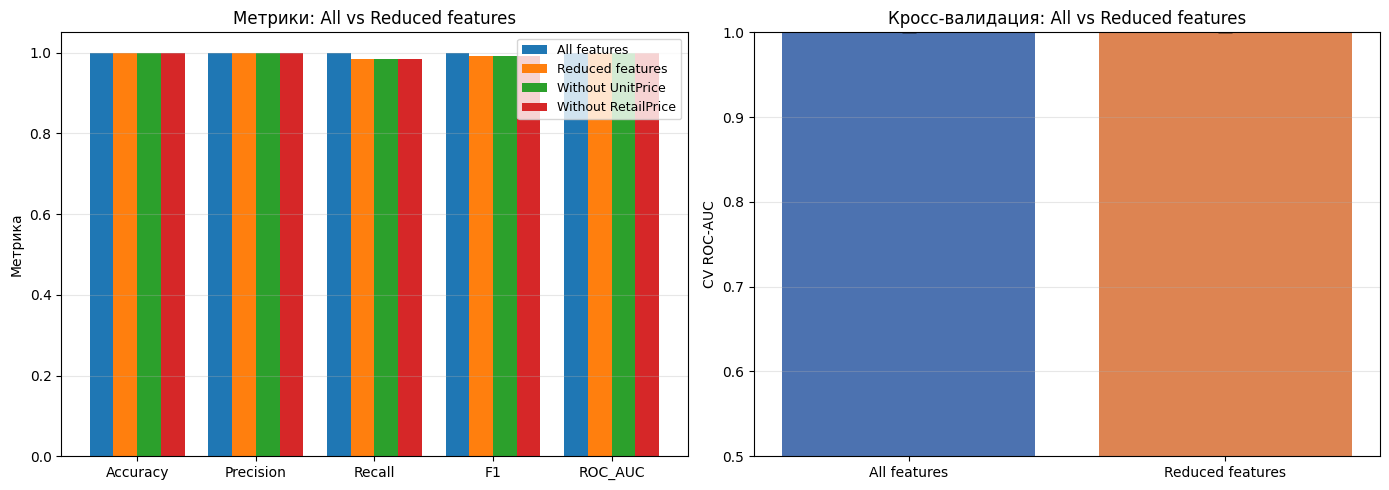


=== Важность признаков: Full vs Reduced (топ-15) ===
                      Feature    Full  Reduced
32                RetailPrice  0.3672   0.5952
33                  UnitPrice  0.3381   0.0000
7        Demographic_Advanced  0.0557   0.0688
0                    Channels  0.0400   0.0497
14                KitType_RTF  0.0354   0.0309
10         Demographic_Novice  0.0334   0.0309
8        Demographic_Beginner  0.0300   0.0344
13                KitType_KIT  0.0193   0.0424
31                   Quantity  0.0186   0.0259
9    Demographic_Intermediate  0.0181   0.0229
15                 OrderMonth  0.0099   0.0227
11   Demographic_Professional  0.0088   0.0151
12             DiscountAmount  0.0076   0.0155
6    CustomerRegion_Southwest  0.0021   0.0051
27  PromotionCode_SALE2016-03  0.0014   0.0018


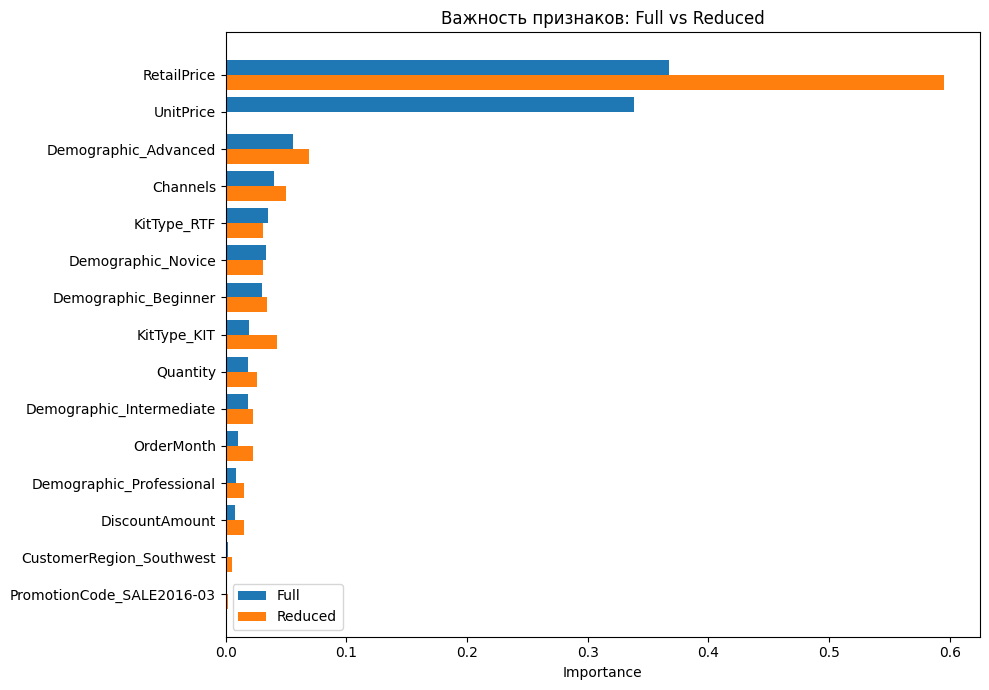

In [43]:
# ============================================================
# 36. Удаление сильно коррелированных признаков и повторное обучение
# ============================================================
print("\n" + "=" * 60)
print("36. Модель с удалением сильно коррелированных признаков")
print("=" * 60)


def evaluate_rf_custom(feature_list, num_list, cat_list, label=''):
    """Обучает RF на произвольном наборе признаков и возвращает метрики."""
    if not feature_list:
        raise ValueError(f"Пустой набор для '{label}'")

    transformers = []
    num_sel = [f for f in feature_list if f in num_list]
    cat_sel = [f for f in feature_list if f in cat_list]
    if num_sel:
        transformers.append(('num', StandardScaler(), num_sel))
    if cat_sel:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_sel))

    pipe = Pipeline([
        ('prep', ColumnTransformer(transformers)),
        ('clf', RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    pipe.fit(X_train[feature_list], y_train)

    y_pred  = pipe.predict(X_test[feature_list])
    y_proba = pipe.predict_proba(X_test[feature_list])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    return {
        'Model'     : label,
        'N_features': len(feature_list),
        'Features'  : ', '.join(feature_list),
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, zero_division=0),
        'F1'        : f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC'   : auc(fpr, tpr),
    }, pipe


# --- 36.1. Базовая модель — все признаки ---
metrics_full, pipe_full = evaluate_rf_custom(features, num_cols, cat_cols, 'All features')
print(f"\n[All features] ROC-AUC = {metrics_full['ROC_AUC']:.4f}, F1 = {metrics_full['F1']:.4f}")


# --- 36.2. Удаляем по одному признаку из каждой сильно коррелированной пары ---
# Стратегия: из каждой пары удаляем тот признак, который имеет
# БОЛЬШУЮ среднюю корреляцию с остальными (менее "уникальный").
# Если пар с |r|>0.8 нет, используем топ-5 пар из топ-списка.

pairs_to_use = df_high_corr if len(df_high_corr) > 0 else df_top_pairs.head(5)
features_to_drop = set()

for _, row in pairs_to_use.iterrows():
    f1, f2 = row['Feature_1'], row['Feature_2']
    if f1 in features_to_drop or f2 in features_to_drop:
        continue
    # Сравниваем среднюю абсолютную корреляцию каждого признака с остальными
    mean_abs_1 = corr_real[f1].drop(f1).abs().mean()
    mean_abs_2 = corr_real[f2].drop(f2).abs().mean()
    drop = f1 if mean_abs_1 >= mean_abs_2 else f2
    features_to_drop.add(drop)

features_to_drop = sorted(features_to_drop)
features_reduced = [f for f in features if f not in features_to_drop]

print(f"\nПризнаки, рекомендованные к удалению: {features_to_drop}")
print(f"Осталось признаков: {len(features_reduced)}")


# --- 36.3. Модель с удалёнными признаками ---
if features_to_drop:
    metrics_reduced, pipe_reduced = evaluate_rf_custom(
        features_reduced, num_cols, cat_cols, 'Reduced features'
    )
    print(f"\n[Reduced features] ROC-AUC = {metrics_reduced['ROC_AUC']:.4f}, "
          f"F1 = {metrics_reduced['F1']:.4f}")
else:
    metrics_reduced = None
    pipe_reduced = None
    print("\nНечего удалять — все признаки уникальны.")


# --- 36.4. Модель «только без одного признака» (для проверки эффекта) ---
# Дополнительно: удалим по одному «самому коррелированному» признаку из топ-пары
# и посмотрим метрики отдельно, чтобы понять вклад каждого удаления.
per_drop_results = []
if len(df_top_pairs) > 0:
    top_pair = df_top_pairs.iloc[0]
    for f in [top_pair['Feature_1'], top_pair['Feature_2']]:
        feats = [x for x in features if x != f]
        m, _ = evaluate_rf_custom(feats, num_cols, cat_cols, f'Without {f}')
        per_drop_results.append(m)

df_per_drop = pd.DataFrame(per_drop_results).round(4)
if len(df_per_drop) > 0:
    print("\n=== Метрики при удалении по одному признаку из топ-пары ===")
    print(df_per_drop)


# --- 36.5. Сводное сравнение ---
rows = [metrics_full]
if metrics_reduced is not None:
    rows.append(metrics_reduced)
if len(df_per_drop) > 0:
    rows.extend(per_drop_results)

df_corr_compare = pd.DataFrame(rows).round(4)
print("\n=== Сравнение моделей: полный набор vs без коррелированных признаков ===")
print(df_corr_compare[['Model', 'N_features', 'Accuracy', 'Precision',
                       'Recall', 'F1', 'ROC_AUC']])


# --- 36.6. Кросс-валидация для более честного сравнения ---
def cv_auc_custom(feature_list, num_list, cat_list, label=''):
    num_sel = [f for f in feature_list if f in num_list]
    cat_sel = [f for f in feature_list if f in cat_list]
    transformers = []
    if num_sel:
        transformers.append(('num', StandardScaler(), num_sel))
    if cat_sel:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_sel))

    pipe = Pipeline([
        ('prep', ColumnTransformer(transformers)),
        ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1))
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X[feature_list], y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    return {'Model': label, 'N_features': len(feature_list),
            'CV_AUC_mean': scores.mean(), 'CV_AUC_std': scores.std()}

cv_rows = [cv_auc_custom(features, num_cols, cat_cols, 'All features')]
if features_to_drop:
    cv_rows.append(cv_auc_custom(features_reduced, num_cols, cat_cols, 'Reduced features'))

df_cv_corr = pd.DataFrame(cv_rows).round(4)
print("\n=== Кросс-валидация (ROC-AUC, 5 фолдов) ===")
print(df_cv_corr)


# --- 36.7. График сравнения ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot метрик
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35 if len(df_corr_compare) == 2 else 0.2

for i, (_, row) in enumerate(df_corr_compare.iterrows()):
    axes[0].bar(x + i * width, [row[m] for m in metrics_to_plot],
                width, label=row['Model'])

axes[0].set_xticks(x + width * (len(df_corr_compare) - 1) / 2)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Метрика')
axes[0].set_title('Метрики: All vs Reduced features')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

# CV сравнение
cv_labels = df_cv_corr['Model']
cv_means  = df_cv_corr['CV_AUC_mean']
cv_stds   = df_cv_corr['CV_AUC_std']
axes[1].bar(cv_labels, cv_means, yerr=cv_stds, capsize=5,
            color=['#4C72B0', '#DD8452'][:len(cv_labels)])
axes[1].set_ylabel('CV ROC-AUC')
axes[1].set_title('Кросс-валидация: All vs Reduced features')
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('corr_feature_reduction_comparison.png', dpi=150)
plt.show()

def get_importance_by_original(pipe):
    """
    Возвращает DataFrame с важностями признаков.
    Автоматически определяет, какие числовые и категориальные
    колонки реально использовались в ColumnTransformer.
    """
    prep = pipe.named_steps['prep']
    clf  = pipe.named_steps['clf']

    num_used, cat_used = [], []
    for name, transformer, columns in prep.transformers_:
        if name == 'num':
            num_used = list(columns)
        elif name == 'cat':
            cat_used = list(columns)

    cat_names = []
    if cat_used:
        ohe = prep.named_transformers_.get('cat')
        if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
            cat_names = list(ohe.get_feature_names_out(cat_used))

    names = num_used + cat_names
    importance = clf.feature_importances_

    # На всякий случай согласуем длины — если что-то не совпало,
    # обрежем до минимума.
    n = min(len(names), len(importance))
    return pd.DataFrame({'Feature': names[:n], 'Importance': importance[:n]})


imp_full = get_importance_by_original(pipe_full)

if pipe_reduced is not None:
    imp_red = get_importance_by_original(pipe_reduced)

    imp_cmp = (
        imp_full.rename(columns={'Importance': 'Full'})
        .merge(imp_red.rename(columns={'Importance': 'Reduced'}),
               on='Feature', how='outer')
        .fillna(0)
        .sort_values('Full', ascending=False)
        .head(15).round(4)
    )
    print("\n=== Важность признаков: Full vs Reduced (топ-15) ===")
    print(imp_cmp)

    # Визуализация: только признаки, которые остались хотя бы в одной модели
    top_feats = imp_cmp['Feature'].tolist()
    fig, ax = plt.subplots(figsize=(10, 7))
    y_pos = np.arange(len(top_feats))
    ax.barh(y_pos - 0.2, imp_cmp['Full'],    height=0.4, label='Full')
    ax.barh(y_pos + 0.2, imp_cmp['Reduced'], height=0.4, label='Reduced')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats)
    ax.invert_yaxis()
    ax.set_xlabel('Importance')
    ax.set_title('Важность признаков: Full vs Reduced')
    ax.legend()
    plt.tight_layout()
    plt.savefig('importance_full_vs_reduced.png', dpi=150)
    plt.show()


38. Confusion matrix (Simulated data)

=== Confusion matrix: RF (Simulated) ===
          Pred 0  Pred 1
Actual 0    1989      98
Actual 1     135     778

TN = 1989, FP = 98, FN = 135, TP = 778
Ошибок всего: 233 (7.77%)
  — ложные срабатывания (FP, класс 0 назван классом 1): 98 (3.27%)
  — пропуски (FN, класс 1 назван классом 0):            135 (4.50%)
→ Чаще теряем класс 1 (FN больше): модель склонна недооценивать положительный класс.

=== Confusion matrix (нормализация по истинным меткам) ===
          Pred 0  Pred 1
Actual 0  0.9530  0.0470
Actual 1  0.1479  0.8521

=== Confusion matrix (нормализация по предсказаниям) ===
          Pred 0  Pred 1
Actual 0  0.9364  0.1119
Actual 1  0.0636  0.8881


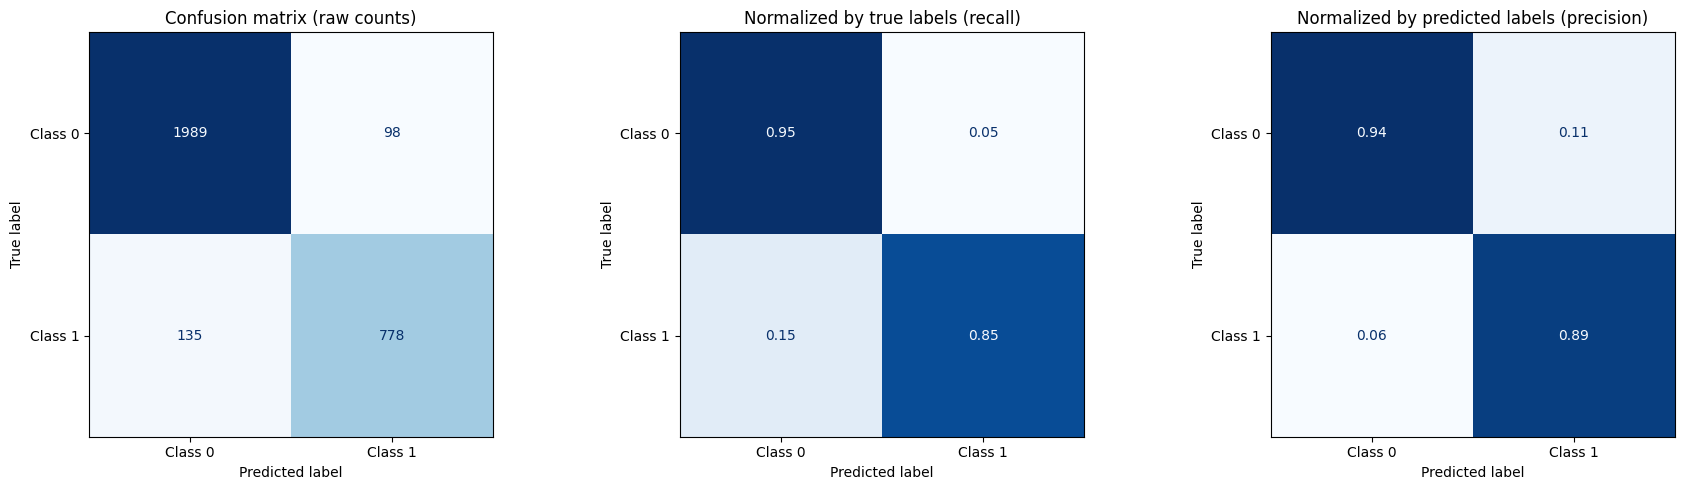

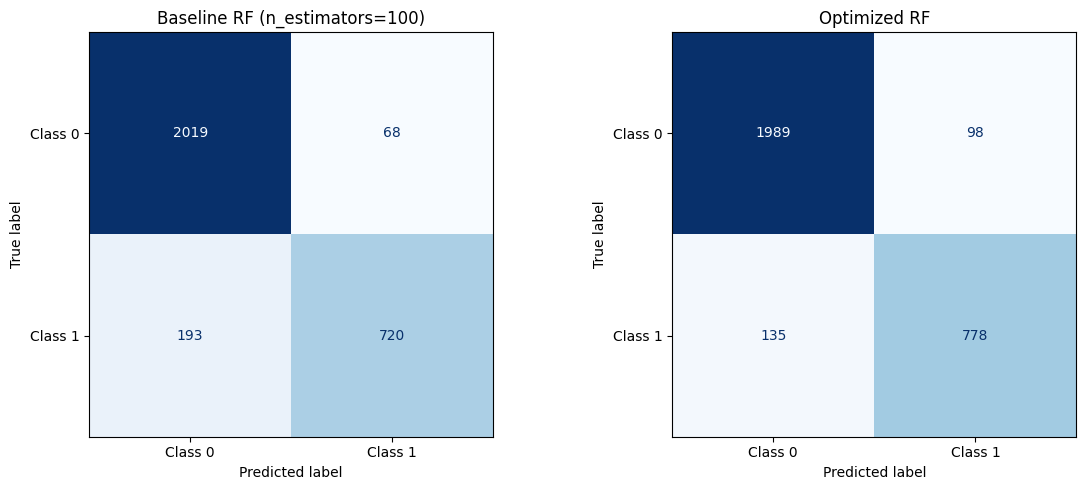


=== Скорости ошибок ===
FPR (False Positive Rate): 0.0470 — доля класса 0, ошибочно названного классом 1
FNR (False Negative Rate): 0.1479 — доля класса 1, ошибочно названного классом 0
→ Модель чаще пропускает класс 1 (высокий FNR).


In [44]:
# ============================================================
# 38. Confusion matrix на симуляционных данных
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\n" + "=" * 60)
print("38. Confusion matrix (Simulated data)")
print("=" * 60)

# Используем лучшую модель RF для симуляционных данных (из раздела 33)
y_pred_sim_rf = best_rf_sim.predict(X_sim_test)
y_proba_sim_rf = best_rf_sim.predict_proba(X_sim_test)[:, 1]

# --- 38.1. Сырая confusion matrix ---
cm_sim_rf = confusion_matrix(y_sim_test, y_pred_sim_rf)
print("\n=== Confusion matrix: RF (Simulated) ===")
print(pd.DataFrame(cm_sim_rf,
                   index=['Actual 0', 'Actual 1'],
                   columns=['Pred 0', 'Pred 1']))

# Метрики, которые напрямую считаются из confusion matrix
tn, fp, fn, tp = cm_sim_rf.ravel()
print(f"\nTN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

# Частота путаницы
total = cm_sim_rf.sum()
misclassified = fp + fn
print(f"Ошибок всего: {misclassified} ({misclassified / total * 100:.2f}%)")
print(f"  — ложные срабатывания (FP, класс 0 назван классом 1): {fp} ({fp / total * 100:.2f}%)")
print(f"  — пропуски (FN, класс 1 назван классом 0):            {fn} ({fn / total * 100:.2f}%)")

if fn > fp:
    print("→ Чаще теряем класс 1 (FN больше): модель склонна недооценивать положительный класс.")
elif fp > fn:
    print("→ Чаще ошибочно называем класс 1 (FP больше): модель склонна переоценивать положительный класс.")
else:
    print("→ Ошибки FP и FN сбалансированы.")


# --- 38.2. Нормализованные матрицы (по строкам и по столбцам) ---
cm_norm_true = confusion_matrix(y_sim_test, y_pred_sim_rf, normalize='true')
cm_norm_pred = confusion_matrix(y_sim_test, y_pred_sim_rf, normalize='pred')

print("\n=== Confusion matrix (нормализация по истинным меткам) ===")
print(pd.DataFrame(cm_norm_true.round(4),
                   index=['Actual 0', 'Actual 1'],
                   columns=['Pred 0', 'Pred 1']))

print("\n=== Confusion matrix (нормализация по предсказаниям) ===")
print(pd.DataFrame(cm_norm_pred.round(4),
                   index=['Actual 0', 'Actual 1'],
                   columns=['Pred 0', 'Pred 1']))


# --- 38.3. Визуализация: сырая + две нормализованные ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title, fmt in [
    (axes[0], cm_sim_rf,    'Confusion matrix (raw counts)',           'd'),
    (axes[1], cm_norm_true, 'Normalized by true labels (recall)',      '.2f'),
    (axes[2], cm_norm_pred, 'Normalized by predicted labels (precision)', '.2f'),
]:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=ax, cmap='Blues', values_format=fmt, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrix_simulated.png', dpi=150)
plt.show()


# --- 38.4. Confusion matrix для baseline RF (для сравнения) ---
y_pred_sim_base = rf_sim_baseline.predict(X_sim_test)
cm_sim_base = confusion_matrix(y_sim_test, y_pred_sim_base)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in [
    (axes[0], cm_sim_base, 'Baseline RF (n_estimators=100)'),
    (axes[1], cm_sim_rf,   'Optimized RF'),
]:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrix_sim_baseline_vs_optimized.png', dpi=150)
plt.show()


# --- 38.5. Что чаще путается: интерпретация через FP/FN rate ---
fpr_sim = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr_sim = fn / (fn + tp) if (fn + tp) > 0 else np.nan

print("\n=== Скорости ошибок ===")
print(f"FPR (False Positive Rate): {fpr_sim:.4f} — доля класса 0, ошибочно названного классом 1")
print(f"FNR (False Negative Rate): {fnr_sim:.4f} — доля класса 1, ошибочно названного классом 0")

if fnr_sim > fpr_sim:
    print("→ Модель чаще пропускает класс 1 (высокий FNR).")
else:
    print("→ Модель чаще ошибочно предсказывает класс 1 (высокий FPR).")


38. Confusion matrix (Simulated data)

=== Confusion matrix: RF (Simulated) ===
          Pred 0  Pred 1
Actual 0    1989      98
Actual 1     135     778

TN = 1989, FP = 98, FN = 135, TP = 778
Ошибок всего: 233 (7.77%)
  — ложные срабатывания (FP, класс 0 назван классом 1): 98 (3.27%)
  — пропуски (FN, класс 1 назван классом 0):            135 (4.50%)
→ Чаще теряем класс 1 (FN больше): модель склонна недооценивать положительный класс.

=== Confusion matrix (нормализация по истинным меткам) ===
          Pred 0  Pred 1
Actual 0  0.9530  0.0470
Actual 1  0.1479  0.8521

=== Confusion matrix (нормализация по предсказаниям) ===
          Pred 0  Pred 1
Actual 0  0.9364  0.1119
Actual 1  0.0636  0.8881


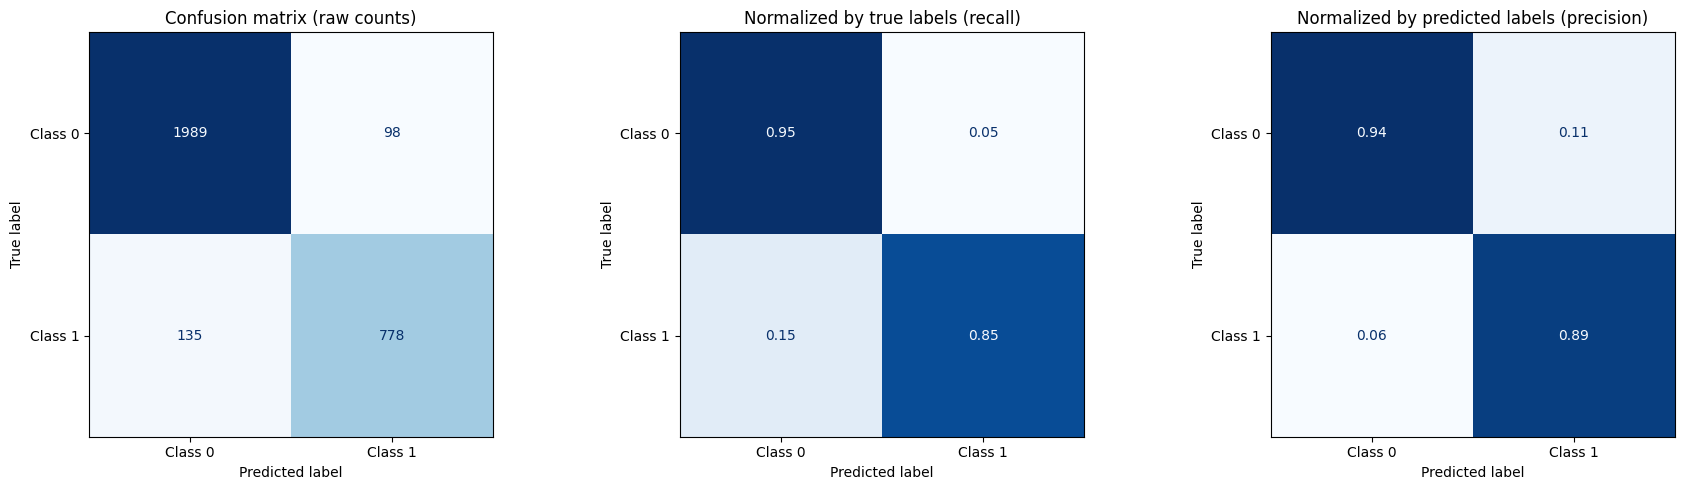

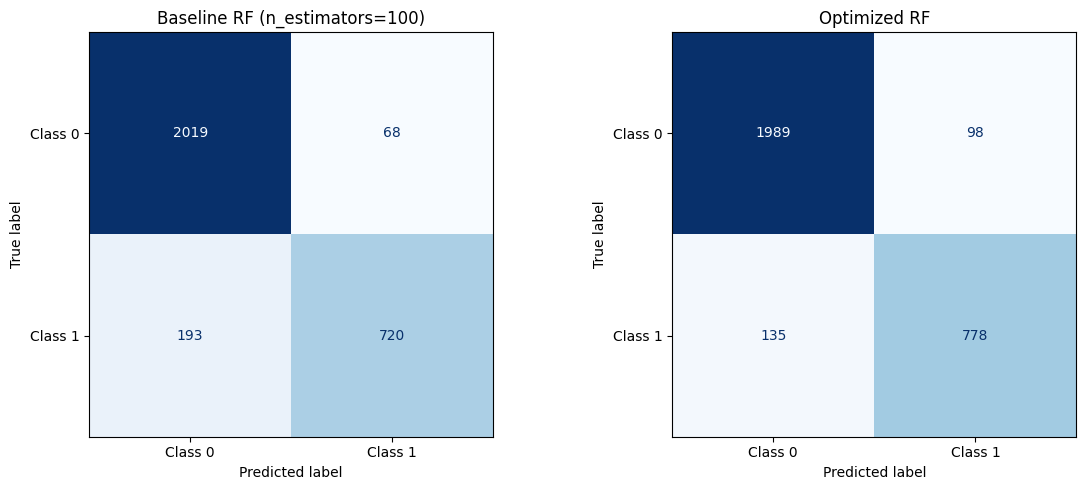


=== Скорости ошибок ===
FPR (False Positive Rate): 0.0470 — доля класса 0, ошибочно названного классом 1
FNR (False Negative Rate): 0.1479 — доля класса 1, ошибочно названного классом 0
→ Модель чаще пропускает класс 1 (высокий FNR).


In [45]:
# ============================================================
# 38. Confusion matrix на симуляционных данных
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\n" + "=" * 60)
print("38. Confusion matrix (Simulated data)")
print("=" * 60)

# Используем лучшую модель RF для симуляционных данных (из раздела 33)
y_pred_sim_rf = best_rf_sim.predict(X_sim_test)
y_proba_sim_rf = best_rf_sim.predict_proba(X_sim_test)[:, 1]

# --- 38.1. Сырая confusion matrix ---
cm_sim_rf = confusion_matrix(y_sim_test, y_pred_sim_rf)
print("\n=== Confusion matrix: RF (Simulated) ===")
print(pd.DataFrame(cm_sim_rf,
                   index=['Actual 0', 'Actual 1'],
                   columns=['Pred 0', 'Pred 1']))

# Метрики, которые напрямую считаются из confusion matrix
tn, fp, fn, tp = cm_sim_rf.ravel()
print(f"\nTN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

# Частота путаницы
total = cm_sim_rf.sum()
misclassified = fp + fn
print(f"Ошибок всего: {misclassified} ({misclassified / total * 100:.2f}%)")
print(f"  — ложные срабатывания (FP, класс 0 назван классом 1): {fp} ({fp / total * 100:.2f}%)")
print(f"  — пропуски (FN, класс 1 назван классом 0):            {fn} ({fn / total * 100:.2f}%)")

if fn > fp:
    print("→ Чаще теряем класс 1 (FN больше): модель склонна недооценивать положительный класс.")
elif fp > fn:
    print("→ Чаще ошибочно называем класс 1 (FP больше): модель склонна переоценивать положительный класс.")
else:
    print("→ Ошибки FP и FN сбалансированы.")


# --- 38.2. Нормализованные матрицы (по строкам и по столбцам) ---
cm_norm_true = confusion_matrix(y_sim_test, y_pred_sim_rf, normalize='true')
cm_norm_pred = confusion_matrix(y_sim_test, y_pred_sim_rf, normalize='pred')

print("\n=== Confusion matrix (нормализация по истинным меткам) ===")
print(pd.DataFrame(cm_norm_true.round(4),
                   index=['Actual 0', 'Actual 1'],
                   columns=['Pred 0', 'Pred 1']))

print("\n=== Confusion matrix (нормализация по предсказаниям) ===")
print(pd.DataFrame(cm_norm_pred.round(4),
                   index=['Actual 0', 'Actual 1'],
                   columns=['Pred 0', 'Pred 1']))


# --- 38.3. Визуализация: сырая + две нормализованные ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title, fmt in [
    (axes[0], cm_sim_rf,    'Confusion matrix (raw counts)',           'd'),
    (axes[1], cm_norm_true, 'Normalized by true labels (recall)',      '.2f'),
    (axes[2], cm_norm_pred, 'Normalized by predicted labels (precision)', '.2f'),
]:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=ax, cmap='Blues', values_format=fmt, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrix_simulated.png', dpi=150)
plt.show()


# --- 38.4. Confusion matrix для baseline RF (для сравнения) ---
y_pred_sim_base = rf_sim_baseline.predict(X_sim_test)
cm_sim_base = confusion_matrix(y_sim_test, y_pred_sim_base)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in [
    (axes[0], cm_sim_base, 'Baseline RF (n_estimators=100)'),
    (axes[1], cm_sim_rf,   'Optimized RF'),
]:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrix_sim_baseline_vs_optimized.png', dpi=150)
plt.show()


# --- 38.5. Что чаще путается: интерпретация через FP/FN rate ---
fpr_sim = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr_sim = fn / (fn + tp) if (fn + tp) > 0 else np.nan

print("\n=== Скорости ошибок ===")
print(f"FPR (False Positive Rate): {fpr_sim:.4f} — доля класса 0, ошибочно названного классом 1")
print(f"FNR (False Negative Rate): {fnr_sim:.4f} — доля класса 1, ошибочно названного классом 0")

if fnr_sim > fpr_sim:
    print("→ Модель чаще пропускает класс 1 (высокий FNR).")
else:
    print("→ Модель чаще ошибочно предсказывает класс 1 (высокий FPR).")


40. n_estimators vs confusion matrix (Simulated)

=== Метрики vs n_estimators (Simulated) ===
   n_estimators    TN  FP   FN   TP     FPR     FNR  Accuracy  Precision  Recall      F1  ROC_AUC
0            10  2003  84  266  647  0.0402  0.2913    0.8833     0.8851  0.7087  0.7871   0.9406
1            25  1999  88  197  716  0.0422  0.2158    0.9050     0.8905  0.7842  0.8340   0.9578
2            50  2021  66  196  717  0.0316  0.2147    0.9127     0.9157  0.7853  0.8455   0.9621
3           100  2019  68  193  720  0.0326  0.2114    0.9130     0.9137  0.7886  0.8466   0.9638
4           200  2015  72  189  724  0.0345  0.2070    0.9130     0.9095  0.7930  0.8473   0.9644
5           300  2014  73  186  727  0.0350  0.2037    0.9137     0.9088  0.7963  0.8488   0.9642
6           500  2012  75  176  737  0.0359  0.1928    0.9163     0.9076  0.8072  0.8545   0.9642


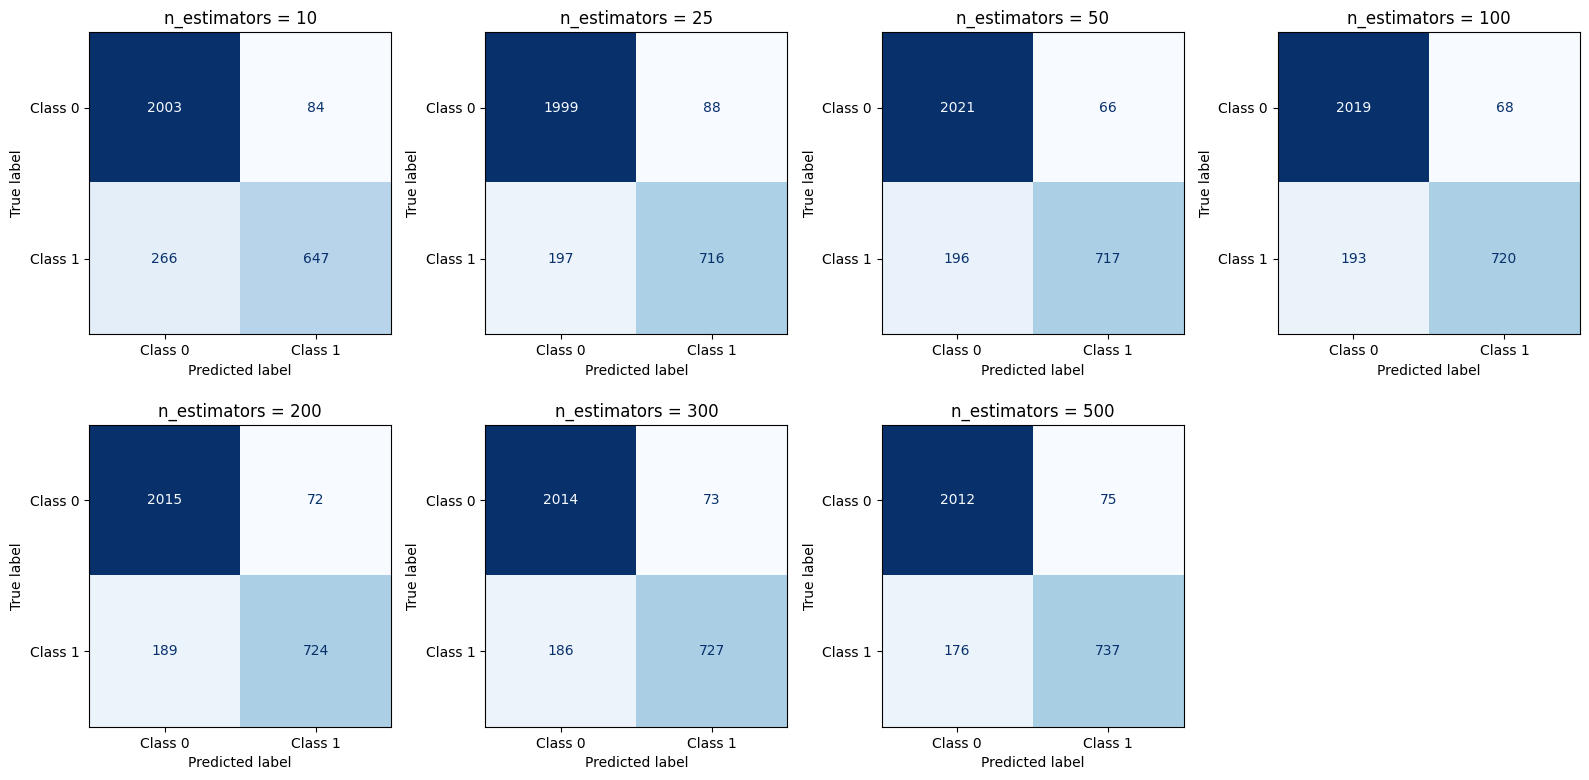

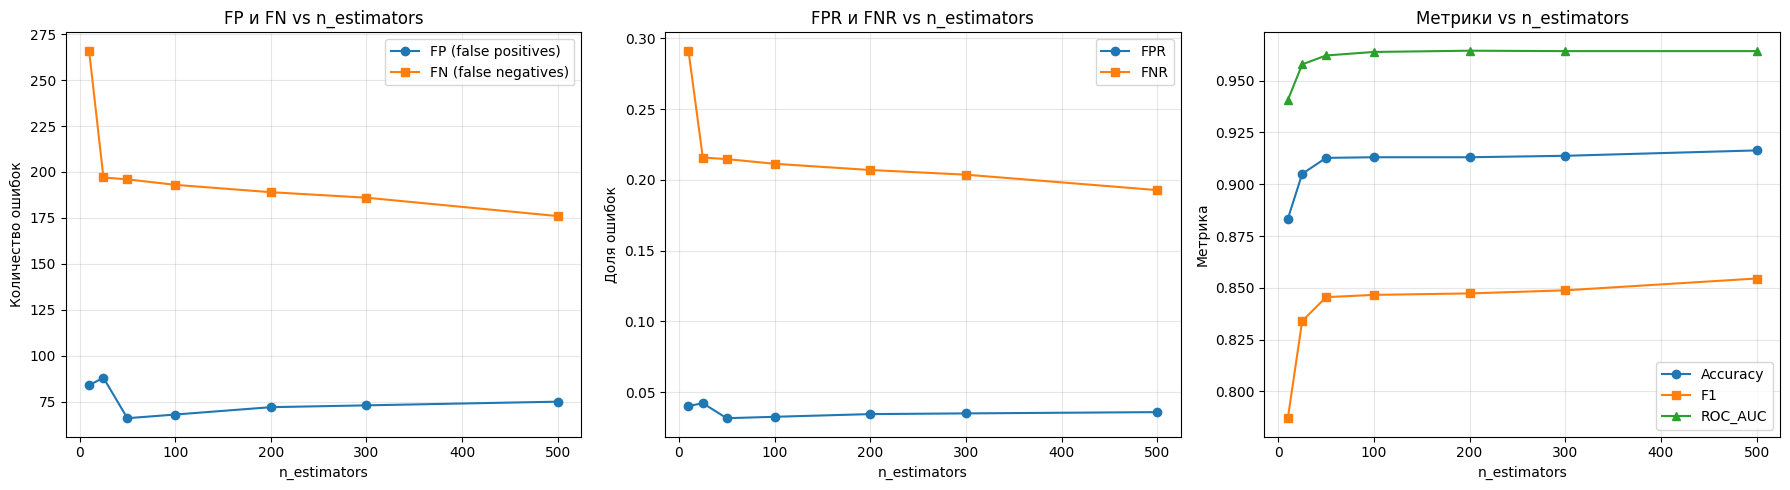


=== Изменение метрик и ошибок относительно n_estimators=100 ===
   n_estimators  Δ Accuracy    Δ F1  Δ ROC_AUC  Δ FP  Δ FN
0            10     -0.0297 -0.0595    -0.0232  16.0  73.0
1            25     -0.0080 -0.0126    -0.0060  20.0   4.0
2            50     -0.0003 -0.0011    -0.0017  -2.0   3.0
3           100      0.0000  0.0000     0.0000   0.0   0.0
4           200      0.0000  0.0007     0.0006   4.0  -4.0
5           300      0.0007  0.0022     0.0004   5.0  -7.0
6           500      0.0033  0.0079     0.0004   7.0 -17.0

=== Интерпретация ===
Лучший F1 при n_estimators = 500 (F1 = 0.8545)
Лучший ROC-AUC при n_estimators = 200 (AUC = 0.9644)

Разброс FP по всем n_estimators: 22
Разброс FN по всем n_estimators: 90
→ FN сильнее зависит от n_estimators: качество распознавания класса 1 чувствительно к числу деревьев.


NameError: name 'df_lr_vs_rf_sim' is not defined

In [46]:
# ============================================================
# 40. n_estimators vs confusion matrix (Simulated)
# ============================================================
print("\n" + "=" * 60)
print("40. n_estimators vs confusion matrix (Simulated)")
print("=" * 60)

n_estimators_grid = [10, 25, 50, 100, 200, 300, 500]

results_ne = []
cms_ne = {}

for n in n_estimators_grid:
    rf = Pipeline([
        ('prep', sim_preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=n,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    rf.fit(X_sim_train, y_sim_train)

    y_pred_ = rf.predict(X_sim_test)
    y_proba_ = rf.predict_proba(X_sim_test)[:, 1]

    cm_ = confusion_matrix(y_sim_test, y_pred_)
    cms_ne[n] = cm_

    tn_, fp_, fn_, tp_ = cm_.ravel()
    fpr_, tpr_, _ = roc_curve(y_sim_test, y_proba_)

    results_ne.append({
        'n_estimators': n,
        'TN': tn_, 'FP': fp_, 'FN': fn_, 'TP': tp_,
        'FPR': fp_ / (fp_ + tn_) if (fp_ + tn_) > 0 else np.nan,
        'FNR': fn_ / (fn_ + tp_) if (fn_ + tp_) > 0 else np.nan,
        'Accuracy' : accuracy_score(y_sim_test, y_pred_),
        'Precision': precision_score(y_sim_test, y_pred_, zero_division=0),
        'Recall'   : recall_score(y_sim_test, y_pred_, zero_division=0),
        'F1'       : f1_score(y_sim_test, y_pred_, zero_division=0),
        'ROC_AUC'  : auc(fpr_, tpr_),
    })

df_ne = pd.DataFrame(results_ne).round(4)
print("\n=== Метрики vs n_estimators (Simulated) ===")
print(df_ne)


# --- 40.1. Сетка confusion matrix для всех n ---
n_cols = 4
n_rows = int(np.ceil(len(n_estimators_grid) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, n in enumerate(n_estimators_grid):
    cm_ = cms_ne[n]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_,
                                  display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
    axes[i].set_title(f'n_estimators = {n}')

for j in range(len(n_estimators_grid), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices_by_n_estimators.png', dpi=150)
plt.show()


# --- 40.2. Динамика FP/FN и метрик ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FP / FN по n_estimators
axes[0].plot(df_ne['n_estimators'], df_ne['FP'], marker='o', label='FP (false positives)')
axes[0].plot(df_ne['n_estimators'], df_ne['FN'], marker='s', label='FN (false negatives)')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Количество ошибок')
axes[0].set_title('FP и FN vs n_estimators')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# FPR / FNR
axes[1].plot(df_ne['n_estimators'], df_ne['FPR'], marker='o', label='FPR')
axes[1].plot(df_ne['n_estimators'], df_ne['FNR'], marker='s', label='FNR')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Доля ошибок')
axes[1].set_title('FPR и FNR vs n_estimators')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Метрики качества
for m, mk in [('Accuracy', 'o'), ('F1', 's'), ('ROC_AUC', '^')]:
    axes[2].plot(df_ne['n_estimators'], df_ne[m], marker=mk, label=m)
axes[2].set_xlabel('n_estimators')
axes[2].set_ylabel('Метрика')
axes[2].set_title('Метрики vs n_estimators')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('n_estimators_confusion_dynamics.png', dpi=150)
plt.show()


# --- 40.3. Изменение ошибок относительно baseline ---
base_ne = 100
if base_ne in df_ne['n_estimators'].values:
    base_row = df_ne[df_ne['n_estimators'] == base_ne].iloc[0]

    df_delta_ne = df_ne.copy()
    df_delta_ne['Δ Accuracy'] = df_delta_ne['Accuracy'] - base_row['Accuracy']
    df_delta_ne['Δ F1']       = df_delta_ne['F1'] - base_row['F1']
    df_delta_ne['Δ ROC_AUC']  = df_delta_ne['ROC_AUC'] - base_row['ROC_AUC']
    df_delta_ne['Δ FP']       = df_delta_ne['FP'] - base_row['FP']
    df_delta_ne['Δ FN']       = df_delta_ne['FN'] - base_row['FN']

    print(f"\n=== Изменение метрик и ошибок относительно n_estimators={base_ne} ===")
    print(df_delta_ne[['n_estimators', 'Δ Accuracy', 'Δ F1', 'Δ ROC_AUC',
                       'Δ FP', 'Δ FN']].round(4))


# --- 40.4. Интерпретация ---
print("\n=== Интерпретация ===")
best_f1_row  = df_ne.loc[df_ne['F1'].idxmax()]
best_auc_row = df_ne.loc[df_ne['ROC_AUC'].idxmax()]
print(f"Лучший F1 при n_estimators = {int(best_f1_row['n_estimators'])} (F1 = {best_f1_row['F1']:.4f})")
print(f"Лучший ROC-AUC при n_estimators = {int(best_auc_row['n_estimators'])} "
      f"(AUC = {best_auc_row['ROC_AUC']:.4f})")

# Как меняется распределение ошибок
fp_range = df_ne['FP'].max() - df_ne['FP'].min()
fn_range = df_ne['FN'].max() - df_ne['FN'].min()
print(f"\nРазброс FP по всем n_estimators: {fp_range}")
print(f"Разброс FN по всем n_estimators: {fn_range}")

if fn_range > fp_range:
    print("→ FN сильнее зависит от n_estimators: качество распознавания класса 1 чувствительно к числу деревьев.")
else:
    print("→ FP сильнее зависит от n_estimators: модель по-разному ошибается на классе 0.")


# --- Сохранение результатов ---
with pd.ExcelWriter('confusion_analysis_results.xlsx') as writer:
    pd.DataFrame(cm_sim_rf,
                 index=['Actual 0', 'Actual 1'],
                 columns=['Pred 0', 'Pred 1']).to_excel(writer, sheet_name='cm_sim_rf')
    df_lr_vs_rf_sim.to_excel(writer, sheet_name='rf_vs_lr_sim', index=False)
    df_per_class.to_excel(writer, sheet_name='per_class_metrics', index=False)
    df_ne.to_excel(writer, sheet_name='n_estimators_metrics', index=False)

print("\nРезультаты сохранены в confusion_analysis_results.xlsx")